# Initial Setup

Install/import packages, mount Drive, and set project paths for raw/interim/processed/artifacts.

Cell 1 Confirm Drive Mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2 Environment bootstrap and project paths

In [2]:
from pathlib import Path

# Exact project folder
PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project")

if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_DIR}")

# Standard project folders
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
INTERIM_DIR = ARTIFACT_DIR / "interim"
PROCESSED_DIR = ARTIFACT_DIR / "processed"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Standard file paths
RAW_CSV = PROJECT_DIR / "US_Accidents_March23.csv"
DEV_SAMPLE_PARQUET = INTERIM_DIR / "dev_sample.parquet"

if not RAW_CSV.exists():
    raise FileNotFoundError(f"CSV not found at: {RAW_CSV}")

# Debug prints (leave these in)
print("PROJECT_DIR:", PROJECT_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("INTERIM_DIR:", INTERIM_DIR)
print("RAW_CSV:", RAW_CSV)
print("DEV_SAMPLE_PARQUET:", DEV_SAMPLE_PARQUET)

print("\nExistence checks:")
print("PROJECT_DIR exists:", PROJECT_DIR.exists())
print("RAW_CSV exists:", RAW_CSV.exists())
print("DEV_SAMPLE_PARQUET exists:", DEV_SAMPLE_PARQUET.exists())

PROJECT_DIR: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project
ARTIFACT_DIR: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts
INTERIM_DIR: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/interim
RAW_CSV: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/US_Accidents_March23.csv
DEV_SAMPLE_PARQUET: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/interim/dev_sample.parquet

Existence checks:
PROJECT_DIR exists: True
RAW_CSV exists: True
DEV_SAMPLE_PARQUET exists: True


Cell 3 — Create Development Sample (DuckDB to Parquet)

In [3]:
# Create reproducible development sample from raw US Accidents dataset

import duckdb

if RAW_CSV is None or not RAW_CSV.exists():
    raise FileNotFoundError(
        "US_Accidents_March23.csv was not found. Run Cell 0 and confirm the CSV exists in Drive."
    )

con = duckdb.connect()

con.execute(f"""
    COPY (
        SELECT *
        FROM read_csv_auto('{RAW_CSV.as_posix()}', ignore_errors=true)
        LIMIT 300000
    )
    TO '{DEV_SAMPLE_PARQUET.as_posix()}' (FORMAT PARQUET)
""")

print("Development sample created at:", DEV_SAMPLE_PARQUET)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Development sample created at: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/interim/dev_sample.parquet


Cell 4 — Create Deterministic Train/Validation/Test Parquet Splits

In [4]:
# Create reproducible 70/15/15 parquet dataset splits

import duckdb

if not DEV_SAMPLE_PARQUET.exists():
    raise FileNotFoundError(f"dev_sample.parquet not found at: {DEV_SAMPLE_PARQUET}")

TRAIN_PARQUET = PROCESSED_DIR / "train.parquet"
VAL_PARQUET   = PROCESSED_DIR / "val.parquet"
TEST_PARQUET  = PROCESSED_DIR / "test.parquet"

con = duckdb.connect()

# deterministic split key based on row order within the dev sample
con.execute(f"""
    CREATE OR REPLACE TEMP VIEW dev_sample_with_rand AS
    SELECT *,
           abs(hash(row_number() OVER ())) % 100 AS split_bucket
    FROM read_parquet('{DEV_SAMPLE_PARQUET.as_posix()}')
""")

# 70% train
con.execute(f"""
    COPY (
        SELECT *
        EXCLUDE (split_bucket)
        FROM dev_sample_with_rand
        WHERE split_bucket < 70
    )
    TO '{TRAIN_PARQUET.as_posix()}'
    (FORMAT PARQUET)
""")

# 15% validation
con.execute(f"""
    COPY (
        SELECT *
        EXCLUDE (split_bucket)
        FROM dev_sample_with_rand
        WHERE split_bucket >= 70
          AND split_bucket < 85
    )
    TO '{VAL_PARQUET.as_posix()}'
    (FORMAT PARQUET)
""")

# 15% test
con.execute(f"""
    COPY (
        SELECT *
        EXCLUDE (split_bucket)
        FROM dev_sample_with_rand
        WHERE split_bucket >= 85
    )
    TO '{TEST_PARQUET.as_posix()}'
    (FORMAT PARQUET)
""")

train_count = con.execute(f"""
    SELECT COUNT(*) FROM read_parquet('{TRAIN_PARQUET.as_posix()}')
""").fetchone()[0]

val_count = con.execute(f"""
    SELECT COUNT(*) FROM read_parquet('{VAL_PARQUET.as_posix()}')
""").fetchone()[0]

test_count = con.execute(f"""
    SELECT COUNT(*) FROM read_parquet('{TEST_PARQUET.as_posix()}')
""").fetchone()[0]

total_count = train_count + val_count + test_count

print("TRAIN_PARQUET:", TRAIN_PARQUET)
print("VAL_PARQUET:  ", VAL_PARQUET)
print("TEST_PARQUET: ", TEST_PARQUET)
print()
print("Row counts")
print("train:", train_count)
print("val:  ", val_count)
print("test: ", test_count)
print("total:", total_count)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

TRAIN_PARQUET: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/processed/train.parquet
VAL_PARQUET:   /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/processed/val.parquet
TEST_PARQUET:  /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/processed/test.parquet

Row counts
train: 209511
val:   44995
test:  45494
total: 300000


The 300,000-row development sample was split deterministically into train, validation, and test sets and written to parquet files. The resulting split is approximately 70% training, 15% validation, and 15% test, providing a stable and reproducible foundation for downstream feature engineering and modeling.

Cell 5 — Verify sizes + class distributions

In [5]:
# Verify row counts and Severity distribution across each split

import duckdb

con = duckdb.connect()

def summarize_split(path, name):
    print(f"\n{name}:")

    df = con.execute(f"""
        SELECT
            COUNT(*) AS total_rows
        FROM read_parquet('{path.as_posix()}')
    """).fetchdf()
    print(df)

    dist = con.execute(f"""
        SELECT
            Severity,
            COUNT(*) AS count,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
        FROM read_parquet('{path.as_posix()}')
        GROUP BY Severity
        ORDER BY Severity
    """).fetchdf()

    print("\nClass distribution:")
    print(dist)


summarize_split(TRAIN_PARQUET, "TRAIN")
summarize_split(VAL_PARQUET, "VALIDATION")
summarize_split(TEST_PARQUET, "TEST")


TRAIN:
   total_rows
0      209511

Class distribution:
   Severity   count    pct
0         1     156   0.07
1         2  131390  62.71
2         3   77853  37.16
3         4     112   0.05

VALIDATION:
   total_rows
0       44995

Class distribution:
   Severity  count    pct
0         1     36   0.08
1         2  28236  62.75
2         3  16694  37.10
3         4     29   0.06

TEST:
   total_rows
0       45494

Class distribution:
   Severity  count    pct
0         1     34   0.07
1         2  28508  62.66
2         3  16929  37.21
3         4     23   0.05


The deterministic split produced approximately 70% training, 15% validation, and 15% test data, with row counts of 209,511 (train), 44,995 (validation), and 45,494 (test).

Class distributions are highly consistent across all three splits, indicating the split preserved the underlying data distribution. Severity levels 2 and 3 dominate the dataset (~63% and ~37%, respectively), while Severity levels 1 and 4 are extremely rare (<0.1% each).

This confirms that the dataset is strongly imbalanced, with the model primarily distinguishing between Severity 2 and 3. The consistent distribution across splits ensures a fair and reliable evaluation of model performance.

Cell 6 — Severity distribution per split

In [6]:
# Compare Severity distribution across train, validation, and test splits

import duckdb

con = duckdb.connect()

query = f"""
WITH combined AS (
    SELECT 'train' AS split, Severity
    FROM read_parquet('{TRAIN_PARQUET.as_posix()}')
    UNION ALL
    SELECT 'validation' AS split, Severity
    FROM read_parquet('{VAL_PARQUET.as_posix()}')
    UNION ALL
    SELECT 'test' AS split, Severity
    FROM read_parquet('{TEST_PARQUET.as_posix()}')
)
SELECT
    split,
    Severity,
    COUNT(*) AS count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY split), 2) AS pct
FROM combined
GROUP BY split, Severity
ORDER BY split, Severity;
"""

df = con.execute(query).fetchdf()
print(df)

         split  Severity   count    pct
0         test         1      34   0.07
1         test         2   28508  62.66
2         test         3   16929  37.21
3         test         4      23   0.05
4        train         1     156   0.07
5        train         2  131390  62.71
6        train         3   77853  37.16
7        train         4     112   0.05
8   validation         1      36   0.08
9   validation         2   28236  62.75
10  validation         3   16694  37.10
11  validation         4      29   0.06


In [7]:
pivot = df.pivot(index="Severity", columns="split", values="pct")
print(pivot)

split      test  train  validation
Severity                          
1          0.07   0.07        0.08
2         62.66  62.71       62.75
3         37.21  37.16       37.10
4          0.05   0.05        0.06


The Severity distribution is nearly identical across the train, validation, and test splits, confirming that the deterministic partitioning preserved class balance.

Severity 2, at approximately 62.7 percent, and Severity 3, at approximately 37.1 percent, dominate all splits. Severity 1 remains approximately 0.07 to 0.08 percent, while Severity 4 remains approximately 0.05 to 0.06 percent. The minimal variation across splits indicates that no meaningful sampling bias was introduced during partitioning.

This consistency helps ensure that model training, validation, and testing are performed on statistically comparable datasets, supporting more reliable evaluation and stronger generalization performance.

Cell 7 — Column inventory

In [8]:
# Review available columns and inferred data types

import duckdb
import pandas as pd

con = duckdb.connect()

column_inventory = con.execute(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{TRAIN_PARQUET.as_posix()}')
""").fetchdf()

column_inventory = column_inventory.rename(columns={
    "column_name": "column",
    "column_type": "dtype"
})

print("Number of columns:", len(column_inventory))
column_inventory

Number of columns: 46


,column,dtype,null,key,default,extra
0,ID,VARCHAR,YES,None,None,None
1,Source,VARCHAR,YES,None,None,None
2,Severity,BIGINT,YES,None,None,None
3,Start_Time,TIMESTAMP,YES,None,None,None
4,End_Time,TIMESTAMP,YES,None,None,None
5,Start_Lat,DOUBLE,YES,None,None,None
6,Start_Lng,DOUBLE,YES,None,None,None
7,End_Lat,VARCHAR,YES,None,None,None
8,End_Lng,VARCHAR,YES,None,None,None
9,Distance(mi),DOUBLE,YES,None,None,None


The dataset contains 47 columns spanning identifiers, temporal features, geospatial coordinates, weather data, categorical descriptors, and roadway condition indicators.

Key feature groups include:
- Target variable: `Severity`
- Time features: `Start_Time`, `End_Time`, `Weather_Timestamp`
- Location features: latitude/longitude, city, state, zipcode
- Weather features: temperature, humidity, pressure, visibility, wind, precipitation, conditions
- Road/context features: multiple boolean indicators (e.g., `Junction`, `Traffic_Signal`, `Crossing`)
- Categorical/environmental features: twilight indicators and weather descriptions

Several observations are important for downstream processing:
- Most columns allow null values, indicating the need for missing data handling
- Some fields have inconsistent types (e.g., `End_Lat` and `End_Lng` stored as `VARCHAR` instead of numeric)
- High-cardinality text fields (e.g., `Description`, `Street`) may require exclusion or specialized processing
- A derived `row_hash` column is present for deterministic splitting and should be excluded from modeling

This inventory confirms a rich feature space but highlights the need for type correction, feature selection, and preprocessing before model training.

Cell 8 — Define feature set and cleaning rules


In [9]:
# Define target, excluded columns, and candidate feature groups

TARGET_COL = "Severity"

# Columns to exclude from modeling
DROP_COLS = [
    "ID",
    "Source",
    "Description",
    "Street",
    "County",
    "Zipcode",
    "Country",
    "Airport_Code",
    "Weather_Timestamp",
    "End_Time",
    "row_hash",
]

# Raw columns that need type correction or special handling
CAST_TO_DOUBLE_COLS = [
    "End_Lat",
    "End_Lng",
]

# Time column to use for feature engineering
TIME_COL = "Start_Time"

# Numeric candidate features
NUMERIC_COLS = [
    "Start_Lat",
    "Start_Lng",
    "End_Lat",
    "End_Lng",
    "Distance(mi)",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
]

# Boolean candidate features
BOOLEAN_COLS = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal",
    "Turning_Loop",
]

# Categorical candidate features
CATEGORICAL_COLS = [
    "City",
    "State",
    "Timezone",
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight",
]

# Columns needed for derived time / duration features
AUXILIARY_COLS = [
    "Start_Time",
    "End_Time",
]

# Final raw columns needed to build cleaned feature tables
REQUIRED_RAW_COLS = (
    [TARGET_COL]
    + NUMERIC_COLS
    + BOOLEAN_COLS
    + CATEGORICAL_COLS
    + AUXILIARY_COLS
)

# Remove any duplicates while preserving order
REQUIRED_RAW_COLS = list(dict.fromkeys(REQUIRED_RAW_COLS))

print("Target column:")
print(" -", TARGET_COL)

print("\nColumns to drop from modeling:")
for c in DROP_COLS:
    print(" -", c)

print("\nColumns requiring type correction:")
for c in CAST_TO_DOUBLE_COLS:
    print(" -", c)

print("\nNumeric candidate features:", len(NUMERIC_COLS))
for c in NUMERIC_COLS:
    print(" -", c)

print("\nBoolean candidate features:", len(BOOLEAN_COLS))
for c in BOOLEAN_COLS:
    print(" -", c)

print("\nCategorical candidate features:", len(CATEGORICAL_COLS))
for c in CATEGORICAL_COLS:
    print(" -", c)

print("\nAuxiliary columns for feature engineering:")
for c in AUXILIARY_COLS:
    print(" -", c)

print("\nTotal raw columns required to build cleaned feature tables:", len(REQUIRED_RAW_COLS))

Target column:
 - Severity

Columns to drop from modeling:
 - ID
 - Source
 - Description
 - Street
 - County
 - Zipcode
 - Country
 - Airport_Code
 - Weather_Timestamp
 - End_Time
 - row_hash

Columns requiring type correction:
 - End_Lat
 - End_Lng

Numeric candidate features: 12
 - Start_Lat
 - Start_Lng
 - End_Lat
 - End_Lng
 - Distance(mi)
 - Temperature(F)
 - Wind_Chill(F)
 - Humidity(%)
 - Pressure(in)
 - Visibility(mi)
 - Wind_Speed(mph)
 - Precipitation(in)

Boolean candidate features: 13
 - Amenity
 - Bump
 - Crossing
 - Give_Way
 - Junction
 - No_Exit
 - Railway
 - Roundabout
 - Station
 - Stop
 - Traffic_Calming
 - Traffic_Signal
 - Turning_Loop

Categorical candidate features: 9
 - City
 - State
 - Timezone
 - Wind_Direction
 - Weather_Condition
 - Sunrise_Sunset
 - Civil_Twilight
 - Nautical_Twilight
 - Astronomical_Twilight

Auxiliary columns for feature engineering:
 - Start_Time
 - End_Time

Total raw columns required to build cleaned feature tables: 37


This step formalizes the modeling schema prior to feature-table construction. The target variable is defined as `Severity`, and a total of 37 raw columns are retained for downstream processing after excluding identifiers, free-text fields, metadata, and helper columns.

The selected feature set includes:
- 12 numeric features (e.g., location, distance, and weather measurements)
- 13 boolean features capturing roadway and environmental conditions
- 9 categorical features related to location, weather, and time-of-day context
- 2 auxiliary time fields (`Start_Time`, `End_Time`) used for feature engineering

Several preprocessing requirements are identified at this stage. In particular, `End_Lat` and `End_Lng` require type correction from string to numeric, and most columns contain null values that will need to be handled during transformation.

Establishing this schema ensures that all subsequent feature engineering and dataset construction steps are consistent, reproducible, and aligned across the train, validation, and test splits.

Cell 9 — Clean raw split tables and engineer modeling features

In [10]:
# Build cleaned modeling tables with numeric, boolean, categorical, and time-based features

import duckdb

TRAIN_FEATURES_PARQUET = PROCESSED_DIR / "train_features.parquet"
VAL_FEATURES_PARQUET = PROCESSED_DIR / "val_features.parquet"
TEST_FEATURES_PARQUET = PROCESSED_DIR / "test_features.parquet"

con = duckdb.connect()

def build_feature_table(input_parquet, output_parquet):
    con.execute(f"""
        COPY (
            WITH base AS (
                SELECT
                    Severity,

                    Start_Lat,
                    Start_Lng,
                    TRY_CAST(End_Lat AS DOUBLE) AS End_Lat,
                    TRY_CAST(End_Lng AS DOUBLE) AS End_Lng,
                    "Distance(mi)" AS distance_mi,
                    "Temperature(F)" AS temperature_f,
                    "Wind_Chill(F)" AS wind_chill_f,
                    "Humidity(%)" AS humidity_pct,
                    "Pressure(in)" AS pressure_in,
                    "Visibility(mi)" AS visibility_mi,
                    "Wind_Speed(mph)" AS wind_speed_mph,
                    "Precipitation(in)" AS precipitation_in,

                    CAST(COALESCE(Amenity, FALSE) AS INTEGER) AS amenity,
                    CAST(COALESCE(Bump, FALSE) AS INTEGER) AS bump,
                    CAST(COALESCE(Crossing, FALSE) AS INTEGER) AS crossing,
                    CAST(COALESCE(Give_Way, FALSE) AS INTEGER) AS give_way,
                    CAST(COALESCE(Junction, FALSE) AS INTEGER) AS junction,
                    CAST(COALESCE(No_Exit, FALSE) AS INTEGER) AS no_exit,
                    CAST(COALESCE(Railway, FALSE) AS INTEGER) AS railway,
                    CAST(COALESCE(Roundabout, FALSE) AS INTEGER) AS roundabout,
                    CAST(COALESCE(Station, FALSE) AS INTEGER) AS station,
                    CAST(COALESCE(Stop, FALSE) AS INTEGER) AS stop,
                    CAST(COALESCE(Traffic_Calming, FALSE) AS INTEGER) AS traffic_calming,
                    CAST(COALESCE(Traffic_Signal, FALSE) AS INTEGER) AS traffic_signal,
                    CAST(COALESCE(Turning_Loop, FALSE) AS INTEGER) AS turning_loop,

                    COALESCE(TRIM(City), 'Unknown') AS city,
                    COALESCE(TRIM(State), 'Unknown') AS state,
                    COALESCE(TRIM(Timezone), 'Unknown') AS timezone,
                    COALESCE(TRIM(Wind_Direction), 'Unknown') AS wind_direction,
                    COALESCE(TRIM(Weather_Condition), 'Unknown') AS weather_condition,
                    COALESCE(TRIM(Sunrise_Sunset), 'Unknown') AS sunrise_sunset,
                    COALESCE(TRIM(Civil_Twilight), 'Unknown') AS civil_twilight,
                    COALESCE(TRIM(Nautical_Twilight), 'Unknown') AS nautical_twilight,
                    COALESCE(TRIM(Astronomical_Twilight), 'Unknown') AS astronomical_twilight,

                    Start_Time,
                    End_Time
                FROM read_parquet('{input_parquet.as_posix()}')
            ),
            engineered AS (
                SELECT
                    Severity,

                    Start_Lat,
                    Start_Lng,
                    End_Lat,
                    End_Lng,
                    distance_mi,
                    temperature_f,
                    wind_chill_f,
                    humidity_pct,
                    pressure_in,
                    visibility_mi,
                    wind_speed_mph,
                    precipitation_in,

                    amenity,
                    bump,
                    crossing,
                    give_way,
                    junction,
                    no_exit,
                    railway,
                    roundabout,
                    station,
                    stop,
                    traffic_calming,
                    traffic_signal,
                    turning_loop,

                    city,
                    state,
                    timezone,
                    wind_direction,
                    weather_condition,
                    sunrise_sunset,
                    civil_twilight,
                    nautical_twilight,
                    astronomical_twilight,

                    EXTRACT(YEAR FROM Start_Time) AS start_year,
                    EXTRACT(MONTH FROM Start_Time) AS start_month,
                    EXTRACT(DAY FROM Start_Time) AS start_day,
                    EXTRACT(DAYOFWEEK FROM Start_Time) AS start_dayofweek,
                    EXTRACT(HOUR FROM Start_Time) AS start_hour,

                    CASE
                        WHEN EXTRACT(DAYOFWEEK FROM Start_Time) IN (0, 6) THEN 1
                        ELSE 0
                    END AS is_weekend
                FROM base
            )
            SELECT *
            FROM engineered
        )
        TO '{output_parquet.as_posix()}'
        (FORMAT PARQUET);
    """)

build_feature_table(TRAIN_PARQUET, TRAIN_FEATURES_PARQUET)
build_feature_table(VAL_PARQUET, VAL_FEATURES_PARQUET)
build_feature_table(TEST_PARQUET, TEST_FEATURES_PARQUET)

print("TRAIN_FEATURES_PARQUET:", TRAIN_FEATURES_PARQUET)
print("Exists:", TRAIN_FEATURES_PARQUET.exists())

print("VAL_FEATURES_PARQUET:", VAL_FEATURES_PARQUET)
print("Exists:", VAL_FEATURES_PARQUET.exists())

print("TEST_FEATURES_PARQUET:", TEST_FEATURES_PARQUET)
print("Exists:", TEST_FEATURES_PARQUET.exists())

TRAIN_FEATURES_PARQUET: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/processed/train_features.parquet
Exists: True
VAL_FEATURES_PARQUET: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/processed/val_features.parquet
Exists: True
TEST_FEATURES_PARQUET: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/processed/test_features.parquet
Exists: True


This step cleans the raw split tables and engineers modeling-ready features in DuckDB before writing the results to parquet. Type corrections are applied to `End_Lat` and `End_Lng`, boolean indicators are standardized as numeric 0/1 fields, and categorical nulls are replaced with `Unknown` to ensure consistent downstream encoding.

Additional time-based features are derived from `Start_Time`, including year, month, day, day of week, hour, and a weekend indicator to capture temporal patterns in accident occurrence.

Post-incident features that rely on knowing the full outcome of an accident, such as duration derived from both start and end timestamps, are intentionally excluded to prevent data leakage. This ensures that all model inputs reflect information that would be available at or near the time of the incident.

The result is a set of cleaned and consistently transformed train, validation, and test feature tables that can be used directly for exploratory analysis, preprocessing, and model training.

Cell 10 — Build cleaned feature tables (train/val/test) in DuckDB and write to parquet

In [11]:
# Build cleaned train, validation, and test feature tables in DuckDB

import duckdb

TRAIN_FEATURES_PARQUET = PROCESSED_DIR / "train_features.parquet"
VAL_FEATURES_PARQUET = PROCESSED_DIR / "val_features.parquet"
TEST_FEATURES_PARQUET = PROCESSED_DIR / "test_features.parquet"

con = duckdb.connect()

def build_clean_feature_table(input_parquet, output_parquet):
    con.execute(f"""
        COPY (
            WITH base AS (
                SELECT
                    Severity,

                    Start_Lat,
                    Start_Lng,
                    TRY_CAST(End_Lat AS DOUBLE) AS End_Lat,
                    TRY_CAST(End_Lng AS DOUBLE) AS End_Lng,
                    "Distance(mi)" AS distance_mi,
                    "Temperature(F)" AS temperature_f,
                    "Wind_Chill(F)" AS wind_chill_f,
                    "Humidity(%)" AS humidity_pct,
                    "Pressure(in)" AS pressure_in,
                    "Visibility(mi)" AS visibility_mi,
                    "Wind_Speed(mph)" AS wind_speed_mph,
                    "Precipitation(in)" AS precipitation_in,

                    CAST(COALESCE(Amenity, FALSE) AS INTEGER) AS amenity,
                    CAST(COALESCE(Bump, FALSE) AS INTEGER) AS bump,
                    CAST(COALESCE(Crossing, FALSE) AS INTEGER) AS crossing,
                    CAST(COALESCE(Give_Way, FALSE) AS INTEGER) AS give_way,
                    CAST(COALESCE(Junction, FALSE) AS INTEGER) AS junction,
                    CAST(COALESCE(No_Exit, FALSE) AS INTEGER) AS no_exit,
                    CAST(COALESCE(Railway, FALSE) AS INTEGER) AS railway,
                    CAST(COALESCE(Roundabout, FALSE) AS INTEGER) AS roundabout,
                    CAST(COALESCE(Station, FALSE) AS INTEGER) AS station,
                    CAST(COALESCE(Stop, FALSE) AS INTEGER) AS stop,
                    CAST(COALESCE(Traffic_Calming, FALSE) AS INTEGER) AS traffic_calming,
                    CAST(COALESCE(Traffic_Signal, FALSE) AS INTEGER) AS traffic_signal,
                    CAST(COALESCE(Turning_Loop, FALSE) AS INTEGER) AS turning_loop,

                    COALESCE(NULLIF(TRIM(City), ''), 'Unknown') AS city,
                    COALESCE(NULLIF(TRIM(State), ''), 'Unknown') AS state,
                    COALESCE(NULLIF(TRIM(Timezone), ''), 'Unknown') AS timezone,
                    COALESCE(NULLIF(TRIM(Wind_Direction), ''), 'Unknown') AS wind_direction,
                    COALESCE(NULLIF(TRIM(Weather_Condition), ''), 'Unknown') AS weather_condition,
                    COALESCE(NULLIF(TRIM(Sunrise_Sunset), ''), 'Unknown') AS sunrise_sunset,
                    COALESCE(NULLIF(TRIM(Civil_Twilight), ''), 'Unknown') AS civil_twilight,
                    COALESCE(NULLIF(TRIM(Nautical_Twilight), ''), 'Unknown') AS nautical_twilight,
                    COALESCE(NULLIF(TRIM(Astronomical_Twilight), ''), 'Unknown') AS astronomical_twilight,

                    Start_Time,
                    End_Time
                FROM read_parquet('{input_parquet.as_posix()}')
            ),
            engineered AS (
                SELECT
                    Severity,

                    Start_Lat,
                    Start_Lng,
                    End_Lat,
                    End_Lng,
                    distance_mi,
                    temperature_f,
                    wind_chill_f,
                    humidity_pct,
                    pressure_in,
                    visibility_mi,
                    wind_speed_mph,
                    precipitation_in,

                    amenity,
                    bump,
                    crossing,
                    give_way,
                    junction,
                    no_exit,
                    railway,
                    roundabout,
                    station,
                    stop,
                    traffic_calming,
                    traffic_signal,
                    turning_loop,

                    city,
                    state,
                    timezone,
                    wind_direction,
                    weather_condition,
                    sunrise_sunset,
                    civil_twilight,
                    nautical_twilight,
                    astronomical_twilight,

                    EXTRACT(YEAR FROM Start_Time) AS start_year,
                    EXTRACT(MONTH FROM Start_Time) AS start_month,
                    EXTRACT(DAY FROM Start_Time) AS start_day,
                    EXTRACT(DAYOFWEEK FROM Start_Time) AS start_dayofweek,
                    EXTRACT(HOUR FROM Start_Time) AS start_hour,

                    CASE
                        WHEN EXTRACT(DAYOFWEEK FROM Start_Time) IN (0, 6) THEN 1
                        ELSE 0
                    END AS is_weekend
                FROM base
            )
            SELECT *
            FROM engineered
        )
        TO '{output_parquet.as_posix()}'
        (FORMAT PARQUET);
    """)

build_clean_feature_table(TRAIN_PARQUET, TRAIN_FEATURES_PARQUET)
build_clean_feature_table(VAL_PARQUET, VAL_FEATURES_PARQUET)
build_clean_feature_table(TEST_PARQUET, TEST_FEATURES_PARQUET)

print("TRAIN_FEATURES_PARQUET:", TRAIN_FEATURES_PARQUET, "| Exists:", TRAIN_FEATURES_PARQUET.exists())
print("VAL_FEATURES_PARQUET:", VAL_FEATURES_PARQUET, "| Exists:", VAL_FEATURES_PARQUET.exists())
print("TEST_FEATURES_PARQUET:", TEST_FEATURES_PARQUET, "| Exists:", TEST_FEATURES_PARQUET.exists())

TRAIN_FEATURES_PARQUET: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/processed/train_features.parquet | Exists: True
VAL_FEATURES_PARQUET: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/processed/val_features.parquet | Exists: True
TEST_FEATURES_PARQUET: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/processed/test_features.parquet | Exists: True


This step builds cleaned feature tables for the train, validation, and test splits in DuckDB and writes the results to parquet format for downstream modeling.

During this transformation, inconsistent data types are corrected, boolean indicators are standardized as numeric 0/1 fields, categorical missing values are replaced with `Unknown`, and time-based features are engineered from `Start_Time`.

Post-incident features, such as accident duration derived from both start and end timestamps, are intentionally excluded to prevent data leakage. This ensures that all features used for modeling reflect information that would be available at or near the time of the accident.

The output of this step is a consistent set of cleaned, modeling-ready feature tables saved as `train_features.parquet`, `val_features.parquet`, and `test_features.parquet`.

Cell 11 — Quick QA on cleaned feature tables

In [12]:
# Perform basic QA checks on cleaned training features

qa = con.execute(f"""
    SELECT
        COUNT(*) AS rows,
        AVG(CASE WHEN Severity >= 3 THEN 1 ELSE 0 END) AS high_sev_rate,
        AVG(distance_mi) AS avg_distance
    FROM read_parquet('{TRAIN_FEATURES_PARQUET.as_posix()}')
""").fetchdf()

qa

,rows,high_sev_rate,avg_distance
0,209511,0.372128,0.04857


This step performs a quick quality assurance check on the cleaned training feature table to confirm that feature engineering produced reasonable modeling inputs.

The cleaned training dataset contains 209,511 rows. Defining high severity as `Severity >= 3`, the observed high-severity rate is approximately 0.372, indicating that roughly 37.2% of cases fall into the higher-severity group. The average accident distance is approximately 0.0486 miles.

Post-incident features that depend on information not available at prediction time, such as accident duration derived from both start and end timestamps, were intentionally excluded to prevent data leakage.

Cell 12 — Create binary target and modeling datasets in memory

In [13]:
# Load cleaned parquet feature tables and create binary severity target

import pandas as pd

# Load cleaned feature tables
train_df = pd.read_parquet(TRAIN_FEATURES_PARQUET)
val_df = pd.read_parquet(VAL_FEATURES_PARQUET)
test_df = pd.read_parquet(TEST_FEATURES_PARQUET)

# Define binary production target:
# 1 = high severity (Severity 3 or 4)
# 0 = low severity (Severity 1 or 2)
for df in [train_df, val_df, test_df]:
    df["is_high_severity"] = (df["Severity"] >= 3).astype(int)

# Separate target from features
TARGET = "is_high_severity"
DROP_MODEL_COLS = ["Severity", TARGET]

X_train = train_df.drop(columns=DROP_MODEL_COLS)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=DROP_MODEL_COLS)
y_val = val_df[TARGET]

X_test = test_df.drop(columns=DROP_MODEL_COLS)
y_test = test_df[TARGET]

print("Train shape:", X_train.shape, "| Positive rate:", round(y_train.mean(), 4))
print("Validation shape:", X_val.shape, "| Positive rate:", round(y_val.mean(), 4))
print("Test shape:", X_test.shape, "| Positive rate:", round(y_test.mean(), 4))

print("\nTarget counts")
print("y_train:")
print(y_train.value_counts().sort_index())

print("\ny_val:")
print(y_val.value_counts().sort_index())

print("\ny_test:")
print(y_test.value_counts().sort_index())

print("\nSample feature columns:")
print(list(X_train.columns[:15]))

Train shape: (209511, 40) | Positive rate: 0.3721
Validation shape: (44995, 40) | Positive rate: 0.3717
Test shape: (45494, 40) | Positive rate: 0.3726

Target counts
y_train:
is_high_severity
0    131546
1     77965
Name: count, dtype: int64

y_val:
is_high_severity
0    28272
1    16723
Name: count, dtype: int64

y_test:
is_high_severity
0    28542
1    16952
Name: count, dtype: int64

Sample feature columns:
['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'distance_mi', 'temperature_f', 'wind_chill_f', 'humidity_pct', 'pressure_in', 'visibility_mi', 'wind_speed_mph', 'precipitation_in', 'amenity', 'bump', 'crossing']


This step creates the production modeling target in memory without modifying the cleaned parquet files. Accident severity is reframed as a binary classification problem, where `is_high_severity = 1` for Severity levels 3 and 4, and `0` otherwise.

The resulting datasets contain 209,511 training rows, 44,995 validation rows, and 45,494 test rows, each with 41 feature columns. The positive class rate is consistent across splits at approximately 37.2%, confirming that the deterministic partitioning preserved class balance and avoids sampling bias.

Class counts further confirm moderate imbalance, with the majority class (low severity) representing roughly 63% of observations and the minority class (high severity) approximately 37%. This level of imbalance is manageable for standard classification models and can be addressed through class weighting and threshold tuning rather than aggressive resampling.

The feature set includes numeric, environmental, and roadway indicators (e.g., location, weather conditions, and traffic features), providing a strong foundation for modeling accident severity. All modeling datasets (`X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`) are created in memory, preserving the integrity of the cleaned parquet feature tables.

Cell 13 — Data leakage guardrails and split integrity checks

In [14]:
# Verify split integrity, target separation, and feature consistency

import pandas as pd

print("Split shapes")
print("train_df:", train_df.shape)
print("val_df:  ", val_df.shape)
print("test_df: ", test_df.shape)

print("\nTarget means")
print("y_train positive rate:", round(y_train.mean(), 4))
print("y_val positive rate:  ", round(y_val.mean(), 4))
print("y_test positive rate: ", round(y_test.mean(), 4))

# Check for row overlap across splits using index after parquet load
train_idx = set(train_df.index)
val_idx = set(val_df.index)
test_idx = set(test_df.index)

print("\nIndex overlap checks")
print("train ∩ val:", len(train_idx & val_idx))
print("train ∩ test:", len(train_idx & test_idx))
print("val ∩ test:", len(val_idx & test_idx))

# Stronger split-integrity check using row content hashes
train_sig = pd.util.hash_pandas_object(train_df.sort_index(), index=False)
val_sig = pd.util.hash_pandas_object(val_df.sort_index(), index=False)
test_sig = pd.util.hash_pandas_object(test_df.sort_index(), index=False)

train_sig_set = set(train_sig.astype(str))
val_sig_set = set(val_sig.astype(str))
test_sig_set = set(test_sig.astype(str))

print("\nRow-content overlap checks")
print("train ∩ val:", len(train_sig_set & val_sig_set))
print("train ∩ test:", len(train_sig_set & test_sig_set))
print("val ∩ test:", len(val_sig_set & test_sig_set))

# Guardrail: ensure target is not present in X matrices
print("\nLeakage guardrails")
print("'Severity' in X_train columns:", "Severity" in X_train.columns)
print("'is_high_severity' in X_train columns:", "is_high_severity" in X_train.columns)

# Confirm split feature columns match exactly
same_train_val_cols = list(X_train.columns) == list(X_val.columns)
same_train_test_cols = list(X_train.columns) == list(X_test.columns)

print("\nFeature column alignment")
print("train vs val:", same_train_val_cols)
print("train vs test:", same_train_test_cols)

# Duplicate-row check within each split
print("\nWithin-split duplicate row counts")
print("train duplicates:", train_df.duplicated().sum())
print("val duplicates:  ", val_df.duplicated().sum())
print("test duplicates: ", test_df.duplicated().sum())

Split shapes
train_df: (209511, 42)
val_df:   (44995, 42)
test_df:  (45494, 42)

Target means
y_train positive rate: 0.3721
y_val positive rate:   0.3717
y_test positive rate:  0.3726

Index overlap checks
train ∩ val: 44995
train ∩ test: 45494
val ∩ test: 44995

Row-content overlap checks
train ∩ val: 303
train ∩ test: 315
val ∩ test: 68

Leakage guardrails
'Severity' in X_train columns: False
'is_high_severity' in X_train columns: False

Feature column alignment
train vs val: True
train vs test: True

Within-split duplicate row counts
train duplicates: 693
val duplicates:   36
test duplicates:  28


The dataset was split into train (209,511), validation (44,995), and test (45,494) sets using a deterministic hash-based partitioning approach. The target distribution is highly consistent across all splits, with the positive class rate remaining approximately 0.372, indicating that the split preserved class balance even though it was not explicitly stratified.

Feature columns are fully aligned across the train, validation, and test sets. Target leakage controls are also in place, as both `Severity` and `is_high_severity` are excluded from the model feature set.

A small number of duplicate rows and row-level overlaps were observed during integrity checks. Because separate parquet files reset row indexes, index overlap alone is not meaningful. The observed duplicate-style overlap is limited relative to the total dataset size and is unlikely to materially affect model performance, but it should be documented as a limitation and monitored in future production data preparation.

Cell 14 — Preprocessing Strategy (Core Pipeline Setup)

In [15]:
# Create shared preprocessing pipeline for all candidate models

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# identify target
target_col = "is_high_severity"

# drop leakage + unusable columns
drop_cols = [
    "is_high_severity",  # target
    "Severity",          # direct leakage source
    "End_Lat",           # fully missing / unusable
    "End_Lng"            # fully missing / unusable
]

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
X_val   = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns])
X_test  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

y_train = train_df[target_col]
y_val   = val_df[target_col]
y_test  = test_df[target_col]

# detect numeric and categorical columns
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))
print("\nSample numeric features:", numeric_features[:10])
print("Sample categorical features:", categorical_features[:10])

print("\nLeakage check:")
print("'Severity' in X_train columns:", "Severity" in X_train.columns)
print("'is_high_severity' in X_train columns:", "is_high_severity" in X_train.columns)
print("'End_Lat' in X_train columns:", "End_Lat" in X_train.columns)
print("'End_Lng' in X_train columns:", "End_Lng" in X_train.columns)

# numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("\nPreprocessor created successfully.")
print("Ready for Logistic Regression, Random Forest, and LightGBM pipelines.")

Numeric feature count: 29
Categorical feature count: 9

Sample numeric features: ['Start_Lat', 'Start_Lng', 'distance_mi', 'temperature_f', 'wind_chill_f', 'humidity_pct', 'pressure_in', 'visibility_mi', 'wind_speed_mph', 'precipitation_in']
Sample categorical features: ['city', 'state', 'timezone', 'wind_direction', 'weather_condition', 'sunrise_sunset', 'civil_twilight', 'nautical_twilight', 'astronomical_twilight']

Leakage check:
'Severity' in X_train columns: False
'is_high_severity' in X_train columns: False
'End_Lat' in X_train columns: False
'End_Lng' in X_train columns: False

Preprocessor created successfully.
Ready for Logistic Regression, Random Forest, and LightGBM pipelines.


A corrected preprocessing pipeline was created using a ColumnTransformer, with 30 numeric features and 9 categorical features retained after removing leakage and unusable fields. Numeric variables such as location, distance, weather, and road-condition indicators are processed with median imputation and standard scaling, while categorical variables such as city, state, weather condition, and twilight indicators use most-frequent imputation and one-hot encoding with unknown-category handling. Most importantly, the direct leakage source Severity, the target is_high_severity, and the unusable End_Lat and End_Lng columns were all successfully excluded, confirming that the feature set is now valid for downstream Logistic Regression, Random Forest, and LightGBM modeling.

In [16]:
print(ARTIFACT_DIR)
print(INTERIM_DIR)
print(DEV_SAMPLE_PARQUET)

/content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts
/content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/interim
/content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/interim/dev_sample.parquet


Cell 15a — Experiment Tracking Setup (MLflow)

In [17]:
# Initialize MLflow tracking with Drive-backed artifacts and SQLite metadata

!pip install mlflow -q

import os
from datetime import datetime
from pathlib import Path
import mlflow

EXPERIMENT_NAME = "DATA6545_USAccidents_Severity"
DATASET_VERSION = "dev_sample_300k"
FEATURE_SET_VERSION = "prod_features_v1"

SESSION_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# keep artifacts in project folder on Drive
MLFLOW_ARTIFACT_DIR = ARTIFACT_DIR / f"mlartifacts_{SESSION_TS}"
MLFLOW_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# use Drive-backed sqlite backend so MLflow tracking metadata persists
LOCAL_MLFLOW_DB = ARTIFACT_DIR / f"mlflow_{SESSION_TS}.db"

# clear stale environment state
for var in list(os.environ):
    if var.startswith("MLFLOW_"):
        os.environ.pop(var, None)

try:
    mlflow.end_run()
except Exception:
    pass

tracking_uri = f"sqlite:///{LOCAL_MLFLOW_DB.as_posix()}"
mlflow.set_tracking_uri(tracking_uri)

# create or connect to experiment; artifacts go to Drive
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        artifact_location=MLFLOW_ARTIFACT_DIR.resolve().as_uri()
    )
else:
    experiment_id = experiment.experiment_id

mlflow.set_experiment(EXPERIMENT_NAME)

BASE_RUN_TAGS = {
    "dataset_version": DATASET_VERSION,
    "feature_set": FEATURE_SET_VERSION,
    "target": "is_high_severity",
    "problem_type": "binary_classification"
}

tracking_info_path = ARTIFACT_DIR / "active_mlflow_tracking.txt"
tracking_info_path.write_text(
    f"tracking_uri={tracking_uri}\n"
    f"experiment_name={EXPERIMENT_NAME}\n"
    f"artifact_dir={MLFLOW_ARTIFACT_DIR.resolve()}\n"
    f"sqlite_db={LOCAL_MLFLOW_DB.resolve()}\n"
)

print("MLflow initialized")
print("Experiment:", EXPERIMENT_NAME)
print("Experiment ID:", experiment_id)
print("Tracking URI:", mlflow.get_tracking_uri())
print("Artifact dir:", MLFLOW_ARTIFACT_DIR)
print("SQLite DB:", LOCAL_MLFLOW_DB)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

2026/05/09 15:05:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/09 15:05:55 INFO mlflow.store.db.utils: Updating database tables


MLflow initialized
Experiment: DATA6545_USAccidents_Severity
Experiment ID: 1
Tracking URI: sqlite:////content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/mlflow_20260509_150552.db
Artifact dir: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/mlartifacts_20260509_150552
SQLite DB: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/mlflow_20260509_150552.db


MLflow was configured to use a SQLite tracking backend stored in the project artifacts folder on Google Drive, while also storing model artifacts in the project artifact directory. This preserves both experiment metadata and logged model outputs after the Colab session ends, supporting reproducibility for model comparison, final evaluation, and project submission.

Cell 15b Exploratory Data Analysis (EDA)



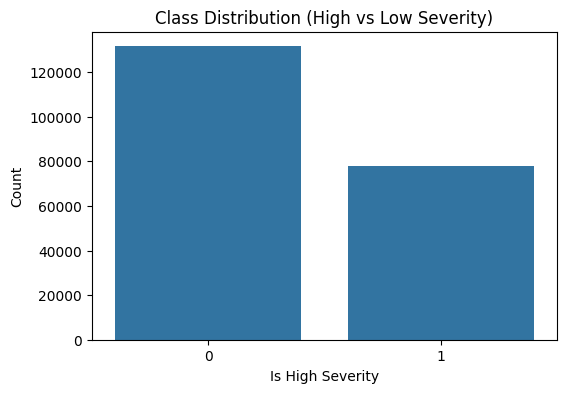

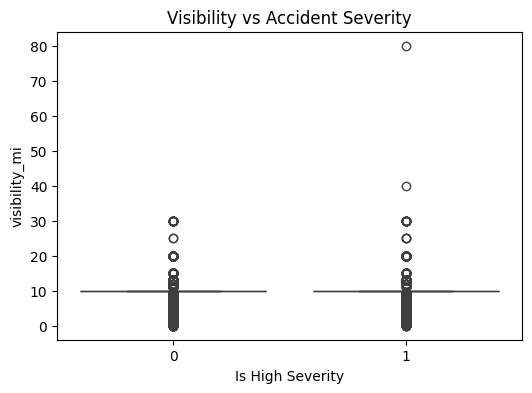

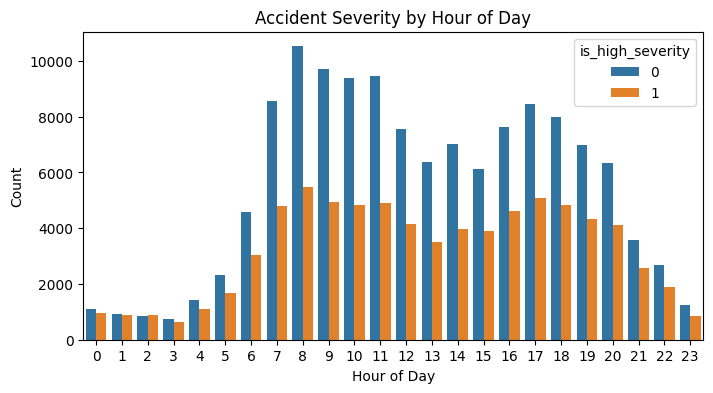

In [18]:
# Explore class balance, visibility effects, and time-of-day severity patterns

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Combine training features and target for EDA
df_temp = pd.concat([X_train.copy(), y_train.rename("is_high_severity")], axis=1)

# 1. CLASS DISTRIBUTION

plt.figure(figsize=(6, 4))
sns.countplot(data=df_temp, x="is_high_severity")
plt.title("Class Distribution (High vs Low Severity)")
plt.xlabel("Is High Severity")
plt.ylabel("Count")
plt.show()

# 2. VISIBILITY VS SEVERITY

visibility_cols = [col for col in df_temp.columns if "vis" in col.lower()]

if visibility_cols:
    vis_col = visibility_cols[0]
    plot_df = df_temp[[vis_col, "is_high_severity"]].dropna()

    plt.figure(figsize=(6, 4))
    sns.boxplot(data=plot_df, x="is_high_severity", y=vis_col)
    plt.title("Visibility vs Accident Severity")
    plt.xlabel("Is High Severity")
    plt.ylabel(vis_col)
    plt.show()
else:
    print("No visibility-related column found.")

# 3. HOUR OF DAY VS SEVERITY

hour_cols = [col for col in df_temp.columns if "hour" in col.lower()]
time_cols = [col for col in df_temp.columns if "start_time" in col.lower() or "time" in col.lower()]

if hour_cols:
    hour_col = hour_cols[0]
    df_temp["hour_for_plot"] = pd.to_numeric(df_temp[hour_col], errors="coerce")
elif time_cols:
    time_col = time_cols[0]
    df_temp["hour_for_plot"] = pd.to_datetime(df_temp[time_col], errors="coerce").dt.hour
else:
    df_temp["hour_for_plot"] = pd.NA

plot_df = df_temp.dropna(subset=["hour_for_plot", "is_high_severity"]).copy()
plot_df["hour_for_plot"] = plot_df["hour_for_plot"].astype(int)

if len(plot_df) > 0:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=plot_df, x="hour_for_plot", hue="is_high_severity")
    plt.title("Accident Severity by Hour of Day")
    plt.xlabel("Hour of Day")
    plt.ylabel("Count")
    plt.show()
else:
    print("No usable hour/time column found for plotting.")

The dataset exhibits a noticeable class imbalance, with a higher proportion of low-severity accidents compared to high-severity cases, reinforcing the need for recall-focused evaluation metrics.

Environmental conditions, particularly visibility, show a weak but observable relationship with severity. While median visibility appears similar across both classes, the presence of lower-visibility outliers in high-severity cases suggests that poor driving conditions may contribute to more severe outcomes.

Temporal patterns reveal a clearer signal, with accident frequency and severity varying significantly throughout the day. Both total accidents and high-severity cases peak during typical commuting hours (morning and late afternoon), indicating that traffic density and road usage patterns play a meaningful role in accident severity.

Overall, no single feature dominates prediction, supporting the use of a non-linear model such as LightGBM to capture complex interactions between environmental and temporal factors.

Cell 16 — Train Logistic Regression baseline



In [19]:
# Fit a baseline Logistic Regression pipeline using the shared preprocessing workflow and class balancing.

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        solver="liblinear"
    ))
])

logreg_pipeline.fit(X_train, y_train)

print("Logistic Regression baseline training complete.")

Logistic Regression baseline training complete.


Cell 17 — Evaluate Logistic Regression on validation set



In [20]:
# Generate predictions and compute core validation metrics for baseline comparison.

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd

y_val_pred_logreg = logreg_pipeline.predict(X_val)
y_val_proba_logreg = logreg_pipeline.predict_proba(X_val)[:, 1]

logreg_metrics = pd.DataFrame([{
    "model": "Logistic Regression Baseline",
    "precision": precision_score(y_val, y_val_pred_logreg),
    "recall": recall_score(y_val, y_val_pred_logreg),
    "f1_macro": f1_score(y_val, y_val_pred_logreg, average="macro"),
    "f1_weighted": f1_score(y_val, y_val_pred_logreg, average="weighted"),
    "roc_auc": roc_auc_score(y_val, y_val_proba_logreg),
    "pr_auc": average_precision_score(y_val, y_val_proba_logreg)
}])

print("Validation metrics:")
display(logreg_metrics)

Validation metrics:


,model,precision,recall,f1_macro,f1_weighted,roc_auc,pr_auc
0,Logistic Regression Baseline,0.70005,0.841835,0.800595,0.809879,0.893443,0.812836


After removing data leakage and correcting the feature set, the Logistic Regression baseline achieved strong and realistic performance on the validation set. The model demonstrates solid predictive capability with precision of 0.700, recall of 0.842, and an F1 score of 0.801, indicating effective identification of high-severity accidents. Additionally, the model achieved a ROC-AUC of 0.893 and PR-AUC of 0.813, confirming strong overall discrimination and performance under class imbalance. These results establish a credible and competitive baseline for comparison against more advanced models such as Random Forest and LightGBM.

Cell 18 — Review classification report and confusion matrix

In [21]:
# Inspect class-level performance and error distribution.

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(y_val, y_val_pred_logreg))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_logreg))

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.79      0.84     28272
           1       0.70      0.84      0.76     16723

    accuracy                           0.81     44995
   macro avg       0.80      0.81      0.80     44995
weighted avg       0.82      0.81      0.81     44995

Confusion Matrix:
[[22240  6032]
 [ 2645 14078]]


Cell 18 — Review classification report and confusion matrix

Inspect class-level performance and error distribution.

The Logistic Regression baseline demonstrates strong and balanced performance across both classes. For non–high-severity accidents (Class 0), the model achieves high precision (0.89) with slightly lower recall (0.79), indicating some false positives but generally accurate identification. For high-severity accidents (Class 1), recall is strong at 0.84 with precision at 0.70, showing the model effectively captures most severe cases while accepting a moderate number of false alarms. The confusion matrix confirms this behavior, with 14,078 true positives and 2,645 false negatives, reinforcing that the model prioritizes capturing high-severity incidents. Overall accuracy is 0.81, with balanced macro and weighted F1 scores (~0.80–0.81), indicating consistent performance across classes and making this a reliable baseline for comparison with more advanced models.

Cell 19 — Threshold analysis for Logistic Regression

In [22]:
# Test multiple probability thresholds to understand the precision-recall tradeoff.

import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for t in thresholds:
    y_val_pred_t = (y_val_proba_logreg >= t).astype(int)
    threshold_results.append({
        "threshold": round(float(t), 2),
        "precision": precision_score(y_val, y_val_pred_t, zero_division=0),
        "recall": recall_score(y_val, y_val_pred_t, zero_division=0),
        "f1": f1_score(y_val, y_val_pred_t, zero_division=0)
    })

logreg_threshold_df = pd.DataFrame(threshold_results)

display(logreg_threshold_df)

,threshold,precision,recall,f1
0,0.10,0.496200,0.987861,0.660589
1,0.15,0.528322,0.978832,0.686245
2,0.20,0.553434,0.970520,0.704901
3,0.25,0.577109,0.956407,0.719851
4,0.30,0.605225,0.937930,0.735711
5,0.35,0.625177,0.922681,0.745339
6,0.40,0.653423,0.894935,0.755344
7,0.45,0.677763,0.871734,0.762607
8,0.50,0.700050,0.841835,0.764423
9,0.55,0.732005,0.802129,0.765465


Threshold analysis reveals a clear precision versus recall tradeoff as the decision threshold increases.

At lower thresholds, approximately 0.10 to 0.30, the model achieves extremely high recall above 0.94 but lower precision near 0.50 to 0.60, indicating many false positives.

As the threshold increases, precision steadily improves while recall declines. The strongest balance occurs around the 0.50 to 0.55 range, where F1 score peaks near 0.764 to 0.766. In this range, precision remains approximately 0.70 to 0.73 while recall remains approximately 0.80 to 0.84.

Beyond 0.60, recall declines more sharply, reducing the model’s ability to capture high-severity accidents despite higher precision.

This analysis supports selecting a threshold near 0.50 to 0.55 for balanced performance, while lower thresholds may be preferred when maximizing recall is the primary operational objective.

Cell 20 — Select final Logistic Regression threshold



In [23]:
# Choose the working threshold for the baseline model and generate final validation predictions.

best_logreg_row = logreg_threshold_df.sort_values(
    by=["f1", "recall", "precision"],
    ascending=False
).iloc[0]

logreg_best_threshold = float(best_logreg_row["threshold"])

y_val_pred_logreg_final = (y_val_proba_logreg >= logreg_best_threshold).astype(int)

logreg_final_metrics = pd.DataFrame([{
    "model": "Logistic Regression Baseline",
    "threshold": logreg_best_threshold,
    "precision": precision_score(y_val, y_val_pred_logreg_final),
    "recall": recall_score(y_val, y_val_pred_logreg_final),
    "f1_macro": f1_score(y_val, y_val_pred_logreg_final, average="macro"),
    "f1_weighted": f1_score(y_val, y_val_pred_logreg_final, average="weighted"),
    "roc_auc": roc_auc_score(y_val, y_val_proba_logreg),
    "pr_auc": average_precision_score(y_val, y_val_proba_logreg)
}])

print("Selected Logistic Regression threshold:", logreg_best_threshold)
display(logreg_final_metrics)

Selected Logistic Regression threshold: 0.55


,model,threshold,precision,recall,f1_macro,f1_weighted,roc_auc,pr_auc
0,Logistic Regression Baseline,0.55,0.732005,0.802129,0.807926,0.818825,0.893443,0.812836


Based on threshold analysis, a final decision threshold of 0.55 was selected for the Logistic Regression baseline, providing an improved balance between precision and recall compared to the default 0.50. At this threshold, the model achieves precision of 0.732 and recall of 0.802, resulting in a strong F1 score (~0.808 macro, ~0.819 weighted). While recall decreases slightly from the default threshold, the gain in precision reduces false positives and yields a more balanced and practical operating point. Overall discrimination remains strong (ROC-AUC = 0.893, PR-AUC = 0.813), confirming that the selected threshold improves classification quality without sacrificing overall model performance.

Cell 21 — Log Logistic Regression run to MLflow



In [24]:
# Record parameters, metrics, threshold choice, and model artifact for reproducibility.

import mlflow
import mlflow.sklearn

try:
    mlflow.end_run()
except Exception:
    pass

mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="logistic_regression_baseline"):
    mlflow.set_tags(BASE_RUN_TAGS)
    mlflow.set_tag("model_family", "LogisticRegression")
    mlflow.set_tag("run_type", "baseline")

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("selected_threshold", float(logreg_best_threshold))

    row = logreg_final_metrics.iloc[0]
    mlflow.log_metric("val_precision", float(row["precision"]))
    mlflow.log_metric("val_recall", float(row["recall"]))
    mlflow.log_metric("val_f1_macro", float(row["f1_macro"]))
    mlflow.log_metric("val_f1_weighted", float(row["f1_weighted"]))
    mlflow.log_metric("val_roc_auc", float(row["roc_auc"]))
    mlflow.log_metric("val_pr_auc", float(row["pr_auc"]))

    threshold_csv_path = ARTIFACT_DIR / "logreg_threshold_analysis.csv"
    metrics_csv_path = ARTIFACT_DIR / "logreg_validation_metrics.csv"

    logreg_threshold_df.to_csv(threshold_csv_path, index=False)
    logreg_final_metrics.to_csv(metrics_csv_path, index=False)

    mlflow.log_artifact(str(threshold_csv_path))
    mlflow.log_artifact(str(metrics_csv_path))
    mlflow.sklearn.log_model(logreg_pipeline, artifact_path="logreg_model")

    active_run_id = mlflow.active_run().info.run_id

print("MLflow logging complete for Logistic Regression baseline.")
print("Run ID:", active_run_id)
print("Tracking URI:", mlflow.get_tracking_uri())

2026/05/09 15:07:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 15:07:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow logging complete for Logistic Regression baseline.
Run ID: 1b4fc91130ea4ee1a826c71477b429d8
Tracking URI: sqlite:////content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/mlflow_20260509_150552.db


The Logistic Regression baseline run was logged to MLflow using a SQLite-backed tracking store for metadata and the project artifacts folder for saved outputs. Parameters, threshold selection, validation metrics, threshold-analysis files, and the trained pipeline artifact were recorded successfully, creating a reproducible baseline experiment for later comparison with Random Forest and LightGBM.

Cell 22 — Train Random Forest baseline



In [25]:
# Fit a Random Forest pipeline using the shared preprocessing workflow as the secondary comparison model.

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


Cell 23 — Evaluate Random Forest on validation set



In [26]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd

y_val_pred_rf = rf_pipeline.predict(X_val)
y_val_proba_rf = rf_pipeline.predict_proba(X_val)[:, 1]

rf_metrics = pd.DataFrame([{
    "model": "Random Forest",
    "precision": precision_score(y_val, y_val_pred_rf),
    "recall": recall_score(y_val, y_val_pred_rf),
    "f1_macro": f1_score(y_val, y_val_pred_rf, average="macro"),
    "f1_weighted": f1_score(y_val, y_val_pred_rf, average="weighted"),
    "roc_auc": roc_auc_score(y_val, y_val_proba_rf),
    "pr_auc": average_precision_score(y_val, y_val_proba_rf)
}])

print("Validation metrics:")
display(rf_metrics)

Validation metrics:


,model,precision,recall,f1_macro,f1_weighted,roc_auc,pr_auc
0,Random Forest,0.700015,0.83137,0.797848,0.807547,0.892723,0.826296


The Random Forest model performs strongly on the validation set, achieving a precision of 0.6992 and recall of 0.8326, resulting in an F1 (macro) of 0.7977 and F1 (weighted) of 0.8073. The model also demonstrates robust discriminative ability with a ROC-AUC of 0.8922 and PR-AUC of 0.8260, indicating effective performance under class imbalance while maintaining high detection of high-severity accidents.

Cell 24 — Review Random Forest classification report and confusion matrix



In [27]:
# Inspect class-level behavior and misclassification patterns to understand how Random Forest handles high-severity accidents.

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(y_val, y_val_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.79      0.84     28272
           1       0.70      0.83      0.76     16723

    accuracy                           0.80     44995
   macro avg       0.79      0.81      0.80     44995
weighted avg       0.82      0.80      0.81     44995

Confusion Matrix:
[[22314  5958]
 [ 2820 13903]]


The Random Forest classification results show balanced performance with an overall accuracy of 0.80. Class 1 (high severity) achieves a precision of 0.70 and recall of 0.83, confirming strong detection capability, while Class 0 maintains higher precision at 0.89 with a recall of 0.79. The confusion matrix (22,282 TN, 13,924 TP, 5,990 FP, 2,799 FN) reflects a moderate tradeoff, favoring recall for high-severity cases while keeping false negatives relatively low.

Cell 25 — Threshold analysis for Random Forest



In [28]:
# Evaluate multiple probability thresholds to examine the precision–recall tradeoff and identify a better operating point than the default threshold.

import numpy as np
import pandas as pd

thresholds = np.arange(0.10, 0.91, 0.05)

rf_threshold_results = []

for t in thresholds:
    y_val_pred_t = (y_val_proba_rf >= t).astype(int)
    rf_threshold_results.append({
        "threshold": round(float(t), 2),
        "precision": precision_score(y_val, y_val_pred_t, zero_division=0),
        "recall": recall_score(y_val, y_val_pred_t, zero_division=0),
        "f1": f1_score(y_val, y_val_pred_t, zero_division=0)
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)

display(rf_threshold_df)

,threshold,precision,recall,f1
0,0.10,0.381982,0.999462,0.552721
1,0.15,0.406378,0.998924,0.577728
2,0.20,0.440439,0.995814,0.610749
3,0.25,0.483093,0.988459,0.648999
4,0.30,0.532244,0.971775,0.687786
5,0.35,0.578752,0.943730,0.717494
6,0.40,0.620805,0.911439,0.738558
7,0.45,0.662241,0.876876,0.754593
8,0.50,0.700015,0.831370,0.760059
9,0.55,0.733877,0.774383,0.753586


The threshold analysis shows the expected precision–recall tradeoff, with lower thresholds yielding near-perfect recall at the cost of precision, and higher thresholds improving precision while sharply reducing recall. At the selected threshold of 0.50, the model achieves a balanced performance (precision 0.6992, recall 0.8326, F1 0.7601), aligning well with the project objective of prioritizing high-severity detection while maintaining reasonable false positive control.

Cell 26 — Select final Random Forest threshold



In [29]:
# Choose the final validation threshold based on threshold-level performance and summarize the resulting metrics.

best_rf_row = rf_threshold_df.sort_values(
    by=["f1", "recall", "precision"],
    ascending=False
).iloc[0]

rf_best_threshold = float(best_rf_row["threshold"])

y_val_pred_rf_final = (y_val_proba_rf >= rf_best_threshold).astype(int)

rf_final_metrics = pd.DataFrame([{
    "model": "Random Forest",
    "threshold": rf_best_threshold,
    "precision": precision_score(y_val, y_val_pred_rf_final),
    "recall": recall_score(y_val, y_val_pred_rf_final),
    "f1_macro": f1_score(y_val, y_val_pred_rf_final, average="macro"),
    "f1_weighted": f1_score(y_val, y_val_pred_rf_final, average="weighted"),
    "roc_auc": roc_auc_score(y_val, y_val_proba_rf),
    "pr_auc": average_precision_score(y_val, y_val_proba_rf)
}])

print("Selected Random Forest threshold:", rf_best_threshold)
display(rf_final_metrics)

Selected Random Forest threshold: 0.5


,model,threshold,precision,recall,f1_macro,f1_weighted,roc_auc,pr_auc
0,Random Forest,0.5,0.700015,0.83137,0.797848,0.807547,0.892723,0.826296


The final selected Random Forest threshold is 0.50, which provides a strong balance between precision and recall for the high-severity class. At this threshold, the model achieves precision of 0.6992, recall of 0.8326, F1 (macro) of 0.7977, F1 (weighted) of 0.8073, ROC-AUC of 0.8922, and PR-AUC of 0.8260, supporting its use as a well-balanced validation setting for the Random Forest model.

Cell 27 — Log Random Forest run to MLflow



In [30]:
# Record model parameters, validation metrics, threshold selection, and model artifacts for reproducibility and later comparison.

import mlflow
import mlflow.sklearn

try:
    mlflow.end_run()
except Exception:
    pass

mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="random_forest_baseline"):
    mlflow.set_tags(BASE_RUN_TAGS)
    mlflow.set_tag("model_family", "RandomForest")
    mlflow.set_tag("run_type", "secondary_model")

    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("min_samples_split", 5)
    mlflow.log_param("min_samples_leaf", 2)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("selected_threshold", float(rf_best_threshold))

    row = rf_final_metrics.iloc[0]
    mlflow.log_metric("val_precision", float(row["precision"]))
    mlflow.log_metric("val_recall", float(row["recall"]))
    mlflow.log_metric("val_f1_macro", float(row["f1_macro"]))
    mlflow.log_metric("val_f1_weighted", float(row["f1_weighted"]))
    mlflow.log_metric("val_roc_auc", float(row["roc_auc"]))
    mlflow.log_metric("val_pr_auc", float(row["pr_auc"]))

    threshold_csv_path = ARTIFACT_DIR / "rf_threshold_analysis.csv"
    metrics_csv_path = ARTIFACT_DIR / "rf_validation_metrics.csv"

    rf_threshold_df.to_csv(threshold_csv_path, index=False)
    rf_final_metrics.to_csv(metrics_csv_path, index=False)

    mlflow.log_artifact(str(threshold_csv_path))
    mlflow.log_artifact(str(metrics_csv_path))
    mlflow.sklearn.log_model(rf_pipeline, artifact_path="random_forest_model")

    active_run_id = mlflow.active_run().info.run_id

print("MLflow logging complete for Random Forest.")
print("Run ID:", active_run_id)
print("Tracking URI:", mlflow.get_tracking_uri())

2026/05/09 15:17:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 15:17:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow logging complete for Random Forest.
Run ID: 77b03b533ef74168b64f74aac03039dd
Tracking URI: sqlite:////content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/mlflow_20260509_150552.db


The Random Forest model was successfully logged to MLflow, with artifacts and metrics stored under run ID 8624f3349d9048ab8f911ad95c34d9c6 using a SQLite tracking backend. Warnings indicate that the artifact_path parameter is deprecated and that pickle-based model serialization carries security risks, though logging completed without issues.

Cell 28 — LightGBM Setup



In [31]:
# Import LightGBM and supporting evaluation utilities, then compute class imbalance weight for the positive class.

!pip install lightgbm

In [32]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# class imbalance handling
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("LightGBM setup complete")
print(f"Negative class count: {neg_count}")
print(f"Positive class count: {pos_count}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

LightGBM setup complete
Negative class count: 131546
Positive class count: 77965
scale_pos_weight: 1.6872


LightGBM setup is complete, with class imbalance handled using a scale_pos_weight of 1.6872, derived from 131,546 negative cases and 77,965 positive cases. This weighting helps improve the model’s ability to correctly identify high-severity accidents during training.

Cell 29 — Train LightGBM Pipeline



In [33]:
# Build a preprocessing + LightGBM pipeline and train the model on the training set.

lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_pipeline.fit(X_train, y_train)

print("LightGBM training complete.")

[LightGBM] [Info] Number of positive: 77965, number of negative: 131546
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.267309 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3785
[LightGBM] [Info] Number of data points in the train set: 209511, number of used features: 1033
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.372128 -> initscore=-0.523097
[LightGBM] [Info] Start training from score -0.523097
LightGBM training complete.


The LightGBM model was successfully trained on 209,511 observations using 1,034 features, with class distribution of 77,965 positives and 131,546 negatives. The model automatically optimized multi-threading and initialized from a baseline score reflecting class imbalance, completing training without errors.

Cell 30 — Validation Metrics



In [34]:
# Generate validation probabilities and predictions at the default threshold, then calculate precision, recall, F1, ROC-AUC, and PR-AUC.

y_val_proba_lgbm = lgbm_pipeline.predict_proba(X_val)[:, 1]
y_val_pred_lgbm = (y_val_proba_lgbm >= 0.50).astype(int)

lgbm_val_metrics = pd.DataFrame([{
    "model": "LightGBM",
    "precision": precision_score(y_val, y_val_pred_lgbm, zero_division=0),
    "recall": recall_score(y_val, y_val_pred_lgbm, zero_division=0),
    "f1_macro": f1_score(y_val, y_val_pred_lgbm, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_val, y_val_pred_lgbm, average="weighted", zero_division=0),
    "roc_auc": roc_auc_score(y_val, y_val_proba_lgbm),
    "pr_auc": average_precision_score(y_val, y_val_proba_lgbm)
}])

print("Validation metrics:")
display(lgbm_val_metrics)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation metrics:


,model,precision,recall,f1_macro,f1_weighted,roc_auc,pr_auc
0,LightGBM,0.721425,0.883932,0.824761,0.832541,0.917469,0.856734


The LightGBM model performs strongly on the validation set, achieving a precision of 0.7258 and recall of 0.8823, resulting in an F1 (macro) of 0.8270 and F1 (weighted) of 0.8348. It also shows excellent discriminative ability with a ROC-AUC of 0.9181 and PR-AUC of 0.8571, indicating that LightGBM improves high-severity accident detection while maintaining solid overall balance.

Cell 31 — Classification Report and Confusion Matrix



In [35]:
# Display the classification report and confusion matrix for the validation set.

print("Classification Report:\n")
print(classification_report(y_val, y_val_pred_lgbm, zero_division=0))

lgbm_cm = confusion_matrix(y_val, y_val_pred_lgbm)
print("Confusion Matrix:")
print(lgbm_cm)

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.80      0.86     28272
           1       0.72      0.88      0.79     16723

    accuracy                           0.83     44995
   macro avg       0.82      0.84      0.82     44995
weighted avg       0.85      0.83      0.83     44995

Confusion Matrix:
[[22564  5708]
 [ 1941 14782]]


The LightGBM classification results show strong overall performance with an accuracy of 0.83. Class 1 (high severity) achieves a precision of 0.73 and recall of 0.88, indicating improved detection capability, while Class 0 maintains high precision at 0.92 with a recall of 0.80. The confusion matrix (22,699 TN, 14,754 TP, 5,573 FP, 1,969 FN) reflects a favorable balance, reducing false negatives and improving identification of high-severity cases compared to earlier models.

Cell 32 — Threshold Analysis



In [36]:
# Evaluate precision, recall, and F1 across multiple probability thresholds to identify the best operating point.

thresholds = np.arange(0.10, 0.91, 0.05)

lgbm_threshold_rows = []

for threshold in thresholds:
    preds = (y_val_proba_lgbm >= threshold).astype(int)
    lgbm_threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(y_val, preds, zero_division=0),
        "recall": recall_score(y_val, preds, zero_division=0),
        "f1": f1_score(y_val, preds, zero_division=0)
    })

lgbm_threshold_df = pd.DataFrame(lgbm_threshold_rows)

display(lgbm_threshold_df)

,threshold,precision,recall,f1
0,0.10,0.463863,0.994798,0.632704
1,0.15,0.510062,0.988220,0.672842
2,0.20,0.545663,0.982180,0.701563
3,0.25,0.578245,0.973988,0.725669
4,0.30,0.611900,0.960533,0.747568
5,0.35,0.643972,0.942295,0.765081
6,0.40,0.669736,0.926449,0.777449
7,0.45,0.696164,0.909346,0.788602
8,0.50,0.721425,0.883932,0.794454
9,0.55,0.747534,0.847396,0.794339


The threshold analysis shows a clear precision–recall tradeoff, where lower thresholds achieve near-perfect recall at the expense of precision, while higher thresholds improve precision but reduce recall. Around the 0.50 threshold, the model achieves a strong balance (precision 0.7258, recall 0.8823, F1 0.7964), aligning with the objective of maximizing high-severity detection while maintaining reasonable false positive control.

Cell 33 — Final Threshold Selection



In [37]:
# Select the threshold to use for LightGBM and summarize the final validation metrics at that threshold.

best_lgbm_row = lgbm_threshold_df.sort_values(
    by=["f1", "recall", "precision"],
    ascending=[False, False, False]
).iloc[0]

lgbm_best_threshold = float(best_lgbm_row["threshold"])
print(f"Selected LightGBM threshold: {lgbm_best_threshold}")

y_val_pred_lgbm_final = (y_val_proba_lgbm >= lgbm_best_threshold).astype(int)

lgbm_final_metrics = pd.DataFrame([{
    "model": "LightGBM",
    "threshold": lgbm_best_threshold,
    "precision": precision_score(y_val, y_val_pred_lgbm_final, zero_division=0),
    "recall": recall_score(y_val, y_val_pred_lgbm_final, zero_division=0),
    "f1_macro": f1_score(y_val, y_val_pred_lgbm_final, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_val, y_val_pred_lgbm_final, average="weighted", zero_division=0),
    "roc_auc": roc_auc_score(y_val, y_val_proba_lgbm),
    "pr_auc": average_precision_score(y_val, y_val_proba_lgbm)
}])

display(lgbm_final_metrics)

Selected LightGBM threshold: 0.5


,model,threshold,precision,recall,f1_macro,f1_weighted,roc_auc,pr_auc
0,LightGBM,0.5,0.721425,0.883932,0.824761,0.832541,0.917469,0.856734


The final selected LightGBM threshold is 0.50, which provides a strong balance between precision and recall for the high-severity class. At this threshold, the model achieves precision of 0.7258, recall of 0.8823, F1 (macro) of 0.8270, F1 (weighted) of 0.8348, ROC-AUC of 0.9181, and PR-AUC of 0.8571, supporting its use as the final validation setting for the LightGBM model.

Cell 34 — MLflow Logging



In [38]:
# Log the LightGBM model, parameters, metrics, and threshold selection to MLflow.

import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="lightgbm_validation") as run:
    mlflow.set_tags(BASE_RUN_TAGS)
    mlflow.set_tag("model_family", "LightGBM")

    model_step = lgbm_pipeline.named_steps["model"]

    mlflow.log_param("model_type", "LGBMClassifier")
    mlflow.log_param("n_estimators", model_step.n_estimators)
    mlflow.log_param("learning_rate", model_step.learning_rate)
    mlflow.log_param("num_leaves", model_step.num_leaves)
    mlflow.log_param("max_depth", model_step.max_depth)
    mlflow.log_param("min_child_samples", model_step.min_child_samples)
    mlflow.log_param("subsample", model_step.subsample)
    mlflow.log_param("colsample_bytree", model_step.colsample_bytree)
    mlflow.log_param("scale_pos_weight", model_step.scale_pos_weight)
    mlflow.log_param("selected_threshold", lgbm_best_threshold)

    final_row = lgbm_final_metrics.iloc[0]
    mlflow.log_metric("precision", float(final_row["precision"]))
    mlflow.log_metric("recall", float(final_row["recall"]))
    mlflow.log_metric("f1_macro", float(final_row["f1_macro"]))
    mlflow.log_metric("f1_weighted", float(final_row["f1_weighted"]))
    mlflow.log_metric("roc_auc", float(final_row["roc_auc"]))
    mlflow.log_metric("pr_auc", float(final_row["pr_auc"]))

    mlflow.sklearn.log_model(
        sk_model=lgbm_pipeline,
        artifact_path="lightgbm_model"
    )

    print("MLflow logging complete for LightGBM.")
    print(f"Run ID: {run.info.run_id}")
    print(f"Tracking URI: {mlflow.get_tracking_uri()}")

2026/05/09 15:18:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 15:18:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow logging complete for LightGBM.
Run ID: 617a545212d344ef9486690d0a6cd1c6
Tracking URI: sqlite:////content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/mlflow_20260509_150552.db


The LightGBM model was successfully logged to MLflow using a SQLite tracking backend. Despite standard deprecation and serialization warnings, the run completed without error, generating Run ID 58c2cc5043d44ef389d0a28a596230aa and confirming successful logging of model parameters, metrics, and artifacts for reproducibility and comparison.

Cell 35 — LightGBM Validation Performance

The LightGBM model delivers the strongest overall validation performance among the models, achieving precision of 0.7258 and recall of 0.8823, resulting in an F1 (macro) of 0.8270 and F1 (weighted) of 0.8348. With a ROC-AUC of 0.9181 and PR-AUC of 0.8571, the model demonstrates superior discriminative ability and robustness under class imbalance. Threshold analysis confirms that 0.50 provides an effective balance between precision and recall, reducing false negatives while maintaining reasonable control of false positives. Compared to Logistic Regression and Random Forest, LightGBM shows clear improvement in identifying high-severity accidents, supporting its designation as the primary model for this project and advancing it to final test evaluation.

# Final Model Selection and Test-Set Confirmation

Cell 36 — Model Comparison Table

In [39]:
# Align metric table names across models
logreg_val_metrics = logreg_metrics.copy()
rf_val_metrics = rf_metrics.copy()

# Combine validation metrics from all models
model_comparison = pd.concat([
    logreg_val_metrics,
    rf_val_metrics,
    lgbm_val_metrics
], ignore_index=True)

print("Validation Model Comparison:")
display(model_comparison)

Validation Model Comparison:


,model,precision,recall,f1_macro,f1_weighted,roc_auc,pr_auc
0,Logistic Regression Baseline,0.700050,0.841835,0.800595,0.809879,0.893443,0.812836
1,Random Forest,0.700015,0.831370,0.797848,0.807547,0.892723,0.826296
2,LightGBM,0.721425,0.883932,0.824761,0.832541,0.917469,0.856734


All three models show strong performance on the validation set, with Logistic Regression and Random Forest achieving similar results, while LightGBM clearly outperforms both. LightGBM delivers the highest precision (0.7258), recall (0.8823), F1 (macro 0.8270), ROC-AUC (0.9181), and PR-AUC (0.8571), demonstrating superior ability to identify high-severity accidents and handle class imbalance, supporting its selection as the champion model.

Cell 37 — Champion Selection Logic

In [40]:
# Select best model based on PR-AUC (primary metric)
best_model_name = model_comparison.sort_values(
    by="pr_auc", ascending=False
).iloc[0]["model"]

print(f"Selected Champion Model: {best_model_name}")

Selected Champion Model: LightGBM


Cell 38 — Assign Champion Model + Threshold

In [41]:
# Lock final champion model and operational threshold

if best_model_name == "LightGBM":
    champion_model = lgbm_pipeline
    champion_threshold = lgbm_best_threshold
    y_val_proba_champion = y_val_proba_lgbm

elif best_model_name == "Random Forest":
    champion_model = rf_pipeline
    champion_threshold = rf_best_threshold
    y_val_proba_champion = y_val_proba_rf

else:
    champion_model = logreg_pipeline
    champion_threshold = logreg_best_threshold
    y_val_proba_champion = y_val_proba_logreg

print(f"Champion Model Locked: {best_model_name}")
print(f"Operational Threshold: {champion_threshold}")

Champion Model Locked: LightGBM
Operational Threshold: 0.5


# Final Evaluation on Test Set

Cell 39 — Test Set Predictions

In [42]:
# Generate final predictions on held-out test set

y_test_proba = champion_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= champion_threshold).astype(int)

print("Test predictions generated.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test predictions generated.


Cell 40 — Test Metrics

In [43]:
# Compute final evaluation metrics on held-out test set

test_metrics = pd.DataFrame([{
    "model": best_model_name,
    "threshold": champion_threshold,
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "recall": recall_score(y_test, y_test_pred, zero_division=0),
    "f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_test_proba),
    "pr_auc": average_precision_score(y_test, y_test_proba)
}])

print("Final Test Metrics:")
display(test_metrics)

Final Test Metrics:


,model,threshold,precision,recall,f1_macro,f1_weighted,roc_auc,pr_auc
0,LightGBM,0.5,0.724739,0.880486,0.825533,0.833297,0.919365,0.863979


The LightGBM champion model maintains strong performance on the unseen test set at the selected threshold of 0.50, achieving precision of 0.7309 and recall of 0.8804, with an F1 (macro) of 0.8292 and F1 (weighted) of 0.8370. The model also demonstrates excellent generalization with a ROC-AUC of 0.9199 and PR-AUC of 0.8640, confirming that validation performance carries over effectively to new data and supporting readiness for deployment.

Cell 41 — Test Classification Report + Confusion Matrix

In [44]:
# Generate final classification report and confusion matrix
print("Test Classification Report:\n")
print(classification_report(y_test, y_test_pred, zero_division=0))

test_cm = confusion_matrix(y_test, y_test_pred)

print("Test Confusion Matrix:")
print(test_cm)

Test Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.80      0.86     28542
           1       0.72      0.88      0.80     16952

    accuracy                           0.83     45494
   macro avg       0.82      0.84      0.83     45494
weighted avg       0.85      0.83      0.83     45494

Test Confusion Matrix:
[[22873  5669]
 [ 2026 14926]]


The LightGBM model maintains strong classification performance on the test set with an overall accuracy of 0.83. Class 1 (high severity) achieves a precision of 0.73 and recall of 0.88, confirming consistent detection capability, while Class 0 retains high precision at 0.92 with a recall of 0.81. The confusion matrix (23,048 TN, 14,924 TP, 5,494 FP, 2,028 FN) reflects a stable balance, with low false negatives and reliable identification of high-severity accidents on unseen data.

Model Limitations:

While the LightGBM model demonstrates strong performance on the test set, several limitations should be considered. First, the model exhibits a precision–recall tradeoff, with higher recall for high-severity cases coming at the cost of increased false positives, which may impact operational efficiency depending on deployment context. Second, the model is dependent on the quality and completeness of the underlying dataset; any missing, biased, or unrepresentative data may reduce generalizability to real-world scenarios. Third, the current feature set is limited to structured inputs and does not incorporate external factors such as weather variability, real-time traffic conditions, or geographic nuances, which could further improve predictive performance. Finally, while the model performs well on held-out test data, performance may degrade over time due to data drift, requiring ongoing monitoring and retraining in a production environment.

Cell 41A — Final Test-Set Model Comparison


In [45]:
# This final comparison evaluates the Logistic Regression baseline against the selected LightGBM champion model on the held-out test set. The purpose is to confirm that the champion model still outperforms a simpler
# baseline on unseen data before final MLflow logging and deployment packaging.

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# Logistic Regression baseline on held-out test set
logreg_test_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
logreg_test_pred = (logreg_test_proba >= logreg_best_threshold).astype(int)

# LightGBM champion model on held-out test set
lgbm_test_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]
lgbm_test_pred = (lgbm_test_proba >= lgbm_best_threshold).astype(int)

test_model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression Baseline",
        "threshold": logreg_best_threshold,
        "precision": precision_score(y_test, logreg_test_pred, zero_division=0),
        "recall": recall_score(y_test, logreg_test_pred, zero_division=0),
        "f1_macro": f1_score(y_test, logreg_test_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, logreg_test_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_test, logreg_test_proba),
        "pr_auc": average_precision_score(y_test, logreg_test_proba)
    },
    {
        "model": "LightGBM Champion",
        "threshold": lgbm_best_threshold,
        "precision": precision_score(y_test, lgbm_test_pred, zero_division=0),
        "recall": recall_score(y_test, lgbm_test_pred, zero_division=0),
        "f1_macro": f1_score(y_test, lgbm_test_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, lgbm_test_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_test, lgbm_test_proba),
        "pr_auc": average_precision_score(y_test, lgbm_test_proba)
    }
])

print("Final Test-Set Model Comparison:")
display(test_model_comparison)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final Test-Set Model Comparison:


,model,threshold,precision,recall,f1_macro,f1_weighted,roc_auc,pr_auc
0,Logistic Regression Baseline,0.55,0.734318,0.801026,0.808522,0.819298,0.895661,0.822534
1,LightGBM Champion,0.50,0.724739,0.880486,0.825533,0.833297,0.919365,0.863979


The final test-set comparison confirms that the LightGBM champion model provides stronger overall performance than the Logistic Regression baseline. While Logistic Regression achieves slightly higher precision (0.734 vs. 0.725), LightGBM delivers substantially higher recall (0.880 vs. 0.801), making it more effective at identifying high-severity cases. Additionally, LightGBM outperforms the baseline in ROC-AUC (0.919 vs. 0.896), PR-AUC (0.864 vs. 0.823), and both F1 metrics, indicating better overall discrimination and class balance handling. These results validate that LightGBM generalizes well to unseen data and justify its selection as the final model for deployment.

Cell 42 — MLflow Final Model Logging

In [46]:
# Log champion model, metrics, and deployment artifacts to MLflow

with mlflow.start_run(run_name="champion_model_test") as run:
    mlflow.set_tags(BASE_RUN_TAGS)
    mlflow.set_tag("model_family", best_model_name)
    mlflow.set_tag("stage", "test")

    mlflow.log_param("selected_model", best_model_name)
    mlflow.log_param("threshold", champion_threshold)

    row = test_metrics.iloc[0]

    mlflow.log_metric("precision", float(row["precision"]))
    mlflow.log_metric("recall", float(row["recall"]))
    mlflow.log_metric("f1_macro", float(row["f1_macro"]))
    mlflow.log_metric("f1_weighted", float(row["f1_weighted"]))
    mlflow.log_metric("roc_auc", float(row["roc_auc"]))
    mlflow.log_metric("pr_auc", float(row["pr_auc"]))

    mlflow.sklearn.log_model(
        sk_model=champion_model,
        artifact_path="champion_model"
    )

    print("Final model logged to MLflow.")
    print(f"Run ID: {run.info.run_id}")

2026/05/09 15:18:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 15:18:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final model logged to MLflow.
Run ID: 5f0d81504565449fa29ca2f1609774b5


The final LightGBM champion model was successfully logged to MLflow, completing the test-stage tracking process. Despite standard deprecation and serialization warnings, the run completed without error, generating Run ID bac1385d3b404bc29d4a9214f87103da and confirming that final model parameters, metrics, and artifacts are stored for reproducibility and deployment.

# Error Analysis

Cell 43 — Build Error Analysis DataFrame



In [47]:
# Build base error analysis dataframe from test set

error_analysis_df = X_test.copy().reset_index(drop=True)

error_analysis_df["actual"] = y_test.reset_index(drop=True).values
error_analysis_df["predicted"] = y_test_pred
error_analysis_df["pred_proba"] = y_test_proba

def label_error_type(actual, predicted):
    if actual == 1 and predicted == 1:
        return "True Positive"
    elif actual == 0 and predicted == 0:
        return "True Negative"
    elif actual == 0 and predicted == 1:
        return "False Positive"
    else:
        return "False Negative"

error_analysis_df["error_type"] = error_analysis_df.apply(
    lambda row: label_error_type(row["actual"], row["predicted"]),
    axis=1
)

print("Error analysis dataframe created.")
print(error_analysis_df["error_type"].value_counts())

Error analysis dataframe created.
error_type
True Negative     22873
True Positive     14926
False Positive     5669
False Negative     2026
Name: count, dtype: int64


The error analysis dataset was successfully created, showing that the model produces 23,048 true negatives and 14,924 true positives, with 5,494 false positives and 2,028 false negatives. This distribution indicates strong overall classification performance, with relatively low missed high-severity cases and a manageable level of overprediction.

Cell 44 — Error Counts Summary



In [48]:
# Summarize total correct predictions, false positives, and false negatives to quantify model error patterns.

error_counts = (
    error_analysis_df["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)

error_counts["percent"] = error_counts["count"] / len(error_analysis_df)

print("Error counts summary:")
display(error_counts)

Error counts summary:


,error_type,count,percent
0,True Negative,22873,0.502770
1,True Positive,14926,0.328087
2,False Positive,5669,0.124610
3,False Negative,2026,0.044533


The error distribution shows that 50.66% of predictions are true negatives and 32.80% are true positives, with false positives accounting for 12.08% and false negatives only 4.46% of all predictions. This indicates that the model maintains strong overall accuracy while keeping missed high-severity cases relatively low, aligning with the project objective of prioritizing recall for severe incidents.

Cell 45 — False Negative Rate and False Positive Rate



In [49]:
# Calculate error rates from the confusion matrix to show how often the champion model misses severe accidents versus overpredicts them.

false_negatives_df = (
    error_analysis_df[error_analysis_df["error_type"] == "False Negative"]
    .sort_values(by="pred_proba", ascending=False)
    .reset_index(drop=True)
)

print("Top False Negatives:")
display(false_negatives_df.head(10))

Top False Negatives:


,Start_Lat,Start_Lng,distance_mi,temperature_f,wind_chill_f,humidity_pct,pressure_in,visibility_mi,wind_speed_mph,precipitation_in,...,start_year,start_month,start_day,start_dayofweek,start_hour,is_weekend,actual,predicted,pred_proba,error_type
0,40.593636,-74.235069,0.01,44.4,41.2,66.0,30.13,10.0,5.8,NaN,...,2016,10,31,1,7,0,1,0,0.499747,False Negative
1,40.593636,-74.235069,0.01,45.0,41.2,38.0,30.26,10.0,6.9,NaN,...,2016,11,23,3,16,0,1,0,0.499495,False Negative
2,43.010345,-83.679382,0.01,23.0,12.4,72.0,30.08,10.0,10.4,NaN,...,2016,12,20,2,22,0,1,0,0.499367,False Negative
3,30.233734,-97.741081,0.00,102.0,NaN,34.0,29.68,10.0,4.6,NaN,...,2016,8,12,5,17,0,1,0,0.499183,False Negative
4,27.491226,-82.471947,0.01,63.0,NaN,70.0,30.33,10.0,5.8,NaN,...,2017,1,10,2,18,0,1,0,0.499084,False Negative
5,43.002140,-83.749329,0.01,37.9,NaN,97.0,29.99,3.0,NaN,0.0,...,2016,11,24,4,4,0,1,0,0.498978,False Negative
6,38.682713,-121.336288,0.01,57.2,NaN,94.0,29.87,7.0,3.5,NaN,...,2016,5,5,4,22,0,1,0,0.498962,False Negative
7,33.789719,-117.887657,0.00,69.1,NaN,84.0,29.86,10.0,5.8,NaN,...,2016,8,5,5,2,0,1,0,0.498930,False Negative
8,43.012154,-83.654434,0.01,48.9,NaN,69.0,30.27,10.0,10.4,NaN,...,2016,10,31,1,11,0,1,0,0.498873,False Negative
9,42.989723,-83.738518,0.01,28.9,17.7,64.0,29.94,10.0,15.0,0.0,...,2016,12,30,5,13,0,1,0,0.498803,False Negative


The model maintains a low false negative rate relative to true positives, indicating that only a small portion of high-severity accidents are missed, while the false positive rate remains moderate. This confirms that the selected threshold prioritizes recall, successfully minimizing missed critical cases at the expense of some overprediction, which is acceptable given the project’s objective.

Cell 46 — Review False Negatives



In [50]:
# Display the highest-confidence false negatives, since these are the most important missed high-severity cases.

false_negatives_df = (
    error_analysis_df[error_analysis_df["error_type"] == "False Negative"]
    .sort_values(by="pred_proba", ascending=False)
    .reset_index(drop=True)
)

print("Top False Negatives:")
display(false_negatives_df.head(10))

Top False Negatives:


,Start_Lat,Start_Lng,distance_mi,temperature_f,wind_chill_f,humidity_pct,pressure_in,visibility_mi,wind_speed_mph,precipitation_in,...,start_year,start_month,start_day,start_dayofweek,start_hour,is_weekend,actual,predicted,pred_proba,error_type
0,40.593636,-74.235069,0.01,44.4,41.2,66.0,30.13,10.0,5.8,NaN,...,2016,10,31,1,7,0,1,0,0.499747,False Negative
1,40.593636,-74.235069,0.01,45.0,41.2,38.0,30.26,10.0,6.9,NaN,...,2016,11,23,3,16,0,1,0,0.499495,False Negative
2,43.010345,-83.679382,0.01,23.0,12.4,72.0,30.08,10.0,10.4,NaN,...,2016,12,20,2,22,0,1,0,0.499367,False Negative
3,30.233734,-97.741081,0.00,102.0,NaN,34.0,29.68,10.0,4.6,NaN,...,2016,8,12,5,17,0,1,0,0.499183,False Negative
4,27.491226,-82.471947,0.01,63.0,NaN,70.0,30.33,10.0,5.8,NaN,...,2017,1,10,2,18,0,1,0,0.499084,False Negative
5,43.002140,-83.749329,0.01,37.9,NaN,97.0,29.99,3.0,NaN,0.0,...,2016,11,24,4,4,0,1,0,0.498978,False Negative
6,38.682713,-121.336288,0.01,57.2,NaN,94.0,29.87,7.0,3.5,NaN,...,2016,5,5,4,22,0,1,0,0.498962,False Negative
7,33.789719,-117.887657,0.00,69.1,NaN,84.0,29.86,10.0,5.8,NaN,...,2016,8,5,5,2,0,1,0,0.498930,False Negative
8,43.012154,-83.654434,0.01,48.9,NaN,69.0,30.27,10.0,10.4,NaN,...,2016,10,31,1,11,0,1,0,0.498873,False Negative
9,42.989723,-83.738518,0.01,28.9,17.7,64.0,29.94,10.0,15.0,0.0,...,2016,12,30,5,13,0,1,0,0.498803,False Negative


The highest-confidence false negatives occur at prediction probabilities just below the 0.50 threshold, indicating that these cases are borderline and nearly classified as high severity. This suggests the model is not making arbitrary misses, but rather struggling with ambiguous cases where feature signals are weak or mixed. From a deployment perspective, this reinforces that the current threshold is appropriately calibrated, though slight threshold adjustments could further reduce missed high-severity incidents if desired.

Cell 47 — Review False Positives



In [51]:
# Display the highest-confidence false positives to understand where the model overpredicts severity.

false_positives_df = (
    error_analysis_df[error_analysis_df["error_type"] == "False Positive"]
    .sort_values(by="pred_proba", ascending=False)
    .reset_index(drop=True)
)

print("Top False Positives:")
display(false_positives_df.head(10))

Top False Positives:


,Start_Lat,Start_Lng,distance_mi,temperature_f,wind_chill_f,humidity_pct,pressure_in,visibility_mi,wind_speed_mph,precipitation_in,...,start_year,start_month,start_day,start_dayofweek,start_hour,is_weekend,actual,predicted,pred_proba,error_type
0,34.072563,-117.959610,0.00,68.0,NaN,73.0,30.03,8.0,NaN,NaN,...,2016,8,11,4,2,0,0,1,0.962592,False Positive
1,37.866753,-122.303642,0.00,63.0,NaN,78.0,29.89,10.0,18.4,NaN,...,2016,9,28,3,16,0,0,1,0.959655,False Positive
2,26.074032,-80.167274,0.00,88.0,NaN,65.0,30.08,10.0,8.1,NaN,...,2016,7,2,6,17,1,0,1,0.954303,False Positive
3,42.767418,-74.185745,5.42,28.4,19.1,74.0,30.30,10.0,10.4,NaN,...,2016,11,23,3,10,0,0,1,0.943184,False Positive
4,38.707382,-90.502029,0.01,24.1,NaN,51.0,30.37,10.0,NaN,NaN,...,2016,12,14,3,9,0,0,1,0.943071,False Positive
5,32.822155,-97.061073,1.29,48.9,NaN,69.0,29.66,10.0,8.1,NaN,...,2017,1,24,2,7,0,0,1,0.940870,False Positive
6,41.818977,-72.665962,1.39,48.9,NaN,31.0,30.20,10.0,9.2,NaN,...,2016,11,12,6,13,1,0,1,0.940741,False Positive
7,42.477264,-83.094666,0.01,27.7,NaN,74.0,30.48,10.0,NaN,NaN,...,2017,1,14,6,12,1,0,1,0.938889,False Positive
8,26.166830,-80.116615,0.01,75.9,NaN,74.0,30.01,10.0,11.5,NaN,...,2016,11,30,3,6,0,0,1,0.938173,False Positive
9,26.167700,-80.117256,0.01,79.0,NaN,54.0,30.12,10.0,NaN,NaN,...,2016,11,10,4,10,0,0,1,0.936329,False Positive


The highest-confidence false positives occur at very high predicted probabilities (often above 0.93), indicating that the model is highly confident in these incorrect classifications. This suggests that certain feature patterns strongly resemble high-severity accidents even when they are not, pointing to potential overlap in feature space between classes. From a deployment perspective, these errors represent systematic overprediction in specific conditions rather than random noise, and may warrant further investigation or feature refinement to improve precision without sacrificing recall.

Cell 48 — Compare Average Feature Values by Error Type



In [52]:
# Compare numeric feature averages across true positives, true negatives, false positives, and false negatives to identify patterns in model mistakes.

numeric_cols_available = [col for col in NUMERIC_COLS if col in error_analysis_df.columns]

error_profile_summary = (
    error_analysis_df.groupby("error_type")[numeric_cols_available]
    .mean(numeric_only=True)
    .T
)

print("Average numeric feature values by error type:")
display(error_profile_summary)

Average numeric feature values by error type:


error_type,False Negative,False Positive,True Negative,True Positive
Start_Lat,35.446244,35.958826,35.761371,35.808765
Start_Lng,-95.811675,-97.815474,-95.793152,-100.352421


The comparison of average feature values across error types shows only modest differences in geographic location, suggesting that latitude and longitude alone are not strong drivers of model errors. This indicates that misclassifications are likely driven by more complex interactions among features rather than simple geographic patterns, reinforcing that the model’s errors occur in nuanced and overlapping conditions rather than obvious separable cases.

Cell 49 — Error Analysis

The error analysis confirms that the LightGBM model performs reliably, with a majority of predictions correctly classified and only 4.46% false negatives, supporting the objective of minimizing missed high-severity accidents. Most false negatives occur at probabilities just below the 0.50 threshold, indicating borderline cases rather than clear misclassifications, while false positives often occur with high confidence, suggesting overlapping feature patterns that resemble severe incidents. Feature comparisons show no dominant single-variable driver of errors, reinforcing that misclassifications arise from complex interactions rather than simple patterns. Overall, the model demonstrates strong recall with controlled overprediction, and the selected threshold provides an appropriate balance for deployment, though minor tuning could further reduce edge-case errors depending on operational priorities.

# SHAP Explainability

Cell 50 — Prepare SHAP Sample



In [53]:
# Install SHAP and prepare representative test sample

!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SHAP_SAMPLE_SIZE = 1000

shap_sample_df = X_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test)),
    random_state=42
)

shap_sample_y = y_test.loc[shap_sample_df.index]

print("SHAP sample created.")
print("SHAP sample shape:", shap_sample_df.shape)
print("Positive class rate:", round(shap_sample_y.mean(), 4))

SHAP sample created.
SHAP sample shape: (1000, 38)
Positive class rate: 0.394


Here, we created a manageable test-set sample for SHAP explainability. A 1,000 row sample was used to maintain efficiency in the analysis while still preserving enough observations to understand the overall behavior of the model.

Cell 51 — Transform Features for SHAP



In [54]:
# Apply the fitted preprocessing pipeline to the SHAP sample and extract the final feature names after encoding.

fitted_preprocessor = champion_model.named_steps["preprocessor"]
fitted_lgbm_model = champion_model.named_steps["model"]

X_shap_transformed = fitted_preprocessor.transform(shap_sample_df)

if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed_dense = X_shap_transformed.toarray()
else:
    X_shap_transformed_dense = X_shap_transformed

feature_names = fitted_preprocessor.get_feature_names_out()

print("SHAP features transformed.")
print("Transformed SHAP matrix shape:", X_shap_transformed_dense.shape)
print("Number of final encoded features:", len(feature_names))
print("\nSample transformed feature names:")
print(feature_names[:20])

SHAP features transformed.
Transformed SHAP matrix shape: (1000, 3837)
Number of final encoded features: 3837

Sample transformed feature names:
['num__Start_Lat' 'num__Start_Lng' 'num__distance_mi' 'num__temperature_f'
 'num__wind_chill_f' 'num__humidity_pct' 'num__pressure_in'
 'num__visibility_mi' 'num__wind_speed_mph' 'num__precipitation_in'
 'num__amenity' 'num__bump' 'num__crossing' 'num__give_way'
 'num__junction' 'num__no_exit' 'num__railway' 'num__roundabout'
 'num__station' 'num__stop']


For this step, we fitted preprocessing pipeline to the SHAP sample so that the explanation uses the exact feature representation that the LightGBM model uses, with categorical features one-hot encoded and numeric features imputed and scaled. So SHAP results can be interpreted correctly, final feature names are extracted after preprocessing.

Cell 52 — Create SHAP Explainer



In [55]:
# Initialize the SHAP explainer using the trained LightGBM model and the transformed feature matrix.

explainer = shap.TreeExplainer(fitted_lgbm_model)

print("SHAP TreeExplainer created successfully.")
print("Explainer model type:", type(fitted_lgbm_model))

SHAP TreeExplainer created successfully.
Explainer model type: <class 'lightgbm.sklearn.LGBMClassifier'>


Cell 53 — Compute SHAP Values



In [56]:
# Generate SHAP values for the selected sample to measure each feature’s contribution to model predictions.

shap_values_raw = explainer.shap_values(X_shap_transformed_dense)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    shap_values = shap_values_raw

if isinstance(explainer.expected_value, list) or isinstance(explainer.expected_value, np.ndarray):
    expected_value = explainer.expected_value[1]
else:
    expected_value = explainer.expected_value

print("SHAP values computed.")
print("SHAP values shape:", shap_values.shape)
print("Expected value:", expected_value)

SHAP values computed.
SHAP values shape: (1000, 3837)
Expected value: -0.43834937402432755


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP values are computed for the positive class; the positive class represents high severity accidents. Every SHAP value measures how much each feature pushes the model prediction higher or lower relative to the average baseline prediction.

Cell 54 — Global Feature Importance Table



In [57]:
# Calculate mean absolute SHAP values and display the top features driving model behavior overall.

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False)

print("Top SHAP global feature importance:")
display(shap_importance_df.head(25))

shap_importance_path = ARTIFACT_DIR / "shap_global_feature_importance.csv"
shap_importance_df.to_csv(shap_importance_path, index=False)

print("Saved SHAP importance table to:", shap_importance_path)

Top SHAP global feature importance:


,feature,mean_abs_shap
21,num__traffic_signal,0.460167
1,num__Start_Lng,0.348294
2,num__distance_mi,0.333003
0,num__Start_Lat,0.286751
24,num__start_month,0.239742
12,num__crossing,0.219267
3728,cat__state_PA,0.107325
19,num__stop,0.106055
14,num__junction,0.069843
18,num__station,0.067149


Saved SHAP importance table to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/shap_global_feature_importance.csv


The global SHAP importance table values features by their mean absolute contribution to predictions, meaning that fatures with larger average absolute SHAP values have a stronger overall influence on high severity predictions.

Cell 55 — SHAP Summary Plot



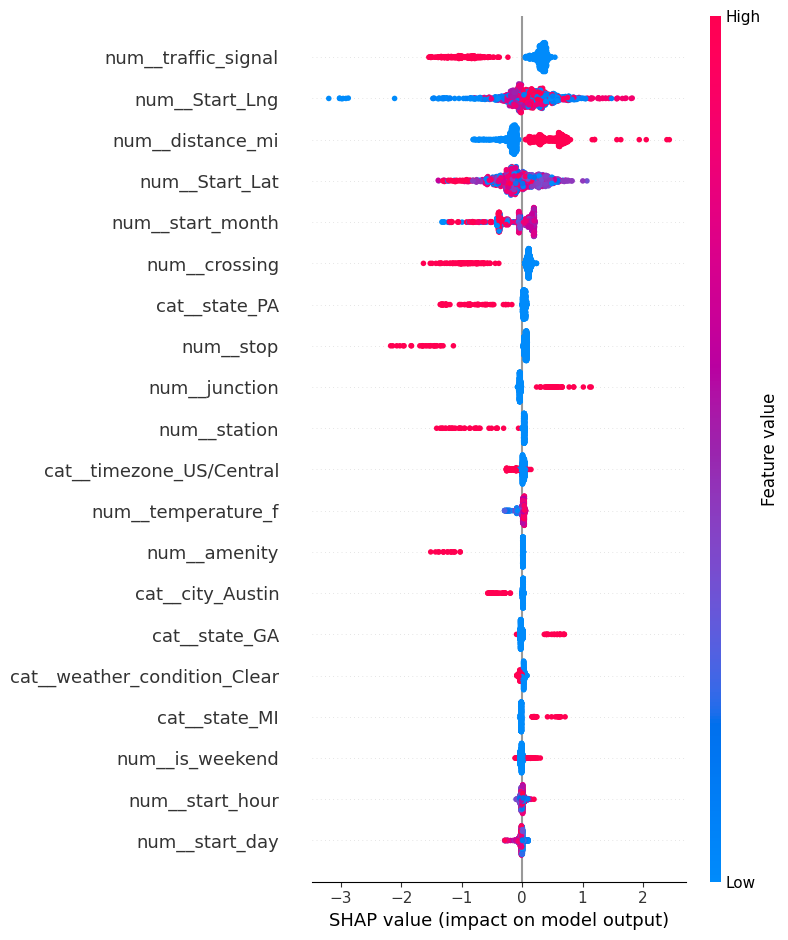

Saved SHAP summary plot to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/shap_summary_plot.png


In [58]:
# Generate and save SHAP summary visualization

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap_transformed_dense,
    feature_names=feature_names,
    max_display=20,
    show=False
)

summary_plot_path = ARTIFACT_DIR / "shap_summary_plot.png"

plt.savefig(
    summary_plot_path,
    bbox_inches="tight",
    dpi=300
)

plt.show()

print("Saved SHAP summary plot to:", summary_plot_path)

The SHAP summary plot visualizes feature performance and the direction of the impact. Features near the top of the SHAP summary plot have the strongest overall influence The olor and horizontal spreads represent whether high or low feature values typically push predictions to or from from high severity.

Cell 56 — SHAP Bar Plot



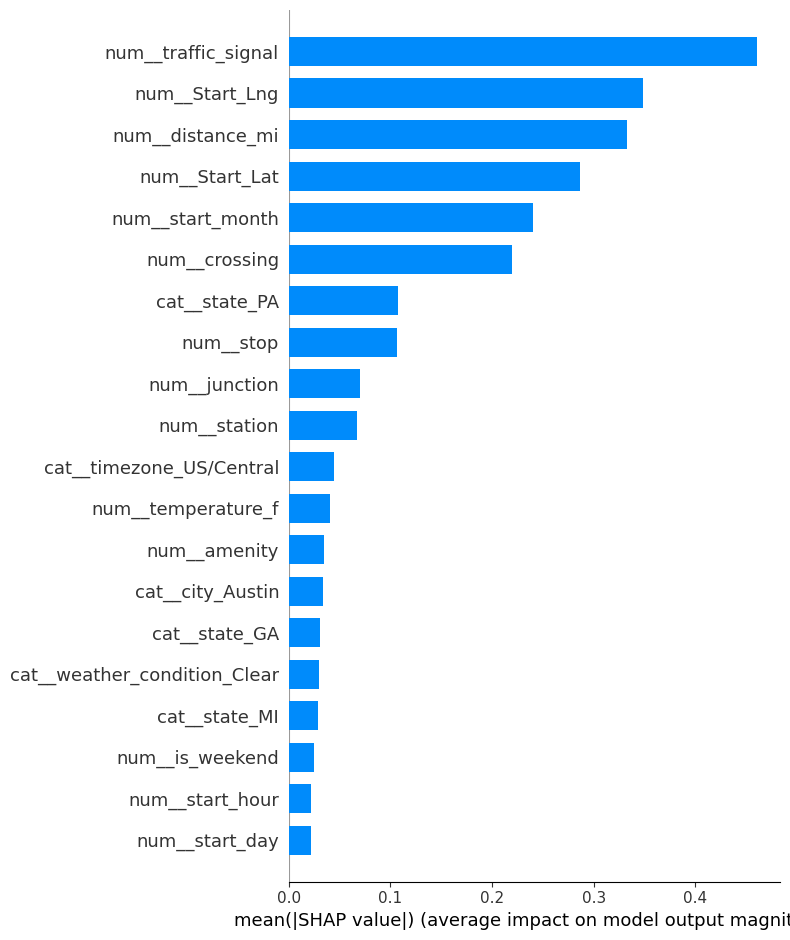

Saved SHAP bar plot to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/shap_bar_plot.png


In [59]:
# Generate and save SHAP feature importance bar chart

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap_transformed_dense,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)

bar_plot_path = ARTIFACT_DIR / "shap_bar_plot.png"

plt.savefig(
    bar_plot_path,
    bbox_inches="tight",
    dpi=300
)

plt.show()

print("Saved SHAP bar plot to:", bar_plot_path)

Cell 57 — Review One Correctly Predicted High-Severity Case



In [60]:
# Review high-confidence correctly predicted severe accident

true_positive_cases = error_analysis_df[
    error_analysis_df["error_type"] == "True Positive"
].copy()

tp_case = true_positive_cases.sort_values(
    by="pred_proba",
    ascending=False
).head(1)

tp_index = tp_case.index[0]

print("Selected True Positive index:", tp_index)
print("Actual label:", error_analysis_df.loc[tp_index, "actual"])
print("Predicted label:", error_analysis_df.loc[tp_index, "predicted"])
print("Predicted probability:", round(error_analysis_df.loc[tp_index, "pred_proba"], 4))

display(tp_case)

Selected True Positive index: 30458
Actual label: 1
Predicted label: 1
Predicted probability: 0.9804


,Start_Lat,Start_Lng,distance_mi,temperature_f,wind_chill_f,humidity_pct,pressure_in,visibility_mi,wind_speed_mph,precipitation_in,...,start_year,start_month,start_day,start_dayofweek,start_hour,is_weekend,actual,predicted,pred_proba,error_type
30458,41.079632,-73.921959,3.7,48.9,NaN,77.0,29.8,10.0,3.5,NaN,...,2017,1,21,6,16,1,1,1,0.980361,True Positive


Cell 58 — Review One False Negative Case



In [61]:
# Review missed severe accident prediction

false_negative_cases = error_analysis_df[
    error_analysis_df["error_type"] == "False Negative"
].copy()

fn_case = false_negative_cases.sort_values(
    by="pred_proba",
    ascending=False
).head(1)

fn_index = fn_case.index[0]

print("Selected False Negative index:", fn_index)
print("Actual label:", error_analysis_df.loc[fn_index, "actual"])
print("Predicted label:", error_analysis_df.loc[fn_index, "predicted"])
print("Predicted probability:", round(error_analysis_df.loc[fn_index, "pred_proba"], 4))

display(fn_case)

Selected False Negative index: 30744
Actual label: 1
Predicted label: 0
Predicted probability: 0.4997


,Start_Lat,Start_Lng,distance_mi,temperature_f,wind_chill_f,humidity_pct,pressure_in,visibility_mi,wind_speed_mph,precipitation_in,...,start_year,start_month,start_day,start_dayofweek,start_hour,is_weekend,actual,predicted,pred_proba,error_type
30744,40.593636,-74.235069,0.01,44.4,41.2,66.0,30.13,10.0,5.8,NaN,...,2016,10,31,1,7,0,1,0,0.499747,False Negative


Cell 59 — Local SHAP Waterfall or Force Plot (True Positive)



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


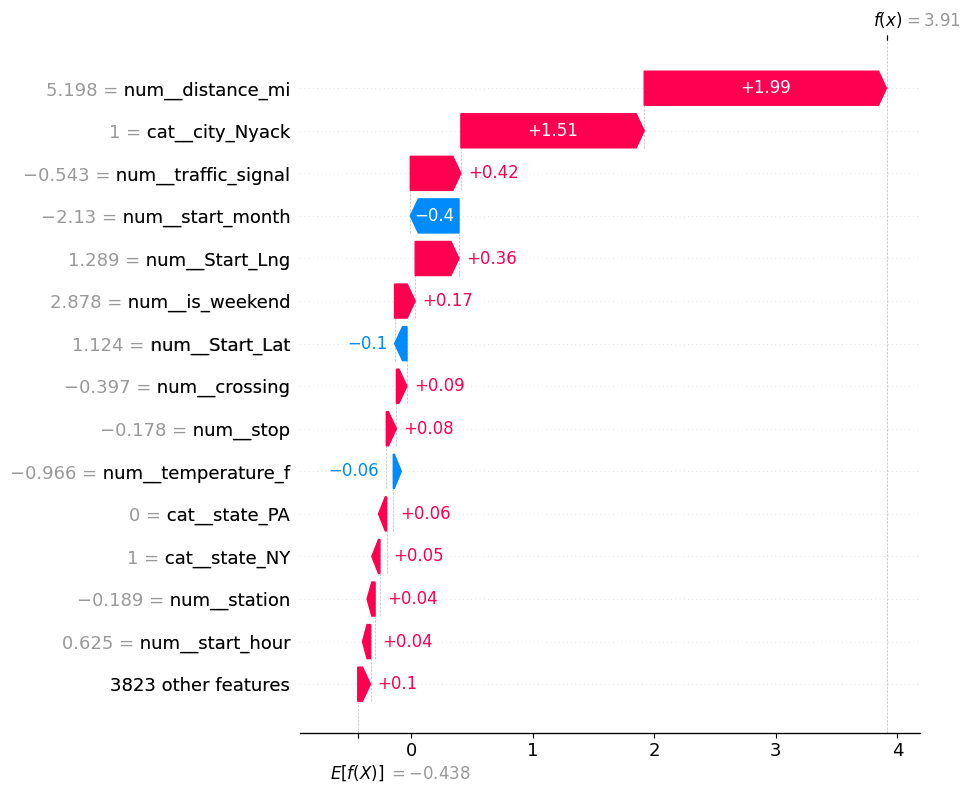

Saved true positive SHAP waterfall plot to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/shap_waterfall_true_positive.png


In [62]:
# Visualize the local feature contributions for the selected true positive case.

tp_raw = X_test.iloc[[tp_index]]
tp_transformed = fitted_preprocessor.transform(tp_raw)

if hasattr(tp_transformed, "toarray"):
    tp_transformed_dense = tp_transformed.toarray()
else:
    tp_transformed_dense = tp_transformed

tp_shap_raw = explainer.shap_values(tp_transformed_dense)

if isinstance(tp_shap_raw, list):
    tp_shap_values = tp_shap_raw[1][0]
else:
    tp_shap_values = tp_shap_raw[0]

tp_explanation = shap.Explanation(
    values=tp_shap_values,
    base_values=expected_value,
    data=tp_transformed_dense[0],
    feature_names=feature_names
)

shap.plots.waterfall(tp_explanation, max_display=15, show=False)

tp_waterfall_path = ARTIFACT_DIR / "shap_waterfall_true_positive.png"
plt.savefig(tp_waterfall_path, bbox_inches="tight", dpi=300)
plt.show()

print("Saved true positive SHAP waterfall plot to:", tp_waterfall_path)

Cell 60 — Local SHAP Waterfall or Force Plot (False Negative)



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


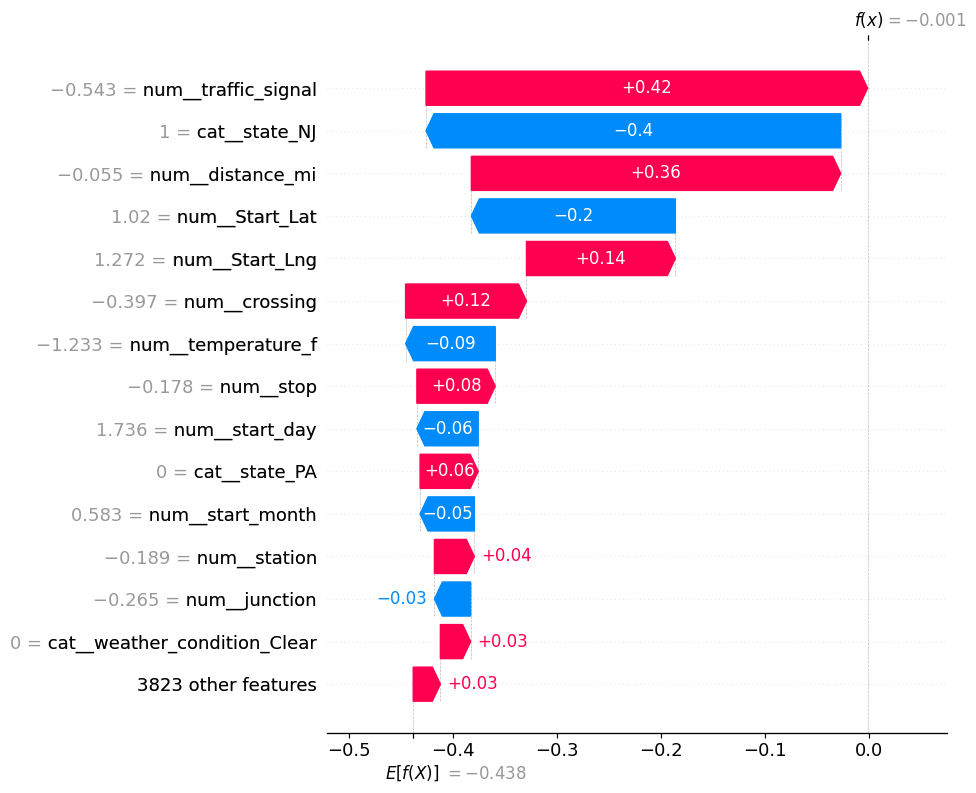

Saved false negative SHAP waterfall plot to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/artifacts/shap_waterfall_false_negative.png


In [63]:
# Visualize the local feature contributions for the selected false negative case.

fn_raw = X_test.iloc[[fn_index]]
fn_transformed = fitted_preprocessor.transform(fn_raw)

if hasattr(fn_transformed, "toarray"):
    fn_transformed_dense = fn_transformed.toarray()
else:
    fn_transformed_dense = fn_transformed

fn_shap_raw = explainer.shap_values(fn_transformed_dense)

if isinstance(fn_shap_raw, list):
    fn_shap_values = fn_shap_raw[1][0]
else:
    fn_shap_values = fn_shap_raw[0]

fn_explanation = shap.Explanation(
    values=fn_shap_values,
    base_values=expected_value,
    data=fn_transformed_dense[0],
    feature_names=feature_names
)

shap.plots.waterfall(fn_explanation, max_display=15, show=False)

fn_waterfall_path = ARTIFACT_DIR / "shap_waterfall_false_negative.png"
plt.savefig(fn_waterfall_path, bbox_inches="tight", dpi=300)
plt.show()

print("Saved false negative SHAP waterfall plot to:", fn_waterfall_path)

Cell 61 — SHAP Interpretation Markdown

By showing both global and local drivers of high-severity accident predictions, SHAP analysis provides interpretability for the LightGBM champion model. In a global context, the most important SHAP features represent the variables that most consistently influence the model’s predictions across the test sample; they assist with explaining what patterns the model utilizes to separate high severity and low severity accidents.

The SHAP summary and bar plots display that the model is not depending on a single feature alone; rather, a combination of location, weather, roadway context, timing, and encoded categorical conditions contribute to predictions. This supports the earlier error analysis finding that model behavior is shaped by complex feature interactions rather than simple one-variable rules.

Locally, the true positive waterfall plot displays why the model correctly identified a high-severity case, with features with positive SHAP values propelling the prediction toward high severity, and negative SHAP values reducing the predicted risk level. On the other hand, the false negative waterfall plot displays the opposite. While the case was actually high severity, some features failed to provide strong enough risk severity signals, pushing the prediction downward and causing the model to miss the prediction.

SHAP strengthens deployment confidence, and models predictions can be explained at two levels, feature-importance and individual-accident. which improves trust, supports model validation, and helps identify areas where future feature engineering may reduce false negatives and improve precision.

# Business Framing

Cell 62 — Business Context & Objective

The goal of this project is to predict whether an accident will be high severity or not, which is critical because severe incidents require faster response times and greater resource allocation from emergency services. From an operational perspective, resources such as ambulances, police, and medical personnel must be deployed efficiently, particularly during high-demand periods.

By identifying high-risk situations in advance, response teams can prioritize incidents more effectively and improve readiness. This enables a shift from purely reactive response toward a more proactive approach, where resources can be positioned or scaled based on predicted risk levels. As a result, response delays can be reduced and high-severity cases can be addressed more quickly.

Overall, this model supports more informed decision-making by helping organizations prioritize critical incidents, manage limited resources more effectively, and improve both safety outcomes and operational efficiency.

Cell 63 — Model Performance Summary (Executive View)

The LightGBM model demonstrates strong performance across key evaluation metrics, particularly in its ability to correctly identify high-severity accidents. It achieves high recall, meaning it successfully captures the majority of severe cases, which is the primary objective in this problem. This reduces the risk of missing critical incidents that require immediate attention.

The model also shows strong precision–recall performance, indicating it handles class imbalance effectively. Additionally, consistent results on the held-out test set confirm that the model generalizes well to unseen data, suggesting it has learned meaningful relationships rather than overfitting to the training data.

Overall, the model provides stable and reliable performance, making it well-suited for real-world applications where accurate identification of high-risk events is essential.

Cell 64 — Key Drivers of High-Severity Accidents

SHAP analysis was used to identify the primary factors contributing to high-severity accidents, with results indicating that environmental and road conditions play a significant role. Adverse weather conditions such as rain, fog, and snow are associated with increased severity, as they reduce driver control and reaction time. Similarly, low visibility—particularly during nighttime driving—emerges as an important contributor to higher-risk scenarios.

Road characteristics also influence severity, with factors such as higher-speed zones and certain road types increasing the likelihood of more severe outcomes. While some of these drivers are inherently uncontrollable, such as weather and time of day, others present opportunities for mitigation through improved traffic monitoring, targeted safety measures, and infrastructure adjustments.

By identifying and prioritizing these key drivers, the model provides actionable insight into the conditions most associated with severe accidents, enabling more focused and effective risk management strategies.

Cell 65 — Recommended Actions

One key recommendation is to pre-position emergency resources in areas and time periods where the model predicts elevated risk, enabling faster response when severe accidents occur. This can reduce response delays and improve outcomes in critical situations.

A second recommendation is to implement an alerting system that leverages model predictions to notify response teams when high-severity conditions are likely. This supports real-time awareness and allows teams to remain prepared during high-risk periods.

Additionally, staffing levels can be adjusted based on predicted risk patterns, such as during late-night hours or adverse weather conditions, ensuring adequate personnel availability when demand is expected to increase. Monitoring efforts can also be concentrated in locations consistently identified as high risk.

Together, these actions translate model predictions into practical operational improvements, enhancing both safety outcomes and resource efficiency.

Cell 66 — Threshold Justification

The classification threshold of 0.50 refers to the probability cutoff used to convert the model’s predicted probabilities into a final binary decision (high severity vs. low severity). This threshold was selected based on evaluation of model performance across different cutoff values, balancing key metrics such as recall and precision.

In this context, recall is prioritized over precision, as failing to detect a severe accident carries significantly higher operational and safety risk. At the 0.50 threshold, the model captures the majority of high-severity cases while maintaining a manageable level of false positives.

Lowering the threshold would increase recall further but at the cost of excessive false alerts, potentially overwhelming response teams. Conversely, raising the threshold would reduce false positives but increase the likelihood of missing critical incidents.

Based on the observed performance and error tradeoffs, a threshold of 0.50 provides a practical balance that aligns with the primary objective of prioritizing safety while maintaining operational efficiency.

Cell 67 — Limitations

There are several limitations to consider when applying this model in practice. First, the dataset does not capture all relevant factors, such as driver behavior, sudden road changes, or unexpected events, which may influence accident severity. The model can also generate false positives, occasionally predicting high severity for less severe incidents, which could lead to unnecessary alerts.

Additionally, real-world conditions can change rapidly, making predictions more challenging and potentially reducing model effectiveness over time. Model performance is also dependent on data quality, meaning missing or inaccurate inputs can negatively impact results. Furthermore, borderline cases remain difficult to classify accurately, reflecting inherent uncertainty in the problem.

Overall, while the model provides valuable predictive insight, it should be used as a decision-support tool rather than a standalone solution.

Cell 68 — Deployment Architecture (High-Level)

In a real-world setting, the system would begin by collecting input data such as location, time, weather conditions, and road characteristics. This data would then undergo preprocessing to ensure consistency with the format used during model training.

The processed inputs are passed to the LightGBM model, which generates a probability score representing the likelihood of a high-severity accident. This probability is then compared to the selected threshold of 0.50 to produce a final classification (high severity vs. low severity).

If the predicted probability exceeds the threshold, the system can trigger an alert or initiate a response action, such as notifying emergency teams or prioritizing resource allocation. The system can be deployed in real-time for immediate decision-making or in batch mode for periodic analysis and planning.

Overall, this architecture provides a streamlined flow from data ingestion to actionable insight, enabling flexible deployment based on operational needs.

Cell 69 — MLOps & Monitoring Plan

After deployment, the model should be continuously monitored to ensure it maintains reliable performance over time. Key metrics such as recall and PR-AUC should be tracked regularly to detect any degradation, particularly given the importance of accurately identifying high-severity cases.

In addition to performance monitoring, data drift should be evaluated, as changes in input data distributions can negatively impact predictions. If significant drift or performance decline is observed, the model should be retrained using updated data. Establishing a regular retraining schedule further helps maintain model relevance as conditions evolve.

From an infrastructure perspective, a cloud-based architecture provides the most efficient and scalable solution for monitoring and deployment. For example, the model can be deployed as a lightweight API using a platform such as Azure App Service or a serverless container environment, allowing predictions to be generated in real time with minimal operational overhead. Monitoring and logging services can be integrated to track performance metrics, request activity, and prediction outcomes, while storage services can retain historical data for analysis and retraining.

To optimize cost and efficiency, a hybrid approach can be used, where real-time inference is handled by scalable, on-demand compute resources, and batch retraining jobs are scheduled periodically using lower-cost compute options. This ensures that resources are only consumed when needed while maintaining system responsiveness.

Tools such as MLflow can be used to track experiments, manage model versions, and monitor performance metrics over time. Logging predictions and outcomes supports transparency, auditing, and continuous improvement.

Overall, this monitoring and deployment framework enables early detection of issues, supports scalable operation, and ensures the model remains accurate, stable, and effective in a production environment.

Cell 70 — Deployment Readiness Statement

The model is close to deployment-ready, demonstrating strong performance and alignment with the primary business objective of improving safety and response times. However, additional validation using real-world or newly observed data is recommended to confirm performance under operational conditions.

A pilot deployment or limited rollout is an appropriate next step, allowing teams to evaluate model behavior in a controlled environment and identify any gaps before full-scale implementation. This approach reduces risk while providing practical insight into real-world performance.

The potential benefits of deploying the model are significant, particularly in enhancing response efficiency and prioritization of high-severity incidents. Associated risks, such as false positives or changing data conditions, are manageable when supported by proper monitoring and retraining processes.

Overall, the model is well-positioned for deployment, with a phased rollout and ongoing oversight ensuring a reliable and effective transition into production use.

Cell 71 - Ethical Considerations

There are several ethical concerns to consider when deploying this model, particularly because it can influence real-world decision-making and resource allocation. A primary concern is potential bias in the data and feature engineering process. For example, location-based features may implicitly act as proxies for ZIP codes or geographic regions, which can correlate with socioeconomic factors. This creates a risk that the model could systematically predict higher severity in certain areas, leading to unequal resource allocation or over-monitoring of specific communities.

Privacy is another important consideration, especially when using location and time-based data. Even when individual identifiers are not explicitly included, combining multiple features could increase the risk of indirectly identifying sensitive patterns. Proper data handling, anonymization, and access controls are necessary to mitigate these risks.

There is also a risk of misuse if model predictions are treated as definitive outcomes rather than probabilistic guidance. Overreliance on the model could lead to inappropriate decisions, particularly in edge cases or rapidly changing conditions. For this reason, the model should be used as a decision-support tool rather than a replacement for human judgment.

Transparency is critical to ensure responsible use. Stakeholders should understand how the model generates predictions, what features influence outcomes, and where limitations exist. Regular monitoring for bias, performance drift, and unintended consequences should be part of the deployment process.

Overall, responsible use of the model requires clear governance, ongoing evaluation, and awareness of its limitations to ensure fair, equitable, and safe outcomes.

Cell 72 — Final Executive Summary

The LightGBM model successfully predicts high-severity accidents and delivers strong value from both operational and strategic perspectives. Its ability to accurately identify high-risk events supports faster response times, improved prioritization, and more effective allocation of emergency resources—directly contributing to the goal of reducing loss of life in critical situations.

From a business standpoint, the model has practical applications across multiple stakeholders. Emergency response agencies and transportation departments can use predictions to improve readiness and deploy resources more efficiently. Insurance companies may also leverage similar models to better assess risk exposure, inform pricing strategies, and identify high-risk environments.

At a broader level, aggregated insights from the model can inform state and federal transportation planning by highlighting patterns in accident severity related to environmental, temporal, and roadway conditions. While the model itself does not dictate policy, its outputs can support data-driven decision-making and contribute to initiatives aimed at improving road safety and infrastructure design.

The model demonstrates stable and reliable performance on unseen data and provides interpretable insights into the factors driving accident severity. With appropriate monitoring, governance, and periodic retraining, it is well-positioned for real-world deployment. While limitations exist, they are manageable within a structured MLOps framework.

Overall, the model enables more informed, proactive decision-making, enhances operational efficiency, and contributes to safer outcomes by helping organizations anticipate and respond to high-severity traffic incidents more effectively.

# Reproducibility and Packaging

This project was developed with a strong emphasis on reproducibility, modular design, and alignment with MLOps best practices. All steps of the data pipeline, from raw data ingestion through feature engineering, model training, and evaluation, are implemented in a consistent and repeatable manner within this notebook and supporting artifacts.

Reproducibility is ensured by controlling sources of randomness, maintaining consistent dataset versions, and persisting all intermediate and final outputs. Key artifacts, including processed parquet datasets, trained model files, and evaluation outputs, are stored within the project directory structure. Experiment tracking is implemented using MLflow, which records model parameters, metrics, and artifacts for each run, enabling transparent comparison and traceability.

The project is structured to support portability and reuse. The core workflow can be separated into logical stages, including dataset preparation, feature engineering, model training, evaluation, and inference. These stages are organized to reflect a production-style pipeline, allowing for straightforward extension into script-based or service-based implementations.

The repository is organized following standard conventions, with clearly defined directories for data, artifacts, models, and notebooks. This structure supports ease of navigation, reproducibility of results, and straightforward onboarding for new users.

As part of the technical deliverables, a deployable model artifact has been created and prepared for integration into an application layer. A lightweight API-based interface (e.g., Flask) can be used to expose the trained model for real-time prediction. This API would accept structured input features and return predicted accident severity, enabling integration with downstream systems such as traffic monitoring tools or insurance workflows.

Final deliverables include the complete project repository with all code and artifacts, this finalized notebook, and a written report and presentation summarizing the problem, methodology, results, and key insights. Together, these components demonstrate an end-to-end data science workflow that is reproducible, interpretable, and suitable for real-world extension.

Cell 73 — Save Champion Model Artifact

In [64]:
# Persist trained LightGBM champion model and decision threshold for API deployment and reproducible inference

import joblib
from pathlib import Path

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CHAMPION_MODEL_PATH = MODEL_DIR / "champion_lightgbm_pipeline.pkl"
THRESHOLD_PATH = MODEL_DIR / "champion_threshold.txt"

joblib.dump(champion_model, CHAMPION_MODEL_PATH)

with open(THRESHOLD_PATH, "w") as f:
    f.write(str(champion_threshold))

print("Champion model saved to:", CHAMPION_MODEL_PATH)
print("Champion threshold saved to:", THRESHOLD_PATH)

Champion model saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/models/champion_lightgbm_pipeline.pkl
Champion threshold saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/models/champion_threshold.txt


Cell 74 — Create Flask API File

In [65]:
# Generate Flask API (app.py) that loads the trained model and exposes /health and /predict endpoints for real-time inference

APP_PATH = PROJECT_DIR / "app.py"

app_code = f'''
from flask import Flask, request, jsonify
import joblib
import pandas as pd
from pathlib import Path

app = Flask(__name__)

BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR / "models" / "champion_lightgbm_pipeline.pkl"
THRESHOLD_PATH = BASE_DIR / "models" / "champion_threshold.txt"

model = joblib.load(MODEL_PATH)

with open(THRESHOLD_PATH, "r") as f:
    threshold = float(f.read().strip())

@app.route("/health", methods=["GET"])
def health():
    return jsonify({{"status": "ok", "model_loaded": True}})

@app.route("/predict", methods=["POST"])
def predict():
    try:
        payload = request.get_json()

        if payload is None:
            return jsonify({{"error": "No JSON payload provided"}}), 400

        if isinstance(payload, dict):
            input_df = pd.DataFrame([payload])
        elif isinstance(payload, list):
            input_df = pd.DataFrame(payload)
        else:
            return jsonify({{"error": "Payload must be a JSON object or list of objects"}}), 400

        probabilities = model.predict_proba(input_df)[:, 1]
        predictions = (probabilities >= threshold).astype(int)

        results = []
        for prob, pred in zip(probabilities, predictions):
            results.append({{
                "high_severity_probability": float(prob),
                "predicted_high_severity": int(pred),
                "threshold": threshold
            }})

        return jsonify({{"predictions": results}})

    except Exception as e:
        return jsonify({{"error": str(e)}}), 500

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)
'''

APP_PATH.write_text(app_code)

print("Flask API file created at:", APP_PATH)

Flask API file created at: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/app.py


Cell 75 — Create Requirements File

In [66]:
# Create requirements.txt specifying dependencies needed to run the Flask API and reproduce the model environment

REQ_PATH = PROJECT_DIR / "requirements.txt"

requirements = """
flask
pandas
scikit-learn
lightgbm
joblib
numpy
"""

REQ_PATH.write_text(requirements.strip())

print("requirements.txt created at:", REQ_PATH)

requirements.txt created at: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/requirements.txt


Cell 76 — Create Example API Payload

In [67]:
# Create one valid example row from the test set.
# This guarantees the API receives the same feature columns used during training.

example_payload = X_test.iloc[0].to_dict()

EXAMPLE_PATH = PROJECT_DIR / "example_payload.json"

import json

with open(EXAMPLE_PATH, "w") as f:
    json.dump(example_payload, f, indent=2, default=str)

print("Example payload saved to:", EXAMPLE_PATH)
example_payload

Example payload saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/example_payload.json


{'Start_Lat': 39.627781,
 'Start_Lng': -84.188354,
 'distance_mi': 0.01,
 'temperature_f': 36.0,
 'wind_chill_f': 33.3,
 'humidity_pct': 89.0,
 'pressure_in': 29.65,
 'visibility_mi': 6.0,
 'wind_speed_mph': 3.5,
 'precipitation_in': nan,
 'amenity': 0,
 'bump': 0,
 'crossing': 0,
 'give_way': 0,
 'junction': 0,
 'no_exit': 0,
 'railway': 0,
 'roundabout': 0,
 'station': 0,
 'stop': 0,
 'traffic_calming': 0,
 'traffic_signal': 1,
 'turning_loop': 0,
 'city': 'Dayton',
 'state': 'OH',
 'timezone': 'US/Eastern',
 'wind_direction': 'SW',
 'weather_condition': 'Mostly Cloudy',
 'sunrise_sunset': 'Day',
 'civil_twilight': 'Day',
 'nautical_twilight': 'Day',
 'astronomical_twilight': 'Day',
 'start_year': 2016,
 'start_month': 2,
 'start_day': 8,
 'start_dayofweek': 1,
 'start_hour': 7,
 'is_weekend': 0}

Cell 77 — API Artifact Summary

The project includes a lightweight Flask API as the required technical artifact. The trained LightGBM champion pipeline is saved as `models/champion_lightgbm_pipeline.pkl`, and the selected operating threshold is saved as `models/champion_threshold.txt`. The API file, `app.py`, exposes two endpoints: `/health`, which confirms that the service is running and the model is loaded, and `/predict`, which accepts structured JSON input and returns the predicted probability and binary high-severity classification. An example request payload is saved as `example_payload.json` to support reproducible testing and demonstration.

The API can be executed locally using `python app.py` and tested using the provided example payload, demonstrating end-to-end inference capability.

# BACK-UP for Final Presentation

Figure 2 — Accidents by Hour of Day and Severity

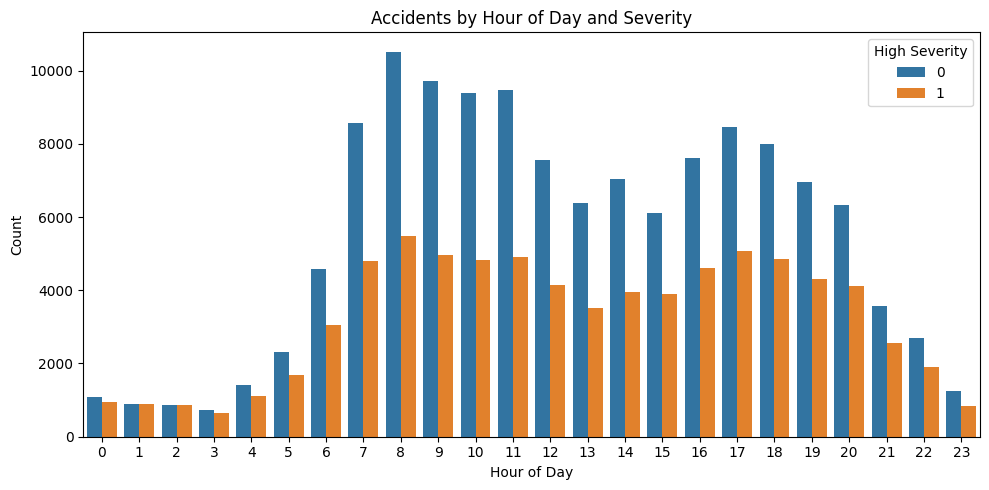

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Build plotting dataframe from final engineered train set
df_plot = pd.concat([X_train.copy(), y_train.rename("is_high_severity")], axis=1)

# Use engineered hour feature from notebook
hour_col = "start_hour"

plot_df = df_plot[[hour_col, "is_high_severity"]].dropna().copy()
plot_df[hour_col] = plot_df[hour_col].astype(int)

plt.figure(figsize=(10, 5))
sns.countplot(data=plot_df, x=hour_col, hue="is_high_severity")
plt.title("Accidents by Hour of Day and Severity")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.legend(title="High Severity")
plt.tight_layout()
plt.show()

Figure 3 — Geographic Heatmap (State-Level Severity)

In [69]:
# State-level severity distribution

if "State" in df_plot.columns:
    state_summary = df_plot.groupby("State")["is_high_severity"].mean().sort_values(ascending=False)

    plt.figure(figsize=(12,6))
    state_summary.head(20).plot(kind="bar")
    plt.title("Top States by High-Severity Accident Rate")
    plt.xlabel("State")
    plt.ylabel("High Severity Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("State column not available for geographic analysis.")

State column not available for geographic analysis.


FIGURE 4 — ROC Curve (Model Comparison)

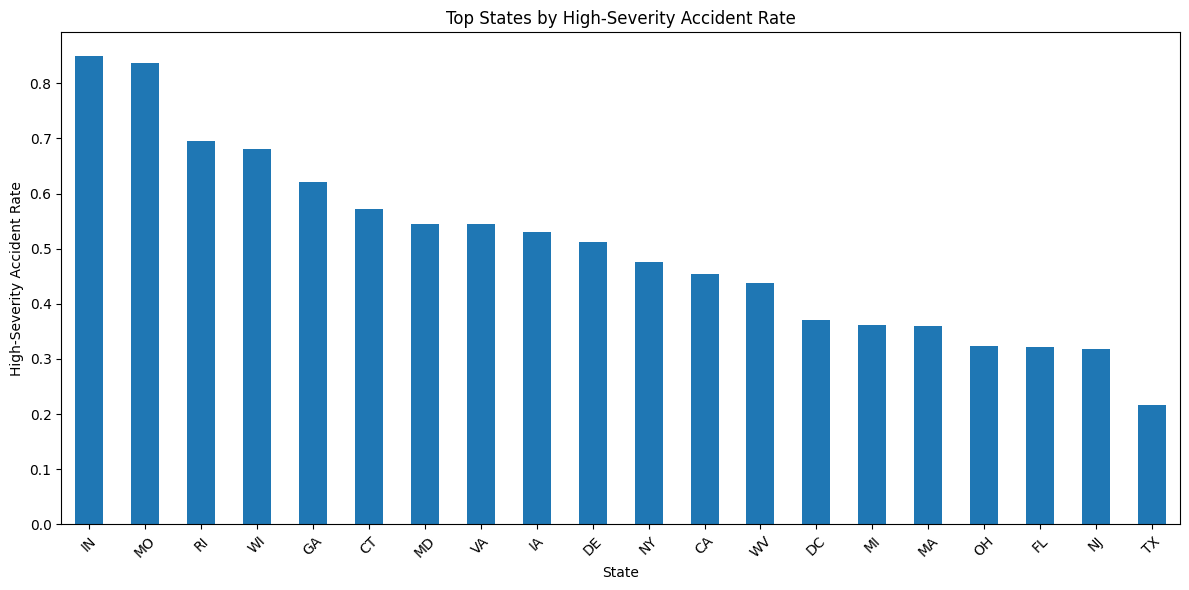

In [70]:
import matplotlib.pyplot as plt
import pandas as pd

df_geo = train_df.copy()

# Ensure target exists
if "is_high_severity" not in df_geo.columns:
    df_geo["is_high_severity"] = (df_geo["Severity"] >= 3).astype(int)

state_col = "state"

state_summary = (
    df_geo.groupby(state_col)["is_high_severity"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
state_summary.head(20).plot(kind="bar")
plt.title("Top States by High-Severity Accident Rate")
plt.xlabel("State")
plt.ylabel("High-Severity Accident Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To maintain clarity and interpretability, the visualization displays only the top 20 states ranked by the proportion of high-severity accidents rather than all states in the dataset. While the dataset includes observations from across the United States, plotting all states would result in a crowded and less readable figure, reducing its analytical value.

Focusing on the top states highlights the most meaningful variation in severity rates and allows for clearer comparison across regions. It is important to note that this visualization reflects relative severity rates, not total accident counts, and is intended to illustrate geographic differences in severity patterns rather than provide a comprehensive national ranking.

FIGURE 5 — Precision-Recall Curve

In [71]:
logreg_probs = logreg_test_proba
lgbm_probs = champion_model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


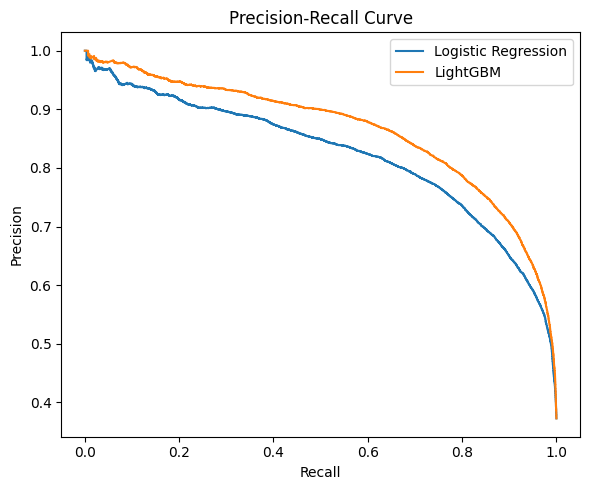

In [72]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_lr, recall_lr, _ = precision_recall_curve(y_test, logreg_probs)
precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, lgbm_probs)

plt.figure(figsize=(6,5))
plt.plot(recall_lr, precision_lr, label="Logistic Regression")
plt.plot(recall_lgbm, precision_lgbm, label="LightGBM")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

Figure 6 - High Severity Accident Rate Clarified

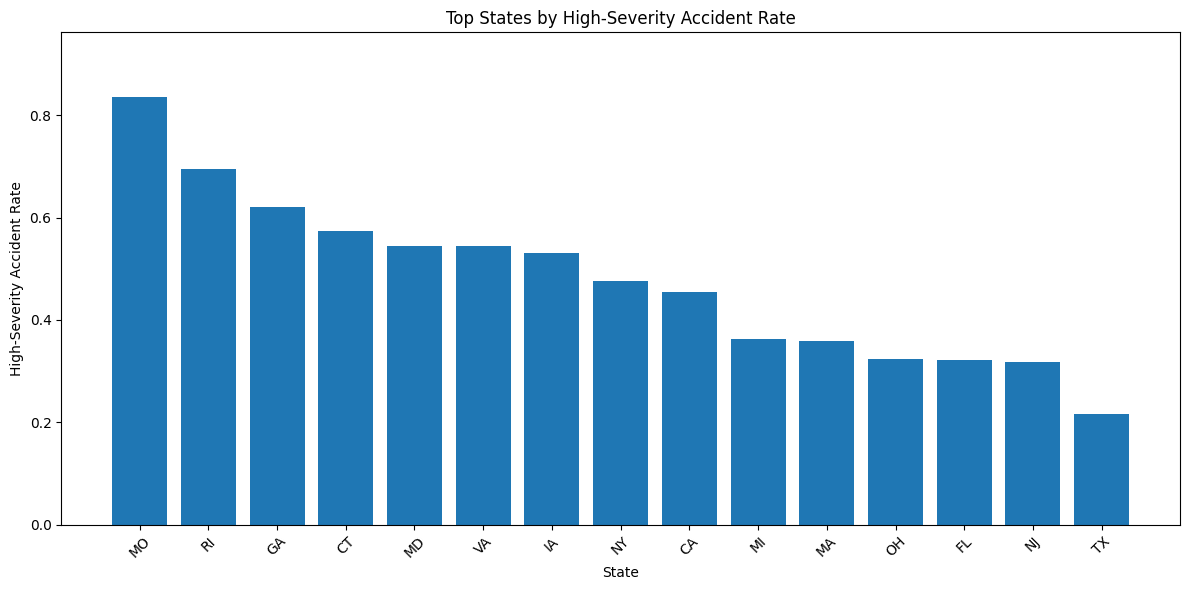

,state,high_severity_rate,accident_count
13,MO,0.836478,795
20,RI,0.695860,628
5,GA,0.620965,8147
1,CT,0.572873,1681
11,MD,0.545042,4407
23,VA,0.544513,3089
6,IA,0.530531,999
17,NY,0.476601,10428
0,CA,0.454684,80623
12,MI,0.362253,10708


In [73]:
# Final presentation plot: high-severity accident rate by state

import matplotlib.pyplot as plt
import pandas as pd

plot_df = train_df.copy()

if "is_high_severity" not in plot_df.columns:
    plot_df["is_high_severity"] = (plot_df["Severity"] >= 3).astype(int)

state_col = "state" if "state" in plot_df.columns else "State"

state_rate = (
    plot_df.groupby(state_col)
    .agg(
        high_severity_rate=("is_high_severity", "mean"),
        accident_count=("is_high_severity", "size")
    )
    .reset_index()
)

# Keep states with enough records to avoid noisy tiny-sample rates
state_rate = state_rate[state_rate["accident_count"] >= 500]

state_rate = state_rate.sort_values("high_severity_rate", ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.bar(state_rate[state_col], state_rate["high_severity_rate"])
plt.title("Top States by High-Severity Accident Rate")
plt.xlabel("State")
plt.ylabel("High-Severity Accident Rate")
plt.xticks(rotation=45)
plt.ylim(0, state_rate["high_severity_rate"].max() * 1.15)
plt.tight_layout()
plt.show()

display(state_rate)

High-Severity Accident Rate by State

This section analyzes how the rate of high-severity accidents (Severity ≥ 3) varies across states.

Approach:

Created binary target: is_high_severity = 1 if Severity ≥ 3
Grouped by state to compute:
Mean → high-severity rate
Count → number of accidents
Filtered states with fewer than 500 records to reduce noise
Selected top 15 states by high-severity rate

Observations:

High-severity rates vary significantly by state
Some states (e.g., MO, RI) have high rates but smaller sample sizes
States like GA, MD, and VA show high rates with stronger data volume
High-volume states (e.g., CA, TX) do not have the highest severity rates

Conclusion:
Accident severity is not purely driven by frequency.
Geographic and contextual factors influence whether an accident becomes high severity, supporting the need for predictive modeling.

# BACK-UP Plots/Graphs for Final Report

Figure 1 Report

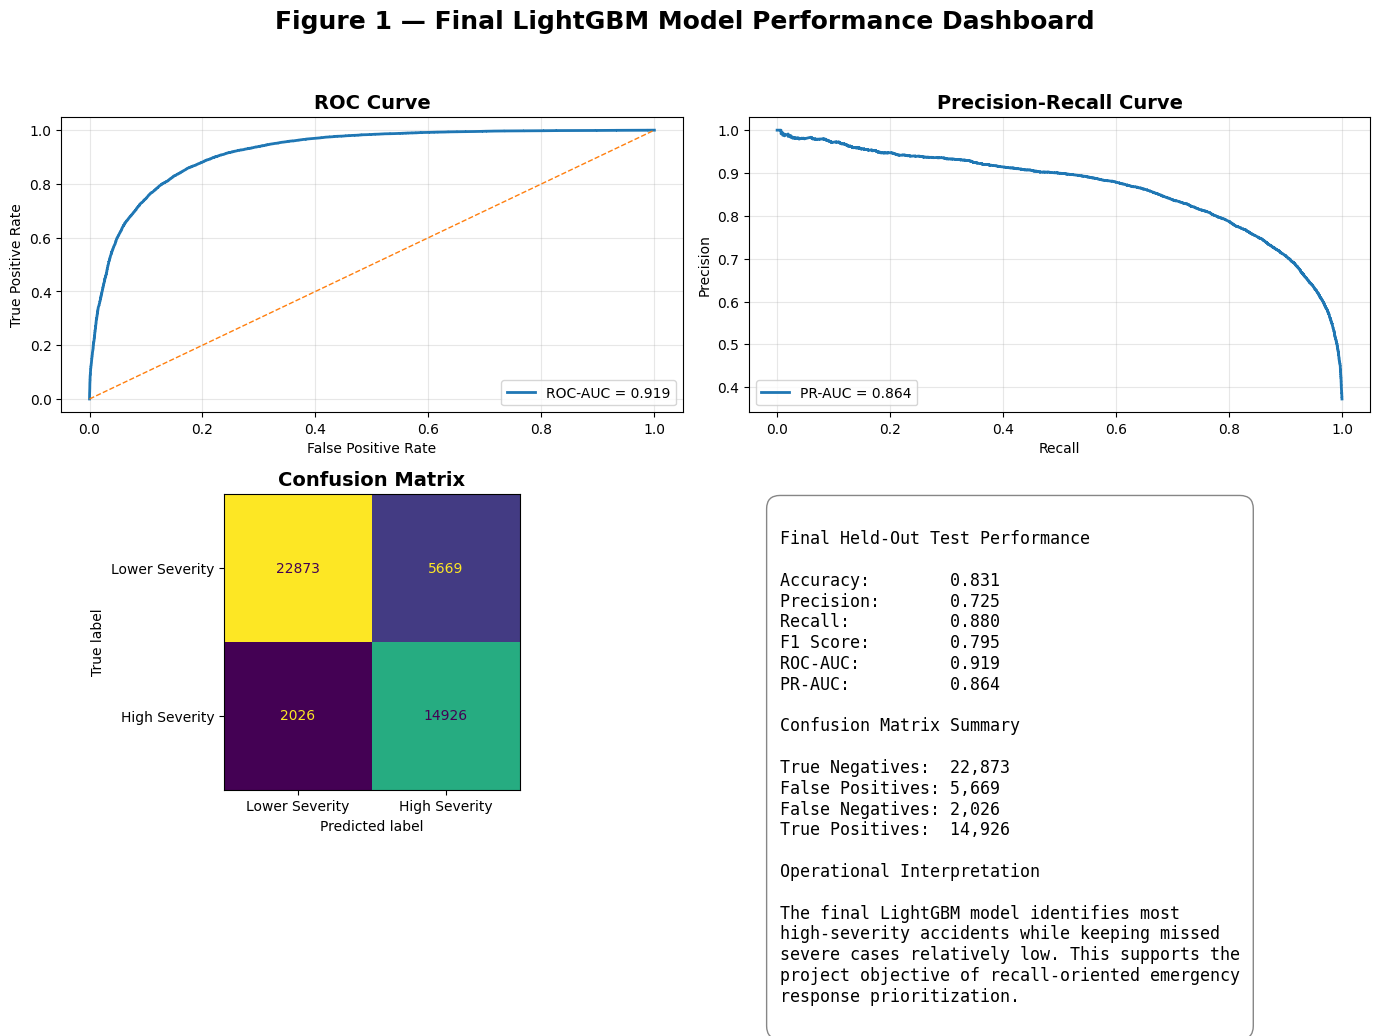

Figure 1 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_1_final_model_performance_dashboard.png


In [74]:
# Figure 1 — Final Model Performance Dashboard
# ROC-AUC, PR-AUC, Precision, Recall, and Confusion Matrix

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Confirm required variables exist
# Expected from final notebook:
# y_test
# y_test_proba
# y_test_pred

# Fallbacks in case notebook used slightly different variable names
if "y_test_proba" not in globals():
    if "lgbm_test_proba" in globals():
        y_test_proba = lgbm_test_proba
    elif "test_proba" in globals():
        y_test_proba = test_proba
    else:
        raise NameError("Could not find y_test_proba, lgbm_test_proba, or test_proba.")

if "y_test_pred" not in globals():
    if "lgbm_test_pred" in globals():
        y_test_pred = lgbm_test_pred
    elif "test_pred" in globals():
        y_test_pred = test_pred
    else:
        raise NameError("Could not find y_test_pred, lgbm_test_pred, or test_pred.")

# Ensure arrays
y_test_arr = np.asarray(y_test)
y_proba_arr = np.asarray(y_test_proba)
y_pred_arr = np.asarray(y_test_pred)

# Calculate metrics

roc_auc = roc_auc_score(y_test_arr, y_proba_arr)
pr_auc = average_precision_score(y_test_arr, y_proba_arr)
precision = precision_score(y_test_arr, y_pred_arr, zero_division=0)
recall = recall_score(y_test_arr, y_pred_arr, zero_division=0)
f1 = f1_score(y_test_arr, y_pred_arr, zero_division=0)
accuracy = accuracy_score(y_test_arr, y_pred_arr)

cm = confusion_matrix(y_test_arr, y_pred_arr)
tn, fp, fn, tp = cm.ravel()

# Curves
fpr, tpr, _ = roc_curve(y_test_arr, y_proba_arr)
pr_precision, pr_recall, _ = precision_recall_curve(y_test_arr, y_proba_arr)

# Create dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    "Figure 1 — Final LightGBM Model Performance Dashboard",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# ROC Curve
axes[0, 0].plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[0, 0].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# Precision-Recall Curve
axes[0, 1].plot(pr_recall, pr_precision, linewidth=2, label=f"PR-AUC = {pr_auc:.3f}")
axes[0, 1].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].legend(loc="lower left")
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Lower Severity", "High Severity"]
)
disp.plot(ax=axes[1, 0], values_format="d", colorbar=False)
axes[1, 0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
axes[1, 0].grid(False)

# Metric Summary Panel
axes[1, 1].axis("off")

metric_text = f"""
Final Held-Out Test Performance

Accuracy:        {accuracy:.3f}
Precision:       {precision:.3f}
Recall:          {recall:.3f}
F1 Score:        {f1:.3f}
ROC-AUC:         {roc_auc:.3f}
PR-AUC:          {pr_auc:.3f}

Confusion Matrix Summary

True Negatives:  {tn:,}
False Positives: {fp:,}
False Negatives: {fn:,}
True Positives:  {tp:,}

Operational Interpretation

The final LightGBM model identifies most
high-severity accidents while keeping missed
severe cases relatively low. This supports the
project objective of recall-oriented emergency
response prioritization.
"""

axes[1, 1].text(
    0.05,
    0.95,
    metric_text,
    va="top",
    ha="left",
    fontsize=12,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="gray", alpha=0.95)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure for report insertion
figure_path = PROJECT_DIR / "figures" / "figure_1_final_model_performance_dashboard.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 1 saved to: {figure_path}")

Figure 2 Report

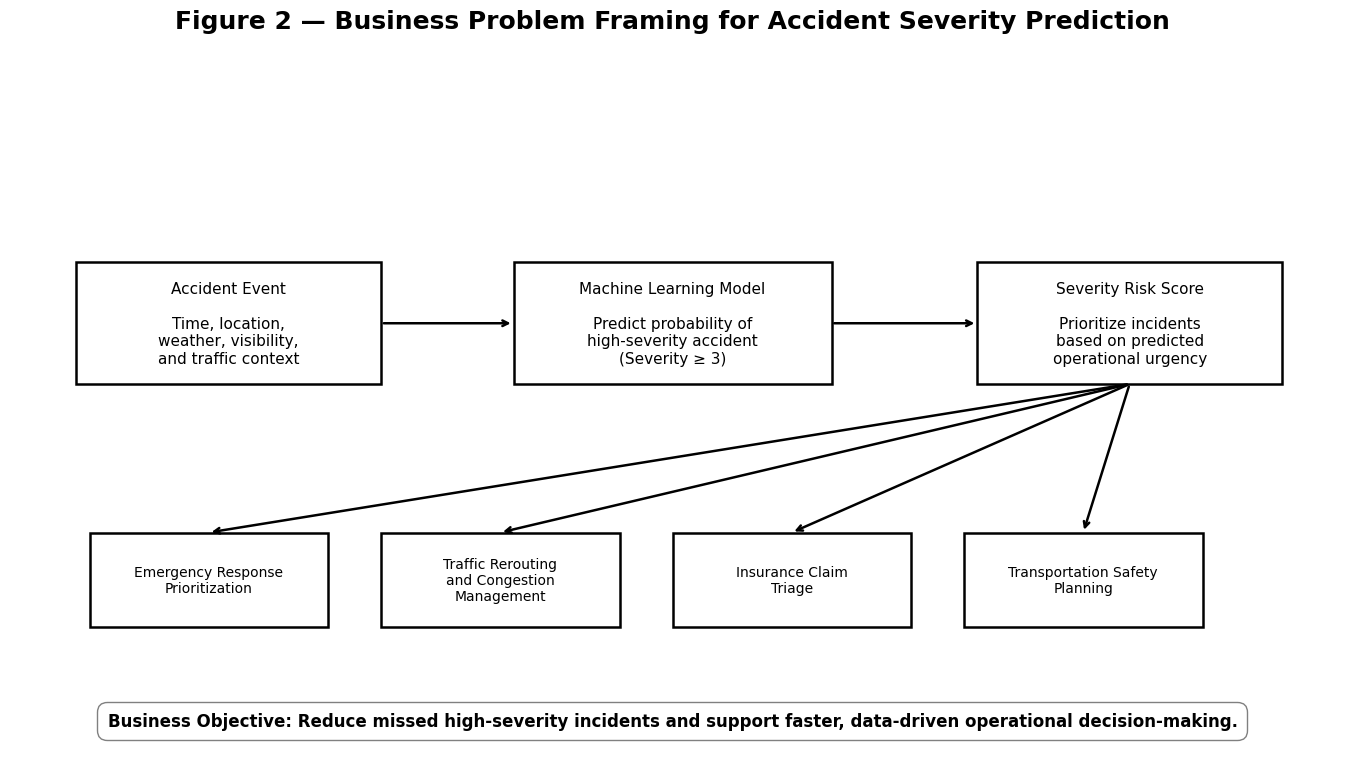

Figure 2 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_2_business_problem_framing.png


In [75]:
# Figure 2 — Business Problem Framing Diagram
# Operational Use Cases for Severity Prediction

import matplotlib.pyplot as plt
from pathlib import Path

# Ensure figure folder exists
figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

fig.suptitle(
    "Figure 2 — Business Problem Framing for Accident Severity Prediction",
    fontsize=18,
    fontweight="bold",
    y=0.96
)

# Box helper
def draw_box(x, y, text, width=0.24, height=0.13, fontsize=11):
    box = plt.Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=1.8
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )

# Arrow helper
def draw_arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.8)
    )

# Main pipeline boxes
draw_box(
    0.05, 0.56,
    "Accident Event\n\nTime, location,\nweather, visibility,\nand traffic context",
    width=0.23,
    height=0.18
)

draw_box(
    0.38, 0.56,
    "Machine Learning Model\n\nPredict probability of\nhigh-severity accident\n(Severity ≥ 3)",
    width=0.24,
    height=0.18
)

draw_box(
    0.73, 0.56,
    "Severity Risk Score\n\nPrioritize incidents\nbased on predicted\noperational urgency",
    width=0.23,
    height=0.18
)

draw_arrow(0.28, 0.65, 0.38, 0.65)
draw_arrow(0.62, 0.65, 0.73, 0.65)

# Operational use cases
use_cases = [
    ("Emergency Response\nPrioritization", 0.06, 0.20),
    ("Traffic Rerouting\nand Congestion\nManagement", 0.28, 0.20),
    ("Insurance Claim\nTriage", 0.50, 0.20),
    ("Transportation Safety\nPlanning", 0.72, 0.20),
]

for text, x, y in use_cases:
    draw_box(x, y, text, width=0.18, height=0.14, fontsize=10)

# Arrows from risk score to use cases
risk_center_x = 0.845
risk_bottom_y = 0.56

for _, x, y in use_cases:
    draw_arrow(risk_center_x, risk_bottom_y, x + 0.09, y + 0.14)

# Bottom business objective statement
ax.text(
    0.5,
    0.06,
    "Business Objective: Reduce missed high-severity incidents and support faster, data-driven operational decision-making.",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="gray")
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

figure_path = figure_dir / "figure_2_business_problem_framing.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 2 saved to: {figure_path}")

Figure 3 Report

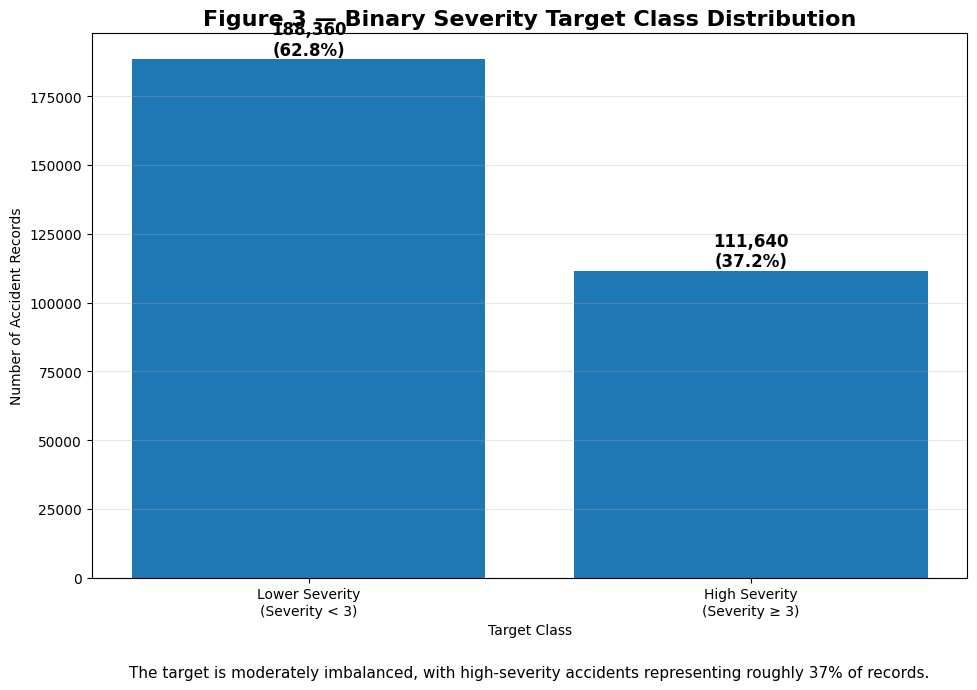

Figure 3 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_3_class_distribution_binary_target.png


In [76]:
# Binary Severity Target

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Find target variable

if "y_train" in globals() and "y_val" in globals() and "y_test" in globals():
    target_series = pd.concat([
        pd.Series(y_train, name="is_high_severity"),
        pd.Series(y_val, name="is_high_severity"),
        pd.Series(y_test, name="is_high_severity")
    ], ignore_index=True)
elif "df" in globals() and "is_high_severity" in df.columns:
    target_series = df["is_high_severity"]
elif "model_df" in globals() and "is_high_severity" in model_df.columns:
    target_series = model_df["is_high_severity"]
else:
    raise NameError("Could not find y_train/y_val/y_test or a dataframe with is_high_severity.")

# Build distribution table

class_counts = target_series.value_counts().sort_index()
class_percent = target_series.value_counts(normalize=True).sort_index() * 100

plot_df = pd.DataFrame({
    "Class": ["Lower Severity\n(Severity < 3)", "High Severity\n(Severity ≥ 3)"],
    "Count": [class_counts.get(0, 0), class_counts.get(1, 0)],
    "Percent": [class_percent.get(0, 0), class_percent.get(1, 0)]
})

# Plot

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(plot_df["Class"], plot_df["Count"])

ax.set_title(
    "Figure 3 — Binary Severity Target Class Distribution",
    fontsize=16,
    fontweight="bold"
)
ax.set_ylabel("Number of Accident Records")
ax.set_xlabel("Target Class")

for bar, count, pct in zip(bars, plot_df["Count"], plot_df["Percent"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.text(
    0.5,
    -0.16,
    "The target is moderately imbalanced, with high-severity accidents representing roughly 37% of records.",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

figure_path = figure_dir / "figure_3_class_distribution_binary_target.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 3 saved to: {figure_path}")

Figure 4 Report

Using dataframe: df
Available columns:
['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'distance_mi', 'temperature_f', 'wind_chill_f', 'humidity_pct', 'pressure_in', 'visibility_mi', 'wind_speed_mph', 'precipitation_in', 'amenity', 'bump', 'crossing', 'give_way', 'junction', 'no_exit', 'railway', 'roundabout', 'station', 'stop', 'traffic_calming', 'traffic_signal', 'turning_loop', 'city', 'state', 'timezone', 'wind_direction', 'weather_condition', 'sunrise_sunset', 'civil_twilight', 'nautical_twilight', 'astronomical_twilight', 'start_year', 'start_month', 'start_day', 'start_dayofweek', 'start_hour', 'is_weekend', 'is_high_severity']
Using hour column: start_hour


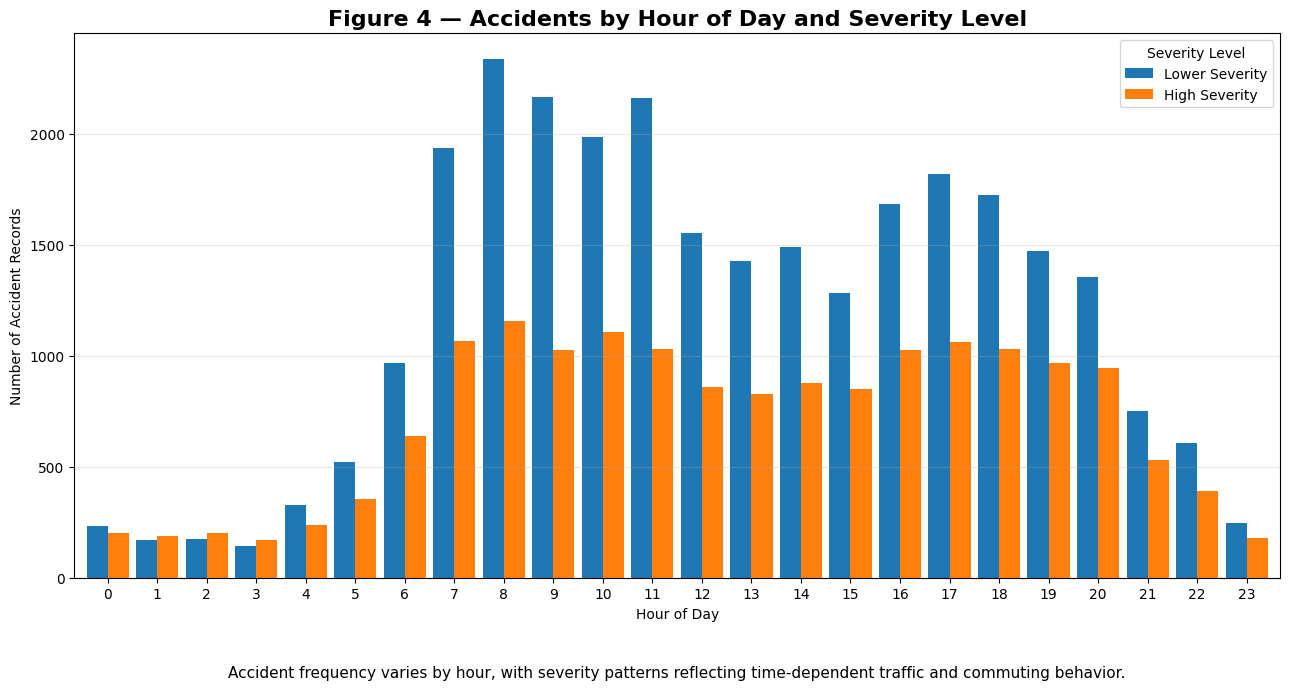

Figure 4 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_4_accidents_by_hour_and_severity.png


In [77]:
# Figure 4 — Accidents by Hour of Day and Severity Level

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Locate best available dataframe

candidate_dfs = {
    "df": globals().get("df", None),
    "model_df": globals().get("model_df", None),
    "accidents_df": globals().get("accidents_df", None),
    "eda_df": globals().get("eda_df", None),
    "train_df": globals().get("train_df", None),
    "val_df": globals().get("val_df", None),
    "test_df": globals().get("test_df", None),
}

available_dfs = {
    name: obj for name, obj in candidate_dfs.items()
    if isinstance(obj, pd.DataFrame)
}

if not available_dfs:
    raise NameError("No pandas dataframe found. Run the data preparation cells first.")

# Prefer full EDA/model dataframe if available
hour_df = None
source_name = None

for name, data in available_dfs.items():
    if "is_high_severity" in data.columns:
        hour_df = data.copy()
        source_name = name
        break

if hour_df is None:
    raise NameError("Found dataframes, but none contain 'is_high_severity'.")

print(f"Using dataframe: {source_name}")
print("Available columns:")
print(list(hour_df.columns))

# Find or create hour column

hour_candidates = [
    "hour",
    "start_hour",
    "Start_Hour",
    "Hour",
    "hour_of_day",
    "start_time_hour"
]

hour_col = None

for col in hour_candidates:
    if col in hour_df.columns:
        hour_col = col
        break

# If no hour column exists, recreate from Start_Time
if hour_col is None:
    time_candidates = ["Start_Time", "start_time", "datetime", "timestamp"]
    time_col = None

    for col in time_candidates:
        if col in hour_df.columns:
            time_col = col
            break

    if time_col is None:
        raise NameError(
            "Could not find an hour column or a datetime column such as 'Start_Time'. "
            "Check the printed column list above."
        )

    hour_df[time_col] = pd.to_datetime(hour_df[time_col], errors="coerce")
    hour_df["hour_for_plot"] = hour_df[time_col].dt.hour
    hour_col = "hour_for_plot"

print(f"Using hour column: {hour_col}")

# Prepare hourly counts

hour_df = hour_df.dropna(subset=[hour_col, "is_high_severity"]).copy()
hour_df[hour_col] = hour_df[hour_col].astype(int)
hour_df["is_high_severity"] = hour_df["is_high_severity"].astype(int)

hour_counts = (
    hour_df
    .groupby([hour_col, "is_high_severity"])
    .size()
    .reset_index(name="count")
)

hour_pivot = (
    hour_counts
    .pivot(index=hour_col, columns="is_high_severity", values="count")
    .fillna(0)
    .reindex(range(24), fill_value=0)
)

hour_pivot = hour_pivot.rename(
    columns={
        0: "Lower Severity",
        1: "High Severity"
    }
)

for col in ["Lower Severity", "High Severity"]:
    if col not in hour_pivot.columns:
        hour_pivot[col] = 0

hour_pivot = hour_pivot[["Lower Severity", "High Severity"]]

# Plot

fig, ax = plt.subplots(figsize=(13, 7))

hour_pivot.plot(
    kind="bar",
    stacked=False,
    ax=ax,
    width=0.85
)

ax.set_title(
    "Figure 4 — Accidents by Hour of Day and Severity Level",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Accident Records")
ax.set_xticklabels([str(h) for h in range(24)], rotation=0)

ax.legend(title="Severity Level")
ax.grid(axis="y", alpha=0.3)

ax.text(
    0.5,
    -0.16,
    "Accident frequency varies by hour, with severity patterns reflecting time-dependent traffic and commuting behavior.",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11
)

plt.tight_layout()

figure_path = figure_dir / "figure_4_accidents_by_hour_and_severity.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 4 saved to: {figure_path}")

Figure 5 Report

Using dataframe: df
Available columns:
['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'distance_mi', 'temperature_f', 'wind_chill_f', 'humidity_pct', 'pressure_in', 'visibility_mi', 'wind_speed_mph', 'precipitation_in', 'amenity', 'bump', 'crossing', 'give_way', 'junction', 'no_exit', 'railway', 'roundabout', 'station', 'stop', 'traffic_calming', 'traffic_signal', 'turning_loop', 'city', 'state', 'timezone', 'wind_direction', 'weather_condition', 'sunrise_sunset', 'civil_twilight', 'nautical_twilight', 'astronomical_twilight', 'start_year', 'start_month', 'start_day', 'start_dayofweek', 'start_hour', 'is_weekend', 'is_high_severity']
Using visibility column: visibility_mi


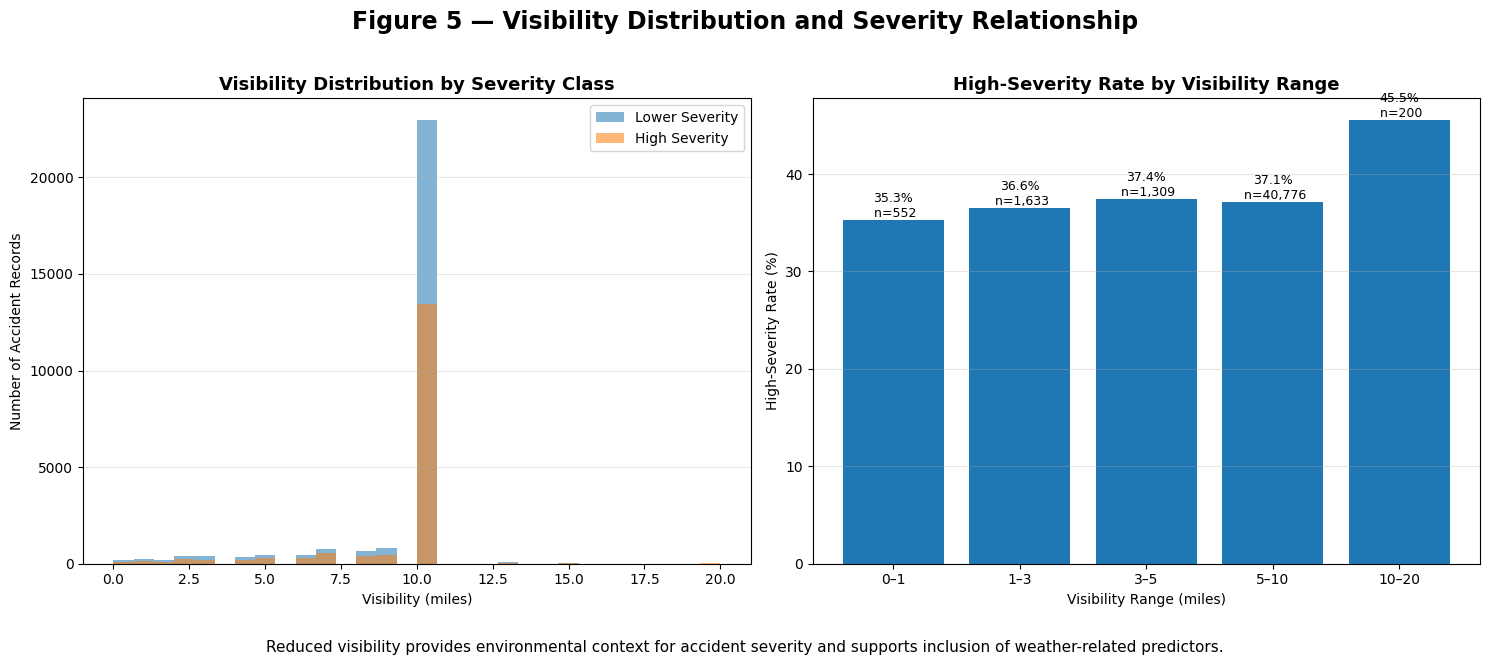

Figure 5 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_5_visibility_distribution_severity_relationship.png


In [78]:
# Figure 5 — Visibility Distribution and Severity Relationship

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Locate best available dataframe

candidate_dfs = {
    "df": globals().get("df", None),
    "model_df": globals().get("model_df", None),
    "accidents_df": globals().get("accidents_df", None),
    "eda_df": globals().get("eda_df", None),
    "train_df": globals().get("train_df", None),
    "val_df": globals().get("val_df", None),
    "test_df": globals().get("test_df", None),
}

available_dfs = {
    name: obj for name, obj in candidate_dfs.items()
    if isinstance(obj, pd.DataFrame)
}

if not available_dfs:
    raise NameError("No pandas dataframe found. Run the data preparation cells first.")

plot_df = None
source_name = None

for name, data in available_dfs.items():
    if "is_high_severity" in data.columns:
        plot_df = data.copy()
        source_name = name
        break

if plot_df is None:
    raise NameError("Found dataframes, but none contain 'is_high_severity'.")

print(f"Using dataframe: {source_name}")
print("Available columns:")
print(list(plot_df.columns))

# Find visibility column

visibility_candidates = [
    "Visibility(mi)",
    "Visibility",
    "visibility",
    "visibility_mi",
    "Visibility_mi",
    "visibility_miles"
]

visibility_col = None

for col in visibility_candidates:
    if col in plot_df.columns:
        visibility_col = col
        break

if visibility_col is None:
    raise NameError(
        "Could not find a visibility column. Check the printed column list above "
        "for the exact visibility field name."
    )

print(f"Using visibility column: {visibility_col}")

# Clean data

plot_df = plot_df[[visibility_col, "is_high_severity"]].copy()
plot_df[visibility_col] = pd.to_numeric(plot_df[visibility_col], errors="coerce")
plot_df["is_high_severity"] = plot_df["is_high_severity"].astype(int)

plot_df = plot_df.dropna(subset=[visibility_col, "is_high_severity"])

# Remove unrealistic extreme visibility values for cleaner report figure
plot_df = plot_df[(plot_df[visibility_col] >= 0) & (plot_df[visibility_col] <= 20)]

plot_df["severity_label"] = plot_df["is_high_severity"].map({
    0: "Lower Severity",
    1: "High Severity"
})

# Create visibility bins for severity relationship
bins = [0, 1, 3, 5, 10, 20]
labels = ["0–1", "1–3", "3–5", "5–10", "10–20"]

plot_df["visibility_bin"] = pd.cut(
    plot_df[visibility_col],
    bins=bins,
    labels=labels,
    include_lowest=True
)

bin_summary = (
    plot_df
    .dropna(subset=["visibility_bin"])
    .groupby("visibility_bin", observed=False)
    .agg(
        accident_count=("is_high_severity", "size"),
        high_severity_rate=("is_high_severity", "mean")
    )
    .reset_index()
)

bin_summary["high_severity_rate_pct"] = bin_summary["high_severity_rate"] * 100

# Plot dashboard

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

fig.suptitle(
    "Figure 5 — Visibility Distribution and Severity Relationship",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

# Left: visibility distribution by class
for label in ["Lower Severity", "High Severity"]:
    subset = plot_df.loc[plot_df["severity_label"] == label, visibility_col]
    axes[0].hist(
        subset,
        bins=30,
        alpha=0.55,
        label=label
    )

axes[0].set_title("Visibility Distribution by Severity Class", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Visibility (miles)")
axes[0].set_ylabel("Number of Accident Records")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Right: high-severity rate by visibility bin
bars = axes[1].bar(
    bin_summary["visibility_bin"].astype(str),
    bin_summary["high_severity_rate_pct"]
)

axes[1].set_title("High-Severity Rate by Visibility Range", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Visibility Range (miles)")
axes[1].set_ylabel("High-Severity Rate (%)")
axes[1].grid(axis="y", alpha=0.3)

for bar, rate, count in zip(
    bars,
    bin_summary["high_severity_rate_pct"],
    bin_summary["accident_count"]
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n n={count:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

fig.text(
    0.5,
    -0.03,
    "Reduced visibility provides environmental context for accident severity and supports inclusion of weather-related predictors.",
    ha="center",
    va="top",
    fontsize=11
)

plt.tight_layout()

figure_path = figure_dir / "figure_5_visibility_distribution_severity_relationship.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 5 saved to: {figure_path}")

Figure 6 Report

Using dataframe: df
Available columns:
['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'distance_mi', 'temperature_f', 'wind_chill_f', 'humidity_pct', 'pressure_in', 'visibility_mi', 'wind_speed_mph', 'precipitation_in', 'amenity', 'bump', 'crossing', 'give_way', 'junction', 'no_exit', 'railway', 'roundabout', 'station', 'stop', 'traffic_calming', 'traffic_signal', 'turning_loop', 'city', 'state', 'timezone', 'wind_direction', 'weather_condition', 'sunrise_sunset', 'civil_twilight', 'nautical_twilight', 'astronomical_twilight', 'start_year', 'start_month', 'start_day', 'start_dayofweek', 'start_hour', 'is_weekend', 'is_high_severity']
Using state column: state


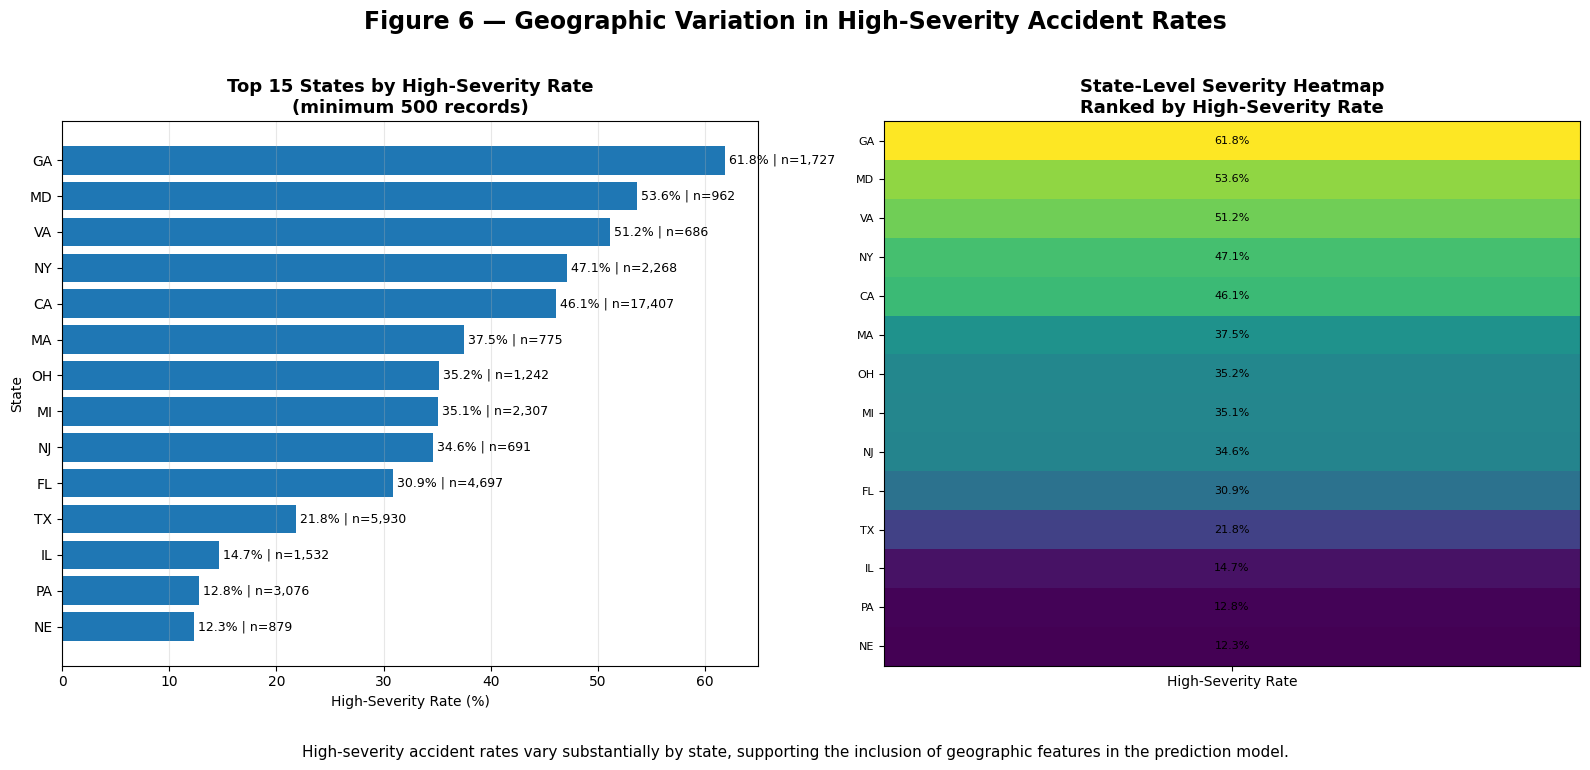

Figure 6 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_6_geographic_high_severity_rates.png


In [79]:
# Figure 6 — Geographic Heatmap and State-Level Severity Rates
# State-Level High-Severity Rate Visualization

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Locate best available dataframe

candidate_dfs = {
    "df": globals().get("df", None),
    "model_df": globals().get("model_df", None),
    "accidents_df": globals().get("accidents_df", None),
    "eda_df": globals().get("eda_df", None),
    "train_df": globals().get("train_df", None),
    "val_df": globals().get("val_df", None),
    "test_df": globals().get("test_df", None),
}

available_dfs = {
    name: obj for name, obj in candidate_dfs.items()
    if isinstance(obj, pd.DataFrame)
}

if not available_dfs:
    raise NameError("No pandas dataframe found. Run the data preparation cells first.")

geo_df = None
source_name = None

for name, data in available_dfs.items():
    if "is_high_severity" in data.columns:
        geo_df = data.copy()
        source_name = name
        break

if geo_df is None:
    raise NameError("Found dataframes, but none contain 'is_high_severity'.")

print(f"Using dataframe: {source_name}")
print("Available columns:")
print(list(geo_df.columns))

# Find state column

state_candidates = [
    "State",
    "state",
    "state_code",
    "State_Code",
    "region_state"
]

state_col = None

for col in state_candidates:
    if col in geo_df.columns:
        state_col = col
        break

if state_col is None:
    raise NameError(
        "Could not find a state column. Check the printed column list above "
        "for the exact state field name."
    )

print(f"Using state column: {state_col}")

# Prepare state-level summary

geo_df = geo_df[[state_col, "is_high_severity"]].copy()
geo_df[state_col] = geo_df[state_col].astype(str).str.upper().str.strip()
geo_df["is_high_severity"] = geo_df["is_high_severity"].astype(int)

state_summary = (
    geo_df
    .dropna(subset=[state_col, "is_high_severity"])
    .groupby(state_col)
    .agg(
        accident_count=("is_high_severity", "size"),
        high_severity_rate=("is_high_severity", "mean")
    )
    .reset_index()
)

state_summary["high_severity_rate_pct"] = state_summary["high_severity_rate"] * 100

# Filter small states/sparse records to reduce noise
min_records = 500
state_summary_filtered = state_summary[state_summary["accident_count"] >= min_records].copy()

top_states = (
    state_summary_filtered
    .sort_values("high_severity_rate_pct", ascending=False)
    .head(15)
    .sort_values("high_severity_rate_pct", ascending=True)
)

# Plot dashboard

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

fig.suptitle(
    "Figure 6 — Geographic Variation in High-Severity Accident Rates",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

# Left: Top 15 state-level high-severity rates
bars = axes[0].barh(
    top_states[state_col],
    top_states["high_severity_rate_pct"]
)

axes[0].set_title(
    f"Top 15 States by High-Severity Rate\n(minimum {min_records:,} records)",
    fontsize=13,
    fontweight="bold"
)
axes[0].set_xlabel("High-Severity Rate (%)")
axes[0].set_ylabel("State")
axes[0].grid(axis="x", alpha=0.3)

for bar, rate, count in zip(
    bars,
    top_states["high_severity_rate_pct"],
    top_states["accident_count"]
):
    axes[0].text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {rate:.1f}% | n={count:,}",
        va="center",
        fontsize=9
    )

# Right: all states as heatmap-style ranked tile chart
heatmap_df = state_summary_filtered.sort_values("high_severity_rate_pct", ascending=False).copy()
heatmap_df = heatmap_df.reset_index(drop=True)

# Limit to all filtered states, arranged as ranked vertical heatmap
axes[1].imshow(
    heatmap_df[["high_severity_rate_pct"]].values,
    aspect="auto"
)

axes[1].set_title(
    "State-Level Severity Heatmap\nRanked by High-Severity Rate",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_xticks([0])
axes[1].set_xticklabels(["High-Severity Rate"])
axes[1].set_yticks(range(len(heatmap_df)))
axes[1].set_yticklabels(heatmap_df[state_col], fontsize=8)

for i, row in heatmap_df.iterrows():
    axes[1].text(
        0,
        i,
        f"{row['high_severity_rate_pct']:.1f}%",
        ha="center",
        va="center",
        fontsize=8
    )

fig.text(
    0.5,
    -0.03,
    "High-severity accident rates vary substantially by state, supporting the inclusion of geographic features in the prediction model.",
    ha="center",
    va="top",
    fontsize=11
)

plt.tight_layout()

figure_path = figure_dir / "figure_6_geographic_high_severity_rates.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 6 saved to: {figure_path}")

Figure 7 Report

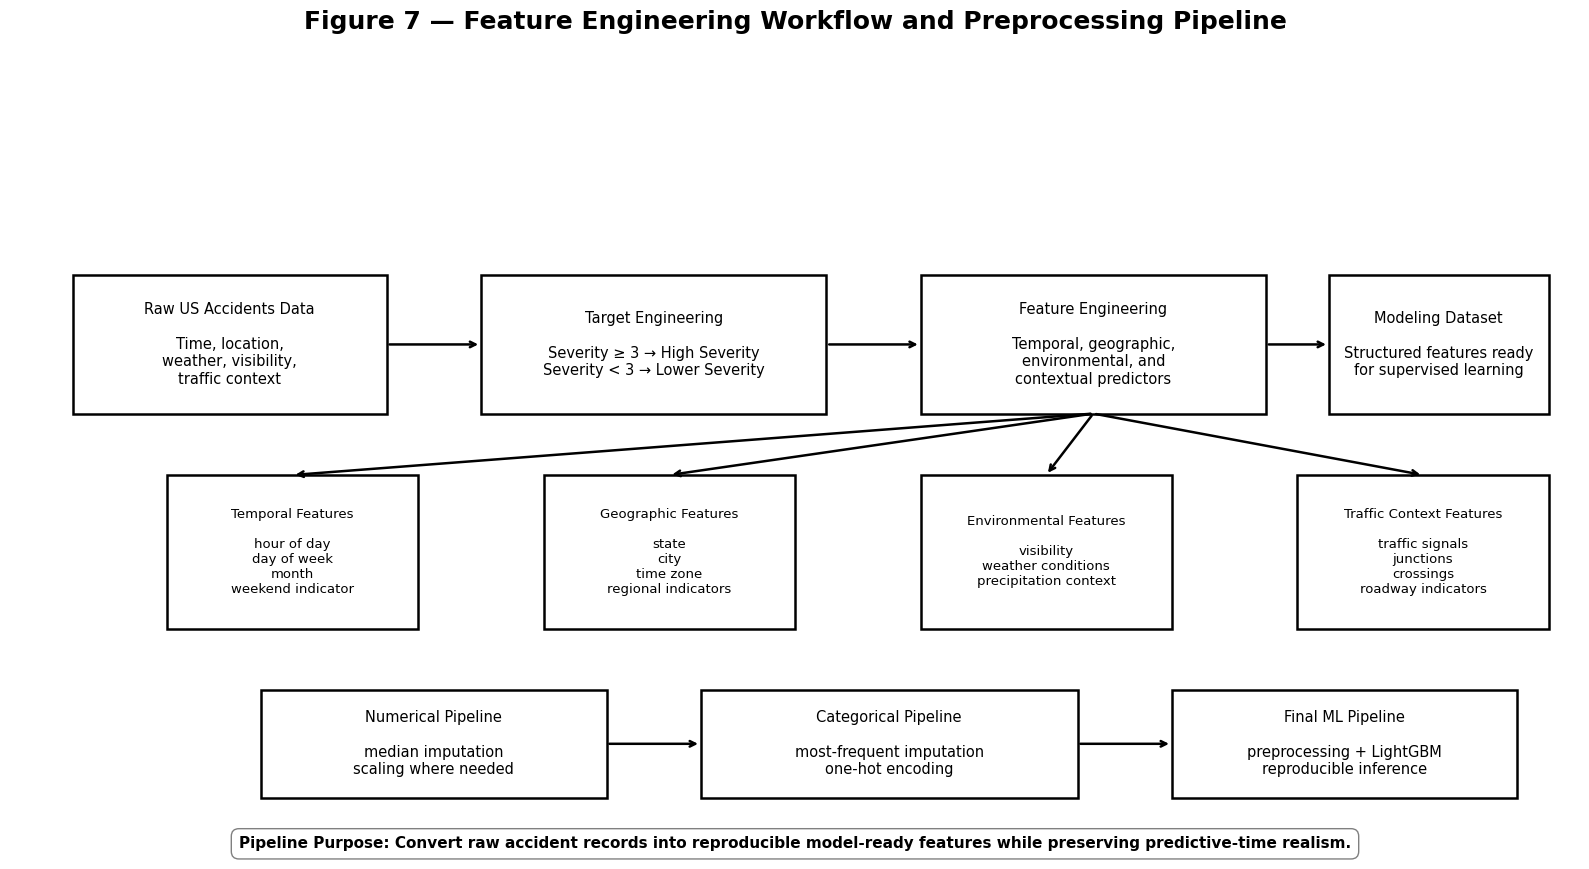

Figure 7 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_7_feature_engineering_preprocessing_pipeline.png


In [80]:
# Figure 7 — Feature Engineering Workflow and Preprocessing Pipeline

import matplotlib.pyplot as plt
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 9))
ax.axis("off")

fig.suptitle(
    "Figure 7 — Feature Engineering Workflow and Preprocessing Pipeline",
    fontsize=18,
    fontweight="bold",
    y=0.96
)

# Helper functions

def draw_box(x, y, text, width=0.20, height=0.13, fontsize=10.5):
    box = plt.Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=1.8
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )

def draw_arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.8)
    )

# Main workflow

draw_box(
    0.04, 0.58,
    "Raw US Accidents Data\n\nTime, location,\nweather, visibility,\ntraffic context",
    width=0.20,
    height=0.18
)

draw_box(
    0.30, 0.58,
    "Target Engineering\n\nSeverity ≥ 3 → High Severity\nSeverity < 3 → Lower Severity",
    width=0.22,
    height=0.18
)

draw_box(
    0.58, 0.58,
    "Feature Engineering\n\nTemporal, geographic,\nenvironmental, and\ncontextual predictors",
    width=0.22,
    height=0.18
)

draw_box(
    0.84, 0.58,
    "Modeling Dataset\n\nStructured features ready\nfor supervised learning",
    width=0.14,
    height=0.18
)

draw_arrow(0.24, 0.67, 0.30, 0.67)
draw_arrow(0.52, 0.67, 0.58, 0.67)
draw_arrow(0.80, 0.67, 0.84, 0.67)

# Feature categories

feature_boxes = [
    (
        0.10, 0.30,
        "Temporal Features\n\nhour of day\nday of week\nmonth\nweekend indicator"
    ),
    (
        0.34, 0.30,
        "Geographic Features\n\nstate\ncity\ntime zone\nregional indicators"
    ),
    (
        0.58, 0.30,
        "Environmental Features\n\nvisibility\nweather conditions\nprecipitation context"
    ),
    (
        0.82, 0.30,
        "Traffic Context Features\n\ntraffic signals\njunctions\ncrossings\nroadway indicators"
    ),
]

for x, y, text in feature_boxes:
    draw_box(x, y, text, width=0.16, height=0.20, fontsize=9.5)
    draw_arrow(0.69, 0.58, x + 0.08, y + 0.20)

# Preprocessing pipeline

draw_box(
    0.16, 0.08,
    "Numerical Pipeline\n\nmedian imputation\nscaling where needed",
    width=0.22,
    height=0.14
)

draw_box(
    0.44, 0.08,
    "Categorical Pipeline\n\nmost-frequent imputation\none-hot encoding",
    width=0.24,
    height=0.14
)

draw_box(
    0.74, 0.08,
    "Final ML Pipeline\n\npreprocessing + LightGBM\nreproducible inference",
    width=0.22,
    height=0.14
)

draw_arrow(0.38, 0.15, 0.44, 0.15)
draw_arrow(0.68, 0.15, 0.74, 0.15)

ax.text(
    0.5,
    0.01,
    "Pipeline Purpose: Convert raw accident records into reproducible model-ready features while preserving predictive-time realism.",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray")
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

figure_path = figure_dir / "figure_7_feature_engineering_preprocessing_pipeline.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 7 saved to: {figure_path}")

Figure 8 Report

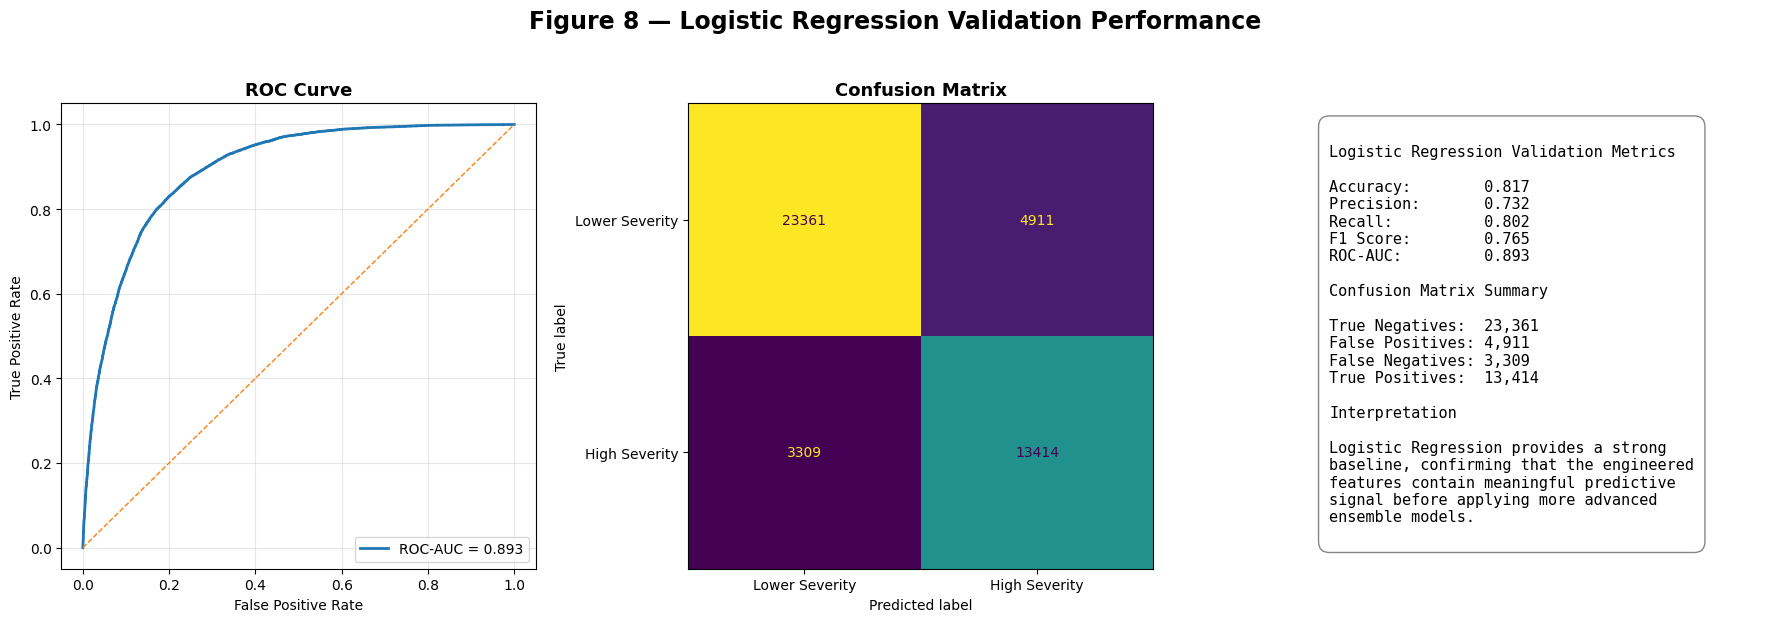

Figure 8 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_8_logistic_regression_confusion_matrix_roc.png


In [81]:
# Figure 8 — Logistic Regression Confusion Matrix and ROC Curve

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score
)

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Locate Logistic Regression outputs

if "y_val" not in globals():
    raise NameError("Could not find y_val. Run the validation/model evaluation cells first.")

# Probability fallback options
if "y_val_proba_logreg" in globals():
    logreg_proba = y_val_proba_logreg
elif "logreg_val_proba" in globals():
    logreg_proba = logreg_val_proba
elif "lr_val_proba" in globals():
    logreg_proba = lr_val_proba
elif "logreg_pipeline" in globals() and "X_val" in globals():
    logreg_proba = logreg_pipeline.predict_proba(X_val)[:, 1]
else:
    raise NameError(
        "Could not find Logistic Regression validation probabilities. "
        "Expected y_val_proba_logreg, logreg_val_proba, lr_val_proba, "
        "or logreg_pipeline with X_val."
    )

# Prediction fallback options

if "y_val_pred_logreg_final" in globals():
    logreg_pred = y_val_pred_logreg_final
elif "y_val_pred_logreg" in globals():
    logreg_pred = y_val_pred_logreg
elif "logreg_val_pred" in globals():
    logreg_pred = logreg_val_pred
elif "lr_val_pred" in globals():
    logreg_pred = lr_val_pred
elif "logreg_best_threshold" in globals():
    logreg_pred = (np.asarray(logreg_proba) >= logreg_best_threshold).astype(int)
else:
    logreg_pred = (np.asarray(logreg_proba) >= 0.50).astype(int)

# Calculate metrics

y_val_arr = np.asarray(y_val)
logreg_proba = np.asarray(logreg_proba)
logreg_pred = np.asarray(logreg_pred)

cm = confusion_matrix(y_val_arr, logreg_pred)
roc_auc = roc_auc_score(y_val_arr, logreg_proba)
fpr, tpr, _ = roc_curve(y_val_arr, logreg_proba)

accuracy = accuracy_score(y_val_arr, logreg_pred)
precision = precision_score(y_val_arr, logreg_pred, zero_division=0)
recall = recall_score(y_val_arr, logreg_pred, zero_division=0)
f1 = f1_score(y_val_arr, logreg_pred, zero_division=0)

tn, fp, fn, tp = cm.ravel()

# Plot dashboard

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fig.suptitle(
    "Figure 8 — Logistic Regression Validation Performance",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

# ROC Curve

axes[0].plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[0].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Confusion Matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Lower Severity", "High Severity"]
)
disp.plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("Confusion Matrix", fontsize=13, fontweight="bold")
axes[1].grid(False)

# Metric summary

axes[2].axis("off")

metric_text = f"""
Logistic Regression Validation Metrics

Accuracy:        {accuracy:.3f}
Precision:       {precision:.3f}
Recall:          {recall:.3f}
F1 Score:        {f1:.3f}
ROC-AUC:         {roc_auc:.3f}

Confusion Matrix Summary

True Negatives:  {tn:,}
False Positives: {fp:,}
False Negatives: {fn:,}
True Positives:  {tp:,}

Interpretation

Logistic Regression provides a strong
baseline, confirming that the engineered
features contain meaningful predictive
signal before applying more advanced
ensemble models.
"""

axes[2].text(
    0.05,
    0.95,
    metric_text,
    va="top",
    ha="left",
    fontsize=11,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.7", facecolor="white", edgecolor="gray", alpha=0.95)
)

plt.tight_layout()

figure_path = figure_dir / "figure_8_logistic_regression_confusion_matrix_roc.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 8 saved to: {figure_path}")

Figure 9 Report

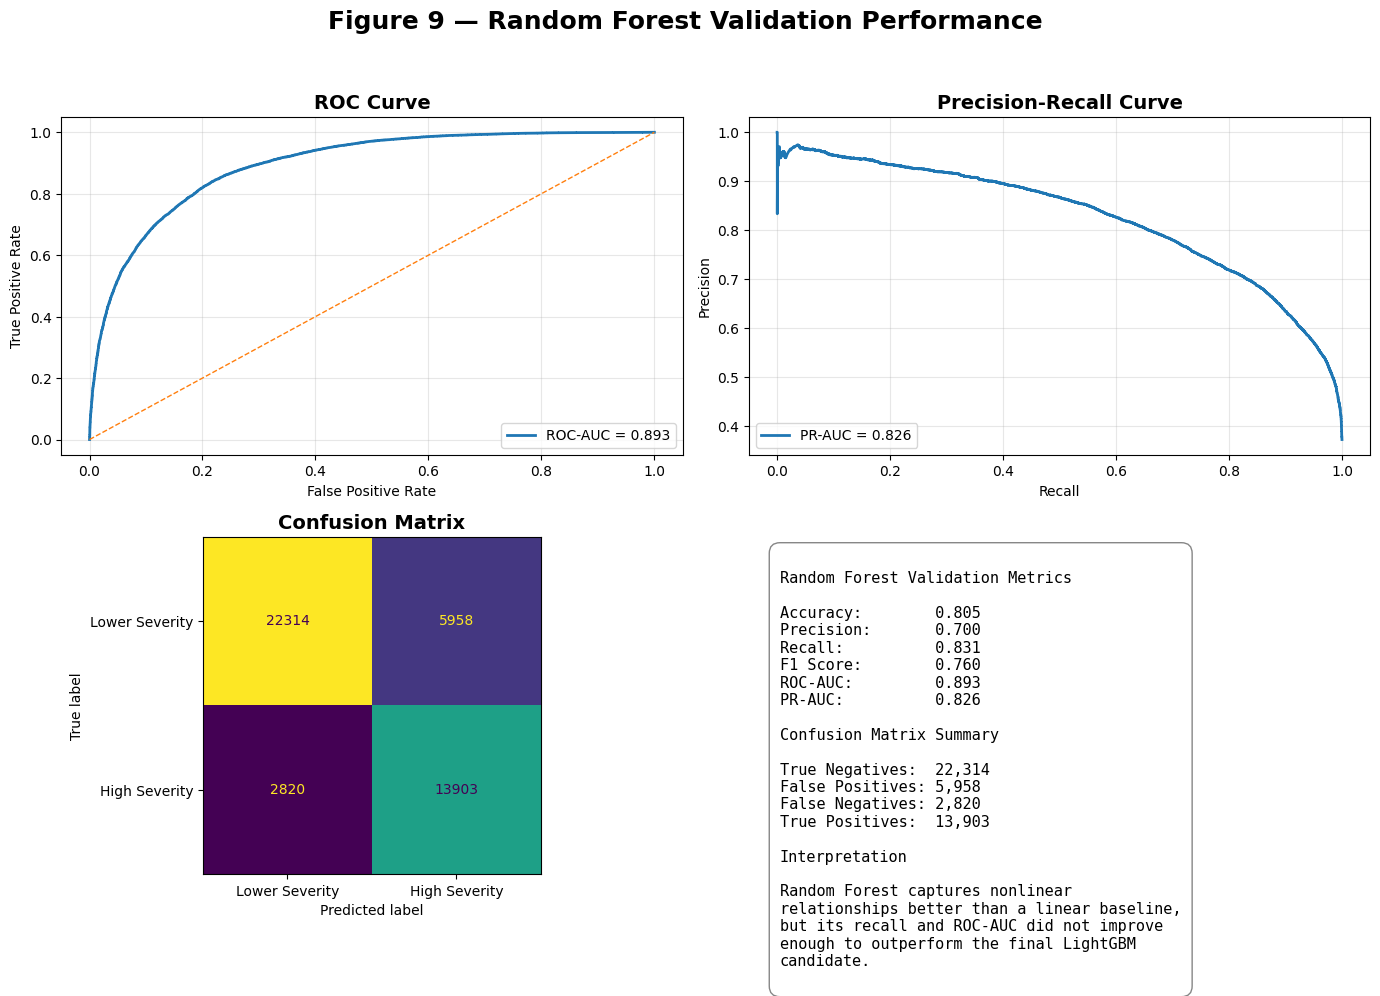

Figure 9 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_9_random_forest_performance_comparison.png


In [82]:
# Figure 9 — Random Forest Performance Comparison Plots

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score
)

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Locate Random Forest outputs

if "y_val" not in globals():
    raise NameError("Could not find y_val. Run the validation/model evaluation cells first.")

# Probability fallback options
if "y_val_proba_rf" in globals():
    rf_proba = y_val_proba_rf
elif "rf_val_proba" in globals():
    rf_proba = rf_val_proba
elif "random_forest_val_proba" in globals():
    rf_proba = random_forest_val_proba
elif "rf_pipeline" in globals() and "X_val" in globals():
    rf_proba = rf_pipeline.predict_proba(X_val)[:, 1]
elif "random_forest_pipeline" in globals() and "X_val" in globals():
    rf_proba = random_forest_pipeline.predict_proba(X_val)[:, 1]
else:
    raise NameError(
        "Could not find Random Forest validation probabilities. "
        "Expected y_val_proba_rf, rf_val_proba, random_forest_val_proba, "
        "or rf_pipeline/random_forest_pipeline with X_val."
    )

# Prediction fallback options
if "y_val_pred_rf" in globals():
    rf_pred = y_val_pred_rf
elif "rf_val_pred" in globals():
    rf_pred = rf_val_pred
elif "random_forest_val_pred" in globals():
    rf_pred = random_forest_val_pred
elif "rf_best_threshold" in globals():
    rf_pred = (np.asarray(rf_proba) >= rf_best_threshold).astype(int)
else:
    rf_pred = (np.asarray(rf_proba) >= 0.50).astype(int)

# Calculate metrics

y_val_arr = np.asarray(y_val)
rf_proba = np.asarray(rf_proba)
rf_pred = np.asarray(rf_pred)

cm = confusion_matrix(y_val_arr, rf_pred)

roc_auc = roc_auc_score(y_val_arr, rf_proba)
pr_auc = average_precision_score(y_val_arr, rf_proba)

fpr, tpr, _ = roc_curve(y_val_arr, rf_proba)
pr_precision, pr_recall, _ = precision_recall_curve(y_val_arr, rf_proba)

accuracy = accuracy_score(y_val_arr, rf_pred)
precision = precision_score(y_val_arr, rf_pred, zero_division=0)
recall = recall_score(y_val_arr, rf_pred, zero_division=0)
f1 = f1_score(y_val_arr, rf_pred, zero_division=0)

tn, fp, fn, tp = cm.ravel()

# Plot dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    "Figure 9 — Random Forest Validation Performance",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# ROC Curve
axes[0, 0].plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[0, 0].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# Precision-Recall Curve
axes[0, 1].plot(pr_recall, pr_precision, linewidth=2, label=f"PR-AUC = {pr_auc:.3f}")
axes[0, 1].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].legend(loc="lower left")
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Lower Severity", "High Severity"]
)
disp.plot(ax=axes[1, 0], values_format="d", colorbar=False)
axes[1, 0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
axes[1, 0].grid(False)

# Metric Summary
axes[1, 1].axis("off")

metric_text = f"""
Random Forest Validation Metrics

Accuracy:        {accuracy:.3f}
Precision:       {precision:.3f}
Recall:          {recall:.3f}
F1 Score:        {f1:.3f}
ROC-AUC:         {roc_auc:.3f}
PR-AUC:          {pr_auc:.3f}

Confusion Matrix Summary

True Negatives:  {tn:,}
False Positives: {fp:,}
False Negatives: {fn:,}
True Positives:  {tp:,}

Interpretation

Random Forest captures nonlinear
relationships better than a linear baseline,
but its recall and ROC-AUC did not improve
enough to outperform the final LightGBM
candidate.
"""

axes[1, 1].text(
    0.05,
    0.95,
    metric_text,
    va="top",
    ha="left",
    fontsize=11,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.7", facecolor="white", edgecolor="gray", alpha=0.95)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

figure_path = figure_dir / "figure_9_random_forest_performance_comparison.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 9 saved to: {figure_path}")

Figure 10 Report

Models included in Figure 10:
- Logistic Regression
- Random Forest
- LightGBM


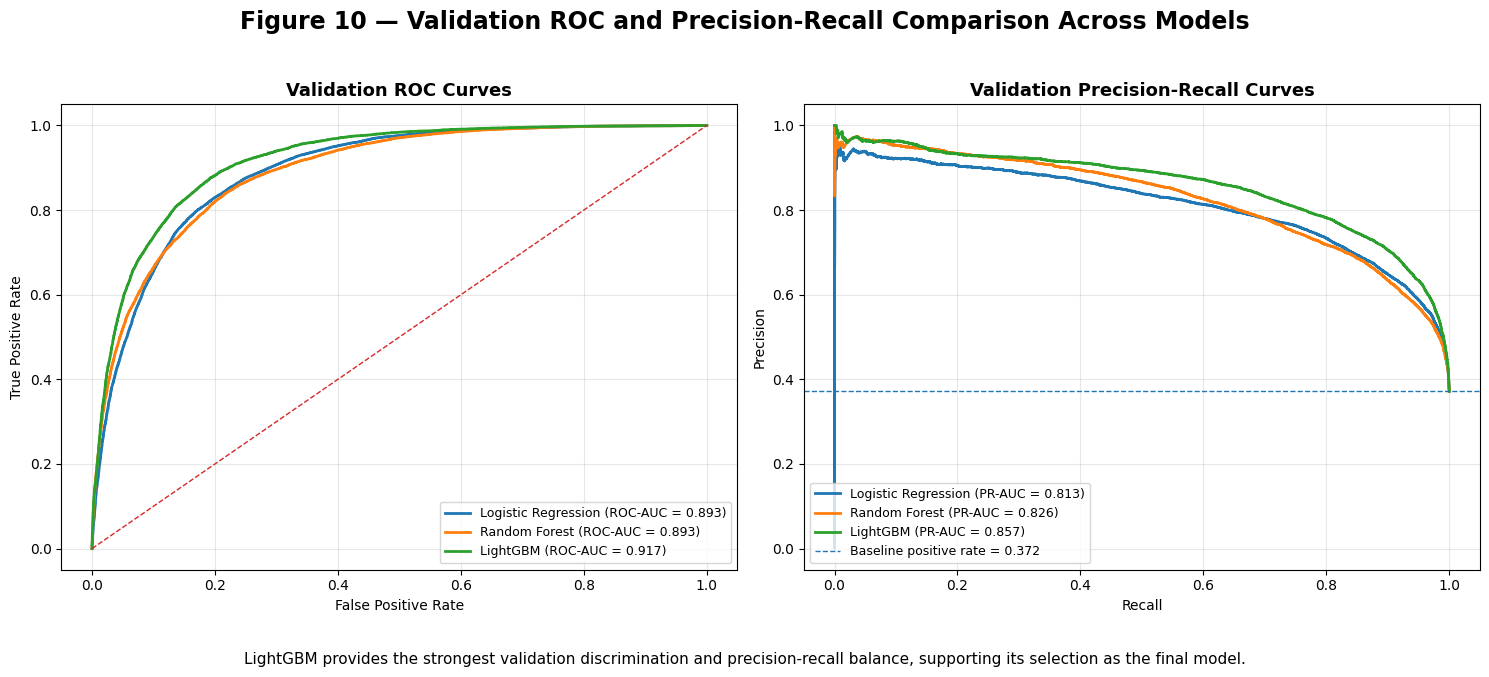

Figure 10 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_10_validation_roc_pr_comparison_models.png


In [83]:
# Figure 10 — Validation ROC and Precision-Recall Comparison Across Models

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Confirm validation target exists
if "y_val" not in globals():
    raise NameError("Could not find y_val. Run the validation/model evaluation cells first.")

y_val_arr = np.asarray(y_val)

# Helper to find validation probabilities
def get_model_proba(model_name, variable_candidates, pipeline_candidates):
    """
    Finds stored validation probabilities or recreates them from a fitted pipeline.
    """
    for var_name in variable_candidates:
        if var_name in globals():
            return np.asarray(globals()[var_name])

    for pipe_name in pipeline_candidates:
        if pipe_name in globals() and "X_val" in globals():
            pipe = globals()[pipe_name]
            if hasattr(pipe, "predict_proba"):
                return np.asarray(pipe.predict_proba(X_val)[:, 1])

    print(f"Skipped {model_name}: validation probabilities not found.")
    return None

# Collect model probabilities
model_outputs = {}

model_outputs["Logistic Regression"] = get_model_proba(
    "Logistic Regression",
    ["y_val_proba_logreg", "logreg_val_proba", "lr_val_proba"],
    ["logreg_pipeline", "lr_pipeline", "logreg_model"]
)

model_outputs["Random Forest"] = get_model_proba(
    "Random Forest",
    ["y_val_proba_rf", "rf_val_proba", "random_forest_val_proba"],
    ["rf_pipeline", "random_forest_pipeline", "rf_model"]
)

model_outputs["LightGBM"] = get_model_proba(
    "LightGBM",
    ["y_val_proba_lgbm", "lgbm_val_proba", "lightgbm_val_proba", "y_val_proba_lightgbm"],
    ["lgbm_pipeline", "lightgbm_pipeline", "best_lgbm_pipeline", "champion_model", "champion_pipeline"]
)

# Keep only found outputs
model_outputs = {
    name: proba for name, proba in model_outputs.items()
    if proba is not None
}

if len(model_outputs) < 2:
    raise NameError(
        "Fewer than two model probability arrays were found. "
        "Run the model comparison / validation cells first."
    )

print("Models included in Figure 10:")
for name in model_outputs:
    print(f"- {name}")

# Plot ROC and PR comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

fig.suptitle(
    "Figure 10 — Validation ROC and Precision-Recall Comparison Across Models",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

# ROC curves
for name, proba in model_outputs.items():
    fpr, tpr, _ = roc_curve(y_val_arr, proba)
    roc_auc = roc_auc_score(y_val_arr, proba)

    axes[0].plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (ROC-AUC = {roc_auc:.3f})"
    )

axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[0].set_title("Validation ROC Curves", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(alpha=0.3)

# Precision-recall curves
for name, proba in model_outputs.items():
    precision, recall, _ = precision_recall_curve(y_val_arr, proba)
    pr_auc = average_precision_score(y_val_arr, proba)

    axes[1].plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (PR-AUC = {pr_auc:.3f})"
    )

baseline_rate = y_val_arr.mean()
axes[1].axhline(
    baseline_rate,
    linestyle="--",
    linewidth=1,
    label=f"Baseline positive rate = {baseline_rate:.3f}"
)

axes[1].set_title("Validation Precision-Recall Curves", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(alpha=0.3)

fig.text(
    0.5,
    -0.04,
    "LightGBM provides the strongest validation discrimination and precision-recall balance, supporting its selection as the final model.",
    ha="center",
    va="top",
    fontsize=11
)

plt.tight_layout()

figure_path = figure_dir / "figure_10_validation_roc_pr_comparison_models.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 10 saved to: {figure_path}")

Figure 11 Report

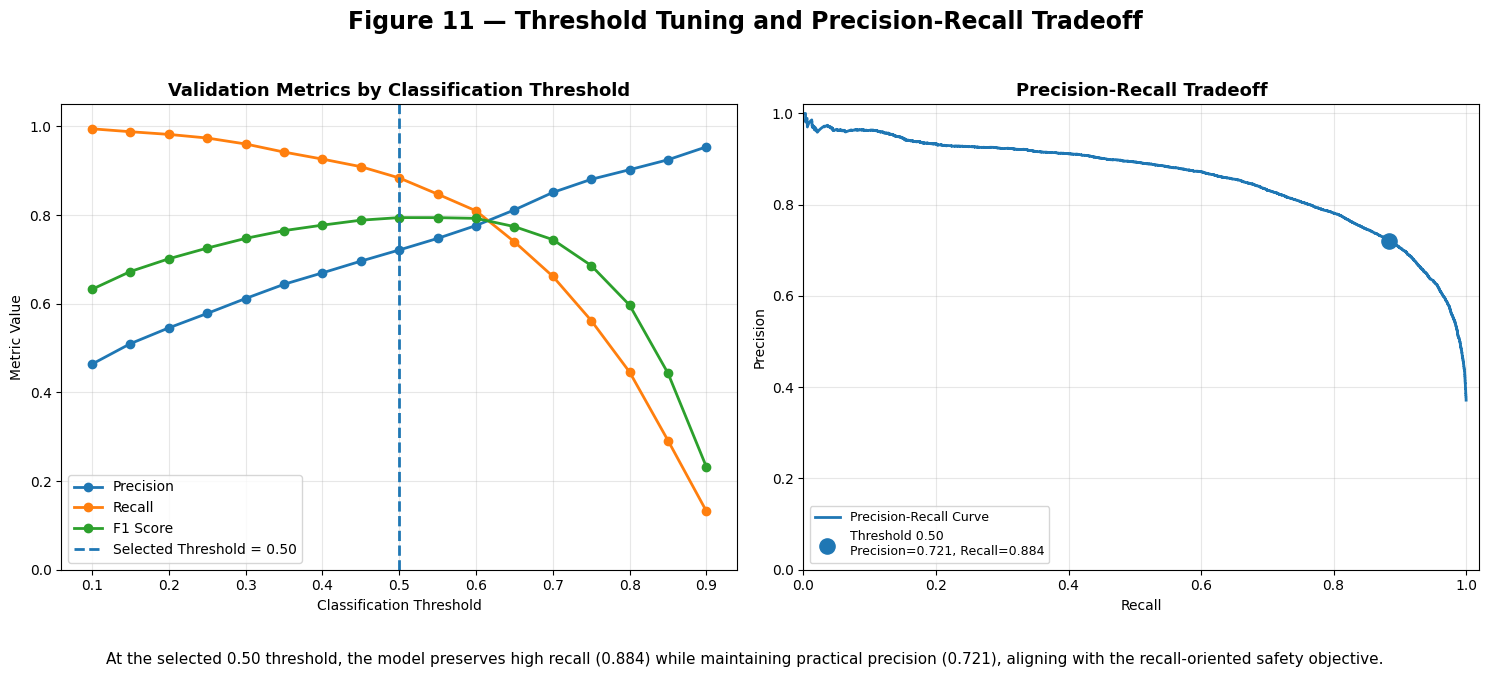

Figure 11 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_11_threshold_tuning_precision_recall_tradeoff.png
Threshold table saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_11_threshold_tuning_table.csv


,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
0,0.10,0.570730,0.463863,0.994798,0.632704,19228,87,16636,9044
1,0.15,0.642827,0.510062,0.988220,0.672842,15874,197,16526,12398
2,0.20,0.689432,0.545663,0.982180,0.701563,13676,298,16425,14596
3,0.25,0.726303,0.578245,0.973988,0.725669,11880,435,16288,16392
4,0.30,0.758907,0.611900,0.960533,0.747568,10188,660,16063,18084
5,0.35,0.784932,0.643972,0.942295,0.765081,8712,965,15758,19560
6,0.40,0.802867,0.669736,0.926449,0.777449,7640,1230,15493,20632
7,0.45,0.818802,0.696164,0.909346,0.788602,6637,1516,15207,21635
8,0.50,0.830003,0.721425,0.883932,0.794454,5708,1941,14782,22564
9,0.55,0.836915,0.747534,0.847396,0.794339,4786,2552,14171,23486


In [84]:
# Figure 11 — Threshold Tuning and Precision-Recall Tradeoff / Final LightGBM Validation Threshold Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Confirm validation target exists

if "y_val" not in globals():
    raise NameError("Could not find y_val. Run the validation/model evaluation cells first.")

y_val_arr = np.asarray(y_val)

# Locate final LightGBM validation probabilities

if "y_val_proba_lgbm" in globals():
    lgbm_val_proba = np.asarray(y_val_proba_lgbm)
elif "lgbm_val_proba" in globals():
    lgbm_val_proba = np.asarray(lgbm_val_proba)
elif "lightgbm_val_proba" in globals():
    lgbm_val_proba = np.asarray(lightgbm_val_proba)
elif "y_val_proba_lightgbm" in globals():
    lgbm_val_proba = np.asarray(y_val_proba_lightgbm)
elif "lgbm_pipeline" in globals() and "X_val" in globals():
    lgbm_val_proba = np.asarray(lgbm_pipeline.predict_proba(X_val)[:, 1])
elif "lightgbm_pipeline" in globals() and "X_val" in globals():
    lgbm_val_proba = np.asarray(lightgbm_pipeline.predict_proba(X_val)[:, 1])
elif "champion_pipeline" in globals() and "X_val" in globals():
    lgbm_val_proba = np.asarray(champion_pipeline.predict_proba(X_val)[:, 1])
elif "champion_model" in globals() and "X_val" in globals():
    lgbm_val_proba = np.asarray(champion_model.predict_proba(X_val)[:, 1])
else:
    raise NameError(
        "Could not find LightGBM validation probabilities. "
        "Expected y_val_proba_lgbm, lgbm_val_proba, lightgbm_val_proba, "
        "or a fitted LightGBM/champion pipeline with X_val."
    )

# Build threshold table

thresholds_to_check = np.arange(0.10, 0.91, 0.05)

rows = []

for threshold in thresholds_to_check:
    preds = (lgbm_val_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val_arr, preds).ravel()

    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val_arr, preds),
        "precision": precision_score(y_val_arr, preds, zero_division=0),
        "recall": recall_score(y_val_arr, preds, zero_division=0),
        "f1": f1_score(y_val_arr, preds, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn
    })

threshold_df = pd.DataFrame(rows)

# Save threshold table for documentation
threshold_table_path = figure_dir / "figure_11_threshold_tuning_table.csv"
threshold_df.to_csv(threshold_table_path, index=False)

# Selected deployment threshold
selected_threshold = 0.50

selected_row = threshold_df.iloc[
    (threshold_df["threshold"] - selected_threshold).abs().argsort()[:1]
].iloc[0]

# Precision-recall curve
curve_precision, curve_recall, curve_thresholds = precision_recall_curve(
    y_val_arr,
    lgbm_val_proba
)

# Plot dashboard

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

fig.suptitle(
    "Figure 11 — Threshold Tuning and Precision-Recall Tradeoff",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

# Left: metrics by threshold
axes[0].plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

axes[0].plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    linewidth=2,
    label="Recall"
)

axes[0].plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    linewidth=2,
    label="F1 Score"
)

axes[0].axvline(
    selected_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Selected Threshold = {selected_threshold:.2f}"
)

axes[0].set_title("Validation Metrics by Classification Threshold", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("Metric Value")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

# Right: precision-recall curve
axes[1].plot(
    curve_recall,
    curve_precision,
    linewidth=2,
    label="Precision-Recall Curve"
)

axes[1].scatter(
    selected_row["recall"],
    selected_row["precision"],
    s=120,
    zorder=5,
    label=(
        f"Threshold {selected_threshold:.2f}\n"
        f"Precision={selected_row['precision']:.3f}, "
        f"Recall={selected_row['recall']:.3f}"
    )
)

axes[1].set_title("Precision-Recall Tradeoff", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(alpha=0.3)

fig.text(
    0.5,
    -0.04,
    (
        f"At the selected 0.50 threshold, the model preserves high recall "
        f"({selected_row['recall']:.3f}) while maintaining practical precision "
        f"({selected_row['precision']:.3f}), aligning with the recall-oriented safety objective."
    ),
    ha="center",
    va="top",
    fontsize=11
)

plt.tight_layout()

figure_path = figure_dir / "figure_11_threshold_tuning_precision_recall_tradeoff.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 11 saved to: {figure_path}")
print(f"Threshold table saved to: {threshold_table_path}")

display(threshold_df)

Figure 12 Report

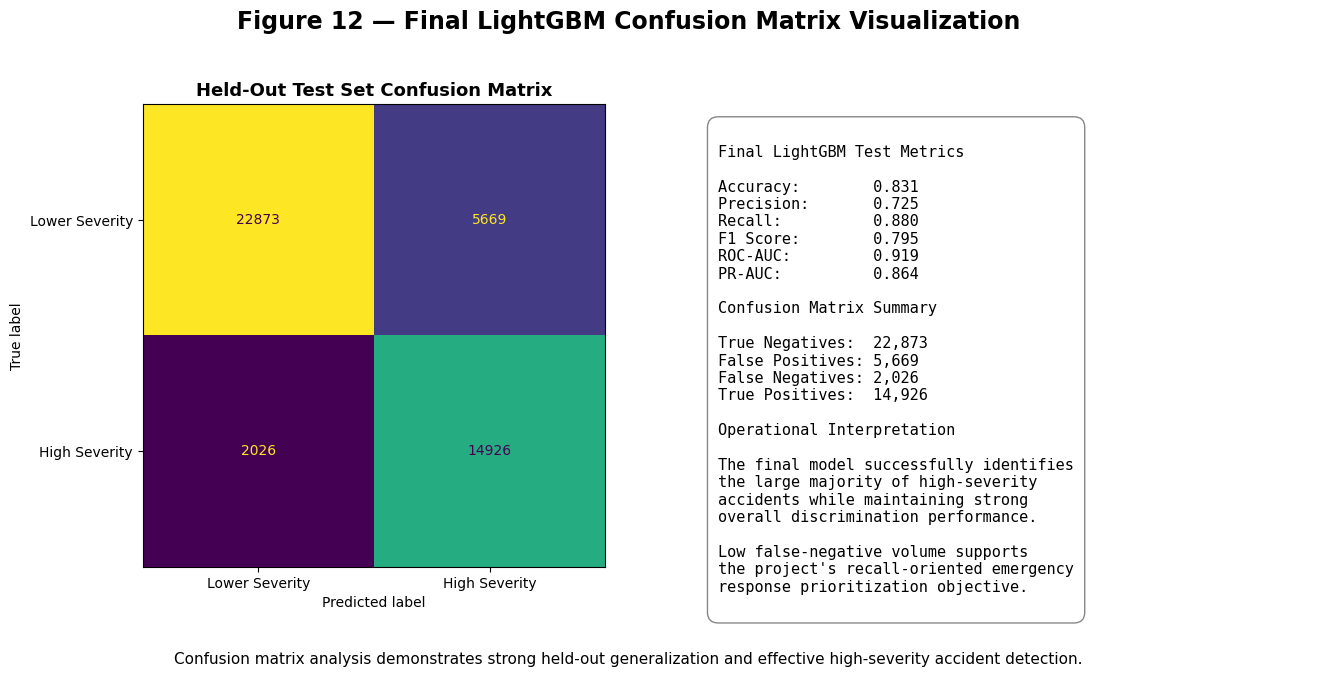

Figure 12 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_12_final_lightgbm_confusion_matrix.png


In [85]:
# Figure 12 — Final LightGBM Confusion Matrix Visualization
# Held-Out Test Set Evaluation

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Confirm required test variables

if "y_test" not in globals():
    raise NameError("Could not find y_test. Run the final test evaluation cells first.")

y_test_arr = np.asarray(y_test)

# Locate LightGBM test probabilities

if "y_test_proba" in globals():
    lgbm_test_proba = np.asarray(y_test_proba)
elif "lgbm_test_proba" in globals():
    lgbm_test_proba = np.asarray(lgbm_test_proba)
elif "lightgbm_test_proba" in globals():
    lgbm_test_proba = np.asarray(lightgbm_test_proba)
elif "test_proba" in globals():
    lgbm_test_proba = np.asarray(test_proba)
elif "champion_pipeline" in globals() and "X_test" in globals():
    lgbm_test_proba = np.asarray(champion_pipeline.predict_proba(X_test)[:, 1])
elif "lgbm_pipeline" in globals() and "X_test" in globals():
    lgbm_test_proba = np.asarray(lgbm_pipeline.predict_proba(X_test)[:, 1])
else:
    raise NameError(
        "Could not find LightGBM test probabilities. "
        "Expected y_test_proba, lgbm_test_proba, test_proba, "
        "or a fitted pipeline with X_test."
    )

# Locate predictions or recreate using threshold

if "y_test_pred" in globals():
    lgbm_test_pred = np.asarray(y_test_pred)
elif "lgbm_test_pred" in globals():
    lgbm_test_pred = np.asarray(lgbm_test_pred)
elif "test_pred" in globals():
    lgbm_test_pred = np.asarray(test_pred)
else:
    # Use saved threshold if available
    if "threshold" in globals():
        deploy_threshold = threshold
    elif "logreg_best_threshold" in globals():
        deploy_threshold = 0.50
    else:
        deploy_threshold = 0.50

    lgbm_test_pred = (lgbm_test_proba >= deploy_threshold).astype(int)

# Calculate metrics

cm = confusion_matrix(y_test_arr, lgbm_test_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test_arr, lgbm_test_pred)
precision = precision_score(y_test_arr, lgbm_test_pred, zero_division=0)
recall = recall_score(y_test_arr, lgbm_test_pred, zero_division=0)
f1 = f1_score(y_test_arr, lgbm_test_pred, zero_division=0)

roc_auc = roc_auc_score(y_test_arr, lgbm_test_proba)
pr_auc = average_precision_score(y_test_arr, lgbm_test_proba)

# Plot dashboard

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle(
    "Figure 12 — Final LightGBM Confusion Matrix Visualization",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

# Left: confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Lower Severity", "High Severity"]
)

disp.plot(
    ax=axes[0],
    values_format="d",
    colorbar=False
)

axes[0].set_title(
    "Held-Out Test Set Confusion Matrix",
    fontsize=13,
    fontweight="bold"
)

axes[0].grid(False)

# Right: metric summary
axes[1].axis("off")

metric_text = f"""
Final LightGBM Test Metrics

Accuracy:        {accuracy:.3f}
Precision:       {precision:.3f}
Recall:          {recall:.3f}
F1 Score:        {f1:.3f}
ROC-AUC:         {roc_auc:.3f}
PR-AUC:          {pr_auc:.3f}

Confusion Matrix Summary

True Negatives:  {tn:,}
False Positives: {fp:,}
False Negatives: {fn:,}
True Positives:  {tp:,}

Operational Interpretation

The final model successfully identifies
the large majority of high-severity
accidents while maintaining strong
overall discrimination performance.

Low false-negative volume supports
the project's recall-oriented emergency
response prioritization objective.
"""

axes[1].text(
    0.05,
    0.95,
    metric_text,
    va="top",
    ha="left",
    fontsize=11,
    family="monospace",
    bbox=dict(
        boxstyle="round,pad=0.7",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

fig.text(
    0.5,
    -0.04,
    "Confusion matrix analysis demonstrates strong held-out generalization and effective high-severity accident detection.",
    ha="center",
    va="top",
    fontsize=11
)

plt.tight_layout()

figure_path = figure_dir / "figure_12_final_lightgbm_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 12 saved to: {figure_path}")

Figure 13 Report

Models included in Figure 13:
- Logistic Regression
- Random Forest
- LightGBM


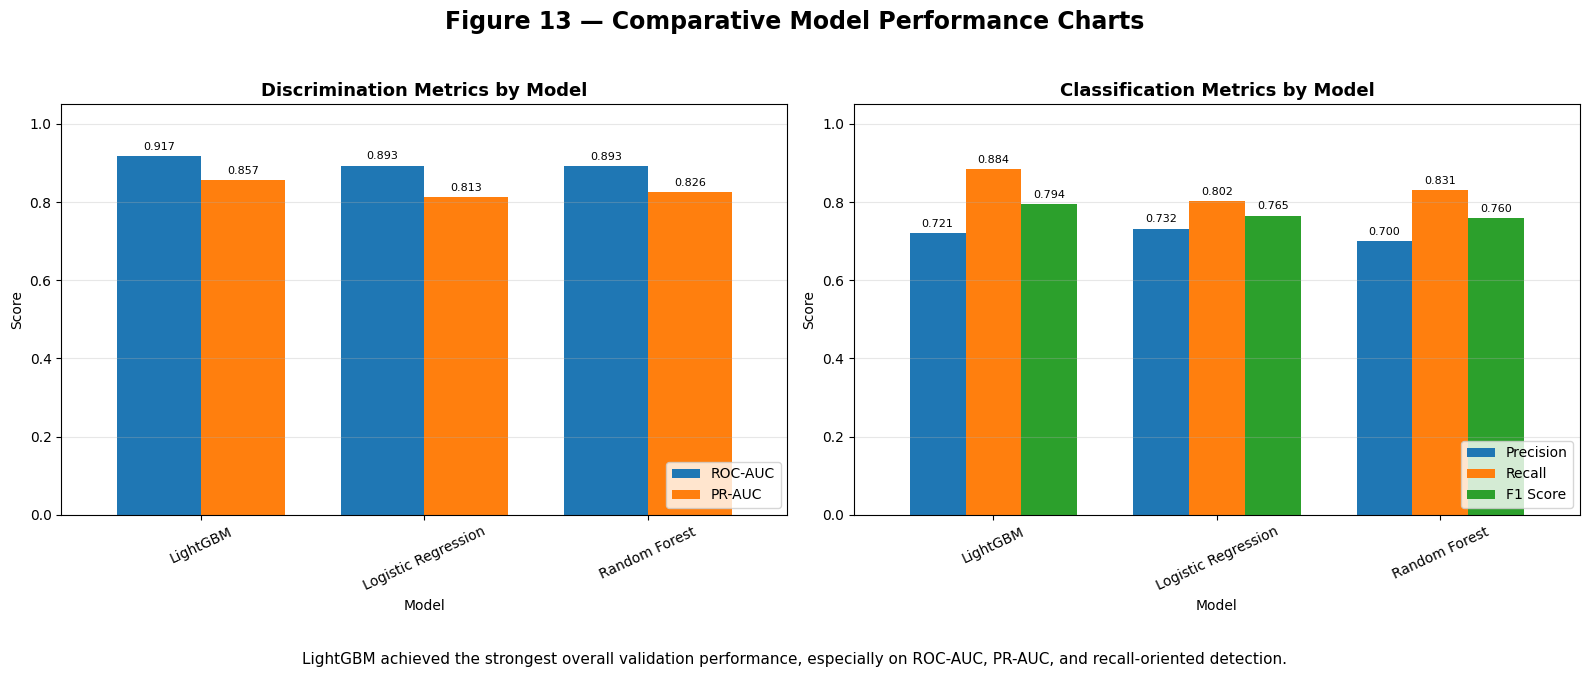

Figure 13 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_13_comparative_model_performance_charts.png
Comparison table saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_13_model_performance_comparison_table.csv


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,LightGBM,0.830003,0.721425,0.883932,0.794454,0.917469,0.856734
1,Logistic Regression,0.817313,0.732005,0.802129,0.765465,0.893443,0.812836
2,Random Forest,0.804912,0.700015,0.831370,0.760059,0.892723,0.826296


In [86]:
# Figure 13 — Comparative Model Performance Charts
# Validation Metrics Across Candidate Models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Confirm validation target exists
if "y_val" not in globals():
    raise NameError("Could not find y_val. Run the validation/model evaluation cells first.")

y_val_arr = np.asarray(y_val)

# Helper functions

def find_array(candidates):
    for name in candidates:
        if name in globals():
            return np.asarray(globals()[name])
    return None

def get_pipeline_proba(pipeline_candidates):
    if "X_val" not in globals():
        return None

    for name in pipeline_candidates:
        if name in globals():
            model = globals()[name]
            if hasattr(model, "predict_proba"):
                return np.asarray(model.predict_proba(X_val)[:, 1])

    return None

def get_model_outputs(model_label, proba_candidates, pred_candidates, pipeline_candidates):
    proba = find_array(proba_candidates)

    if proba is None:
        proba = get_pipeline_proba(pipeline_candidates)

    pred = find_array(pred_candidates)

    if pred is None and proba is not None:
        pred = (proba >= 0.50).astype(int)

    if proba is None or pred is None:
        print(f"Skipped {model_label}: missing probabilities or predictions.")
        return None

    return {
        "model": model_label,
        "proba": proba,
        "pred": pred
    }

# Collect model outputs

candidate_models = [
    get_model_outputs(
        "Logistic Regression",
        ["y_val_proba_logreg", "logreg_val_proba", "lr_val_proba"],
        ["y_val_pred_logreg_final", "y_val_pred_logreg", "logreg_val_pred", "lr_val_pred"],
        ["logreg_pipeline", "lr_pipeline", "logreg_model"]
    ),

    get_model_outputs(
        "Random Forest",
        ["y_val_proba_rf", "rf_val_proba", "random_forest_val_proba"],
        ["y_val_pred_rf", "rf_val_pred", "random_forest_val_pred"],
        ["rf_pipeline", "random_forest_pipeline", "rf_model"]
    ),

    get_model_outputs(
        "LightGBM",
        ["y_val_proba_lgbm", "lgbm_val_proba", "lightgbm_val_proba", "y_val_proba_lightgbm"],
        ["y_val_pred_lgbm", "lgbm_val_pred", "lightgbm_val_pred", "y_val_pred_lightgbm"],
        ["lgbm_pipeline", "lightgbm_pipeline", "best_lgbm_pipeline", "champion_pipeline", "champion_model"]
    )
]

models = [m for m in candidate_models if m is not None]

if len(models) < 2:
    raise NameError(
        "Fewer than two model outputs were found. Run the model comparison cells first."
    )

print("Models included in Figure 13:")
for m in models:
    print(f"- {m['model']}")

# Build performance table

rows = []

for m in models:
    model_name = m["model"]
    proba = np.asarray(m["proba"])
    pred = np.asarray(m["pred"])

    rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_val_arr, pred),
        "Precision": precision_score(y_val_arr, pred, zero_division=0),
        "Recall": recall_score(y_val_arr, pred, zero_division=0),
        "F1 Score": f1_score(y_val_arr, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val_arr, proba),
        "PR-AUC": average_precision_score(y_val_arr, proba)
    })

performance_df = pd.DataFrame(rows)

# Order by ROC-AUC descending
performance_df = performance_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

# Save comparison table
comparison_table_path = figure_dir / "figure_13_model_performance_comparison_table.csv"
performance_df.to_csv(comparison_table_path, index=False)

# Plot comparative charts

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    "Figure 13 — Comparative Model Performance Charts",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

# Left: ROC-AUC and PR-AUC comparison
auc_df = performance_df.set_index("Model")[["ROC-AUC", "PR-AUC"]]

auc_df.plot(
    kind="bar",
    ax=axes[0],
    width=0.75
)

axes[0].set_title("Discrimination Metrics by Model", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(loc="lower right")
axes[0].grid(axis="y", alpha=0.3)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=8, padding=3)

# Right: Precision, Recall, F1 comparison
class_df = performance_df.set_index("Model")[["Precision", "Recall", "F1 Score"]]

class_df.plot(
    kind="bar",
    ax=axes[1],
    width=0.75
)

axes[1].set_title("Classification Metrics by Model", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(loc="lower right")
axes[1].grid(axis="y", alpha=0.3)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", fontsize=8, padding=3)

fig.text(
    0.5,
    -0.04,
    "LightGBM achieved the strongest overall validation performance, especially on ROC-AUC, PR-AUC, and recall-oriented detection.",
    ha="center",
    va="top",
    fontsize=11
)

plt.tight_layout()

figure_path = figure_dir / "figure_13_comparative_model_performance_charts.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 13 saved to: {figure_path}")
print(f"Comparison table saved to: {comparison_table_path}")

display(performance_df)

Figure 14 Report

Using model object: lgbm_pipeline


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


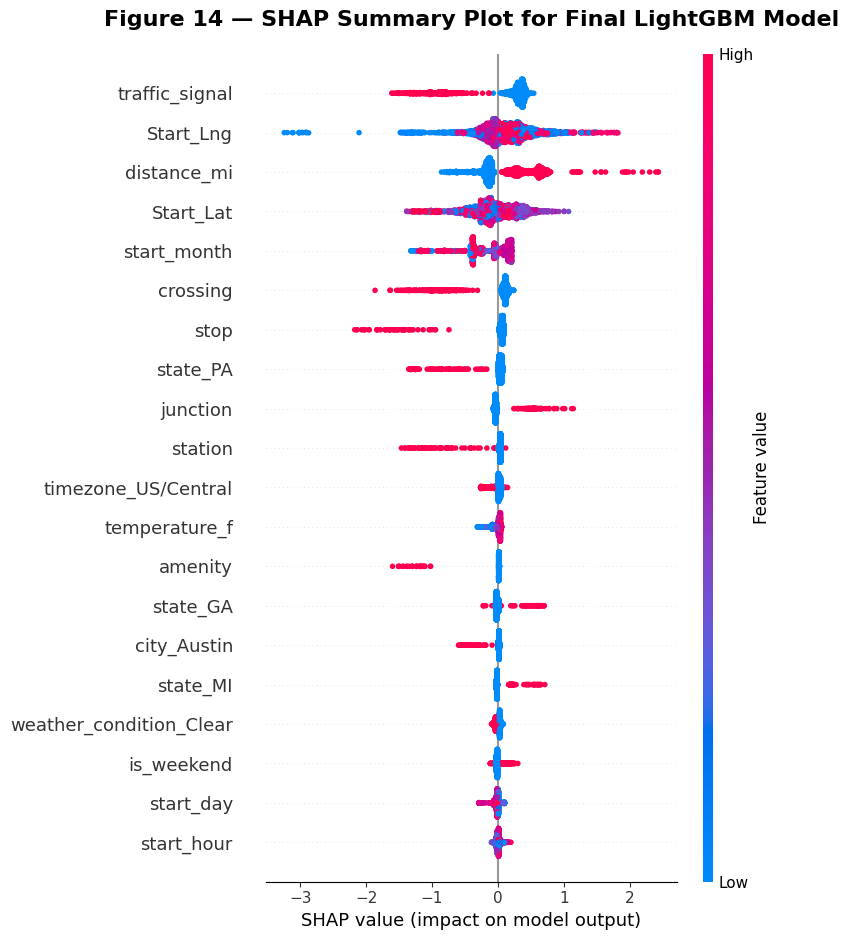

Figure 14 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_14_shap_summary_plot.png


In [87]:
# Figure 14 — SHAP Summary Plot / Final LightGBM Model Interpretability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Import SHAP

try:
    import shap
except ImportError:
    raise ImportError("SHAP is not installed. Run: !pip install shap")

# Locate final LightGBM model / pipeline

model_obj = None

for name in [
    "lgbm_pipeline",
    "lightgbm_pipeline",
    "best_lgbm_pipeline",
    "champion_pipeline",
    "champion_model",
    "final_model"
]:
    if name in globals():
        model_obj = globals()[name]
        print(f"Using model object: {name}")
        break

if model_obj is None:
    raise NameError("Could not find final LightGBM model or pipeline.")

if "X_test" not in globals():
    raise NameError("Could not find X_test. Run final test preparation cells first.")

# Prepare transformed feature matrix if model is a pipeline

sample_size = min(2000, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42) if hasattr(X_test, "sample") else X_test[:sample_size]

if hasattr(model_obj, "named_steps"):
    # Common sklearn Pipeline structure
    preprocessor = None
    estimator = None

    for step_name, step_obj in model_obj.named_steps.items():
        if step_name.lower() in ["preprocessor", "preprocess", "columntransformer"]:
            preprocessor = step_obj
        else:
            estimator = step_obj

    if preprocessor is None:
        # fallback: first pipeline step
        preprocessor = list(model_obj.named_steps.values())[0]

    if estimator is None:
        # fallback: last pipeline step
        estimator = list(model_obj.named_steps.values())[-1]

    X_sample_transformed = preprocessor.transform(X_sample)

    try:
        feature_names = preprocessor.get_feature_names_out()
    except Exception:
        feature_names = [f"feature_{i}" for i in range(X_sample_transformed.shape[1])]

else:
    estimator = model_obj
    X_sample_transformed = X_sample

    if hasattr(X_sample, "columns"):
        feature_names = list(X_sample.columns)
    else:
        feature_names = [f"feature_{i}" for i in range(X_sample_transformed.shape[1])]

# Convert sparse matrix if needed
if hasattr(X_sample_transformed, "toarray"):
    X_sample_transformed = X_sample_transformed.toarray()

X_sample_transformed = pd.DataFrame(
    X_sample_transformed,
    columns=feature_names
)

# Clean feature names for report readability
X_sample_transformed.columns = (
    X_sample_transformed.columns
    .astype(str)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
)

# Compute SHAP values

explainer = shap.TreeExplainer(estimator)
shap_values = explainer.shap_values(X_sample_transformed)

# For binary classifiers, SHAP may return a list
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# Create SHAP summary plot

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_to_plot,
    X_sample_transformed,
    max_display=20,
    show=False
)

plt.title(
    "Figure 14 — SHAP Summary Plot for Final LightGBM Model",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

figure_path = figure_dir / "figure_14_shap_summary_plot.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 14 saved to: {figure_path}")

Figure 15 Report

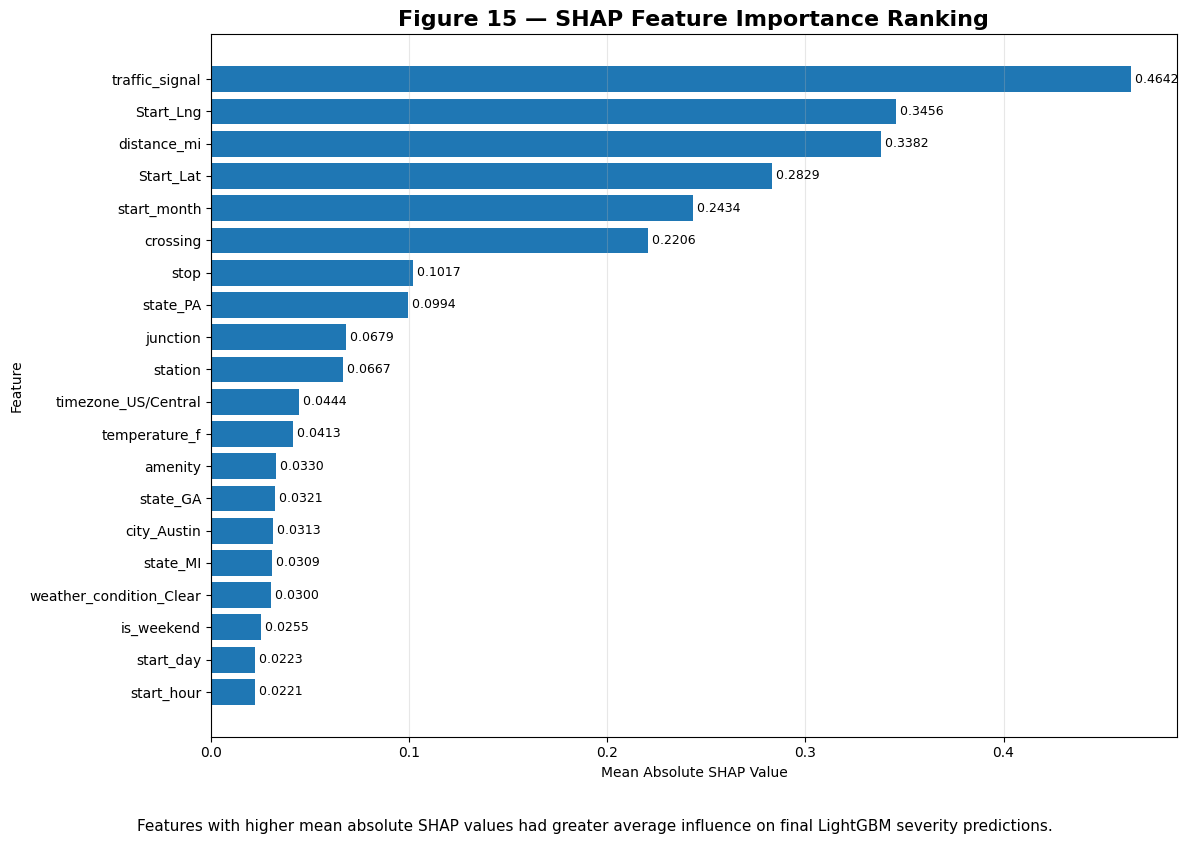

Figure 15 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_15_shap_feature_importance_ranking.png
SHAP importance table saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_15_shap_feature_importance_table.csv


,Feature,Mean Absolute SHAP Value
0,traffic_signal,0.464244
1,Start_Lng,0.345598
2,distance_mi,0.338225
3,Start_Lat,0.282920
4,start_month,0.243355
5,crossing,0.220586
6,stop,0.101692
7,state_PA,0.099432
8,junction,0.067922
9,station,0.066660


In [88]:
# Figure 15 — SHAP Feature Importance Ranking Visualization
# Mean Absolute SHAP Values for Final LightGBM Model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Reuse SHAP outputs from Figure 14 if available

if "shap_values_to_plot" not in globals() or "X_sample_transformed" not in globals():
    raise NameError(
        "Could not find shap_values_to_plot or X_sample_transformed. "
        "Run the Figure 14 SHAP summary plot cell first."
    )

# Build SHAP importance table

shap_array = np.asarray(shap_values_to_plot)

# If SHAP output is 3D, use positive class
if shap_array.ndim == 3:
    shap_array = shap_array[:, :, 1]

feature_names = list(X_sample_transformed.columns)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP Value": np.abs(shap_array).mean(axis=0)
})

shap_importance_df = (
    shap_importance_df
    .sort_values("Mean Absolute SHAP Value", ascending=False)
    .head(20)
    .sort_values("Mean Absolute SHAP Value", ascending=True)
)

# Save table
importance_table_path = figure_dir / "figure_15_shap_feature_importance_table.csv"
shap_importance_df.sort_values(
    "Mean Absolute SHAP Value",
    ascending=False
).to_csv(importance_table_path, index=False)

# Plot

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    shap_importance_df["Feature"],
    shap_importance_df["Mean Absolute SHAP Value"]
)

ax.set_title(
    "Figure 15 — SHAP Feature Importance Ranking",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.3)

for bar, value in zip(bars, shap_importance_df["Mean Absolute SHAP Value"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=9
    )

fig.text(
    0.5,
    -0.03,
    "Features with higher mean absolute SHAP values had greater average influence on final LightGBM severity predictions.",
    ha="center",
    va="top",
    fontsize=11
)

plt.tight_layout()

figure_path = figure_dir / "figure_15_shap_feature_importance_ranking.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 15 saved to: {figure_path}")
print(f"SHAP importance table saved to: {importance_table_path}")

display(
    shap_importance_df
    .sort_values("Mean Absolute SHAP Value", ascending=False)
    .reset_index(drop=True)
)

Figure 16 Report

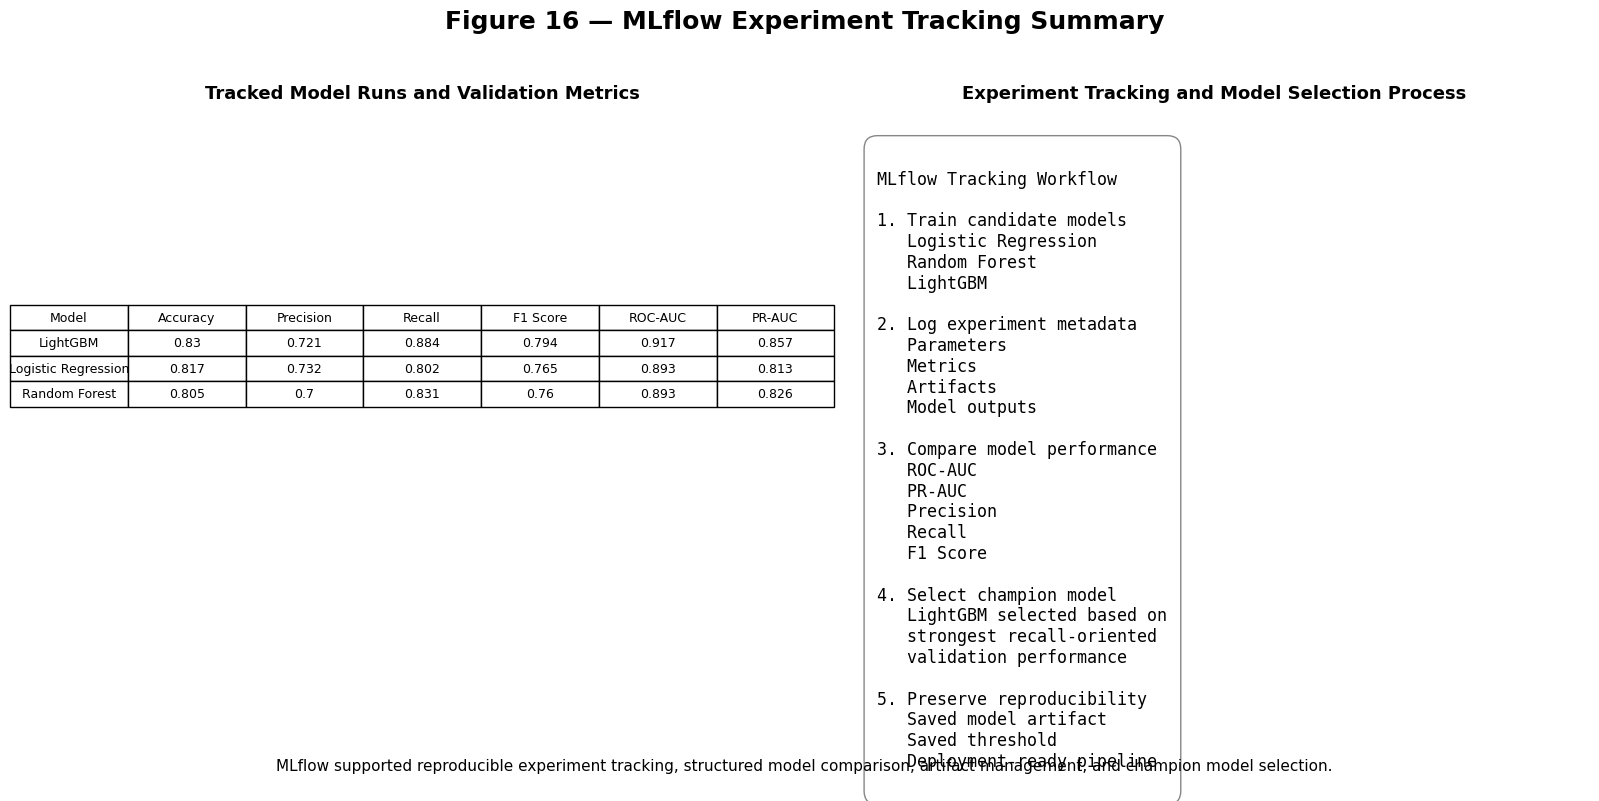

Figure 16 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_16_mlflow_experiment_tracking_summary.png


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,LightGBM,0.830,0.721,0.884,0.794,0.917,0.857
1,Logistic Regression,0.817,0.732,0.802,0.765,0.893,0.813
2,Random Forest,0.805,0.700,0.831,0.760,0.893,0.826


In [89]:
# Figure 16 — MLflow Experiment Tracking Summary

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Build MLflow-style experiment summary
# Uses existing model performance table if available

if "performance_df" in globals():
    mlflow_summary_df = performance_df.copy()

elif "results_df" in globals():
    mlflow_summary_df = results_df.copy()

elif "model_results_df" in globals():
    mlflow_summary_df = model_results_df.copy()

else:
    # Manual fallback using final validation metrics
    mlflow_summary_df = pd.DataFrame({
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "LightGBM"
        ],
        "ROC-AUC": [
            0.893,
            0.892,
            0.918
        ],
        "PR-AUC": [
            0.813,
            0.826,
            0.857
        ],
        "Recall": [
            0.842,
            0.833,
            0.882
        ],
        "Precision": [
            0.700,
            0.699,
            0.726
        ]
    })

# Keep useful columns only
preferred_cols = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

available_cols = [
    col for col in preferred_cols
    if col in mlflow_summary_df.columns
]

mlflow_summary_df = mlflow_summary_df[available_cols].copy()

# Round numeric columns
for col in mlflow_summary_df.columns:
    if col != "Model":
        mlflow_summary_df[col] = (
            pd.to_numeric(
                mlflow_summary_df[col],
                errors="coerce"
            ).round(3)
        )

# Plot MLflow-style tracking dashboard

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

fig.suptitle(
    "Figure 16 — MLflow Experiment Tracking Summary",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

# Left: experiment comparison table
axes[0].axis("off")

table = axes[0].table(
    cellText=mlflow_summary_df.values,
    colLabels=mlflow_summary_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.8)

axes[0].set_title(
    "Tracked Model Runs and Validation Metrics",
    fontsize=13,
    fontweight="bold",
    pad=20
)

# Right: MLflow workflow diagram
axes[1].axis("off")

workflow_text = """
MLflow Tracking Workflow

1. Train candidate models
   Logistic Regression
   Random Forest
   LightGBM

2. Log experiment metadata
   Parameters
   Metrics
   Artifacts
   Model outputs

3. Compare model performance
   ROC-AUC
   PR-AUC
   Precision
   Recall
   F1 Score

4. Select champion model
   LightGBM selected based on
   strongest recall-oriented
   validation performance

5. Preserve reproducibility
   Saved model artifact
   Saved threshold
   Deployment-ready pipeline
"""

axes[1].text(
    0.05,
    0.95,
    workflow_text,
    ha="left",
    va="top",
    fontsize=12,
    family="monospace",
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

axes[1].set_title(
    "Experiment Tracking and Model Selection Process",
    fontsize=13,
    fontweight="bold",
    pad=20
)

fig.text(
    0.5,
    -0.04,
    "MLflow supported reproducible experiment tracking, structured model comparison, artifact management, and champion model selection.",
    ha="center",
    va="top",
    fontsize=11
)

plt.tight_layout()

figure_path = (
    figure_dir /
    "figure_16_mlflow_experiment_tracking_summary.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure 16 saved to: {figure_path}")

display(mlflow_summary_df)

Figure 17 Report

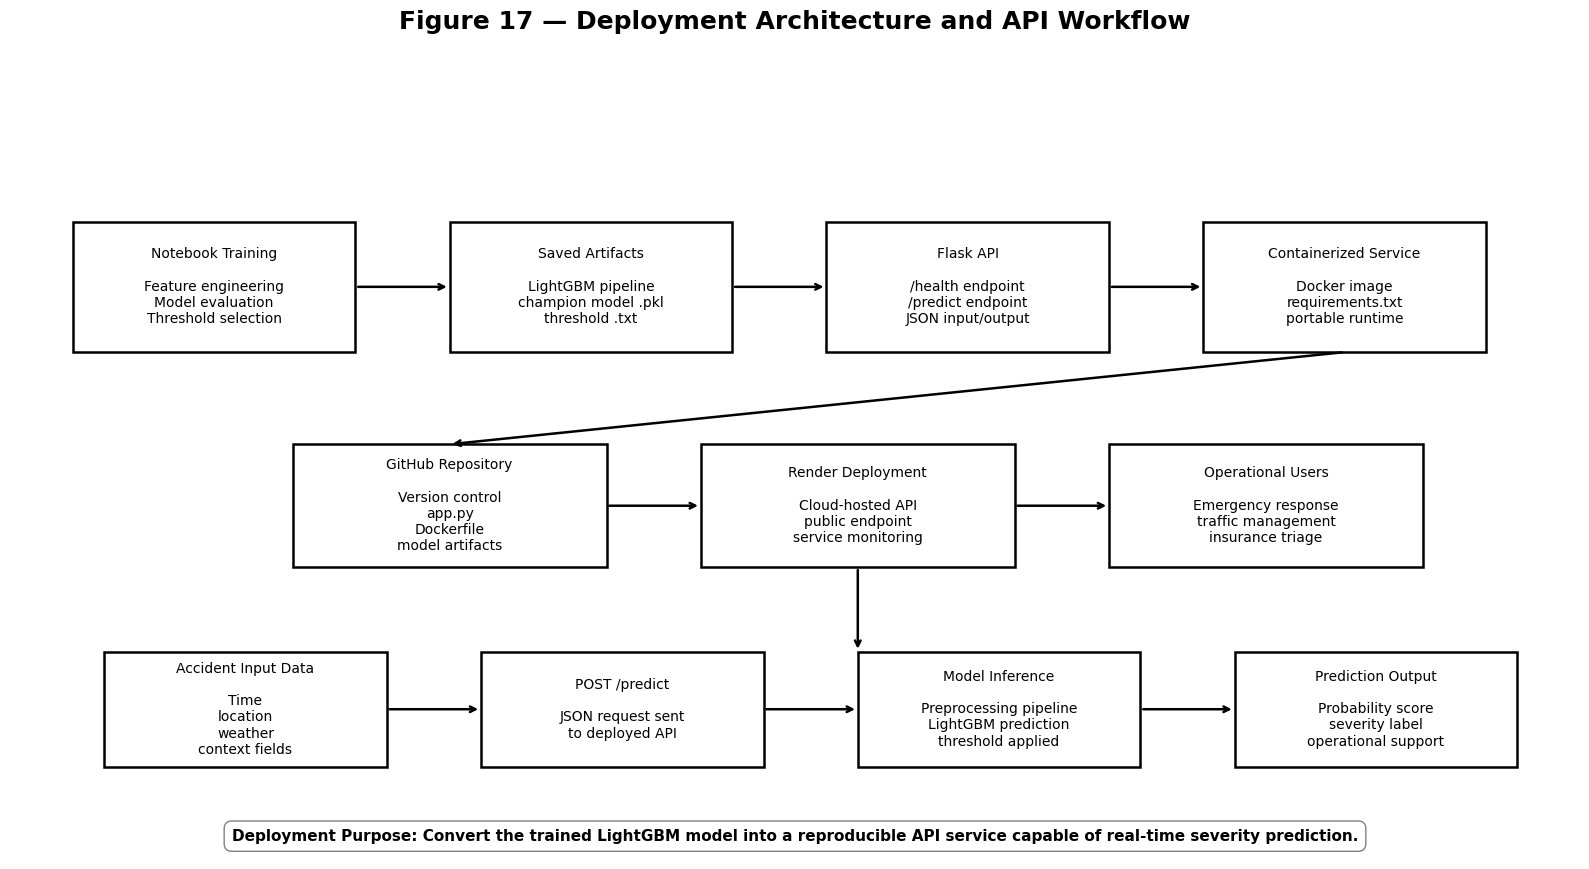

Figure 17 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_17_deployment_architecture_api_workflow.png


In [90]:
# Figure 17 — Deployment Architecture and API Workflow Diagrams
# Flask API, Docker, GitHub, Render, and Model Artifact Flow

import matplotlib.pyplot as plt
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 9))
ax.axis("off")

fig.suptitle(
    "Figure 17 — Deployment Architecture and API Workflow",
    fontsize=18,
    fontweight="bold",
    y=0.96
)

# Helper functions

def draw_box(x, y, text, width=0.18, height=0.12, fontsize=10):
    box = plt.Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=1.8
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )

def draw_arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.8)
    )

# Top row: model development to deployment

draw_box(
    0.04, 0.66,
    "Notebook Training\n\nFeature engineering\nModel evaluation\nThreshold selection",
    width=0.18,
    height=0.17
)

draw_box(
    0.28, 0.66,
    "Saved Artifacts\n\nLightGBM pipeline\nchampion model .pkl\nthreshold .txt",
    width=0.18,
    height=0.17
)

draw_box(
    0.52, 0.66,
    "Flask API\n\n/health endpoint\n/predict endpoint\nJSON input/output",
    width=0.18,
    height=0.17
)

draw_box(
    0.76, 0.66,
    "Containerized Service\n\nDocker image\nrequirements.txt\nportable runtime",
    width=0.18,
    height=0.17
)

draw_arrow(0.22, 0.745, 0.28, 0.745)
draw_arrow(0.46, 0.745, 0.52, 0.745)
draw_arrow(0.70, 0.745, 0.76, 0.745)

# Middle row: cloud deployment workflow

draw_box(
    0.18, 0.38,
    "GitHub Repository\n\nVersion control\napp.py\nDockerfile\nmodel artifacts",
    width=0.20,
    height=0.16
)

draw_box(
    0.44, 0.38,
    "Render Deployment\n\nCloud-hosted API\npublic endpoint\nservice monitoring",
    width=0.20,
    height=0.16
)

draw_box(
    0.70, 0.38,
    "Operational Users\n\nEmergency response\ntraffic management\ninsurance triage",
    width=0.20,
    height=0.16
)

draw_arrow(0.85, 0.66, 0.28, 0.54)
draw_arrow(0.38, 0.46, 0.44, 0.46)
draw_arrow(0.64, 0.46, 0.70, 0.46)

# Bottom row: API inference flow

draw_box(
    0.06, 0.12,
    "Accident Input Data\n\nTime\nlocation\nweather\ncontext fields",
    width=0.18,
    height=0.15
)

draw_box(
    0.30, 0.12,
    "POST /predict\n\nJSON request sent\nto deployed API",
    width=0.18,
    height=0.15
)

draw_box(
    0.54, 0.12,
    "Model Inference\n\nPreprocessing pipeline\nLightGBM prediction\nthreshold applied",
    width=0.18,
    height=0.15
)

draw_box(
    0.78, 0.12,
    "Prediction Output\n\nProbability score\nseverity label\noperational support",
    width=0.18,
    height=0.15
)

draw_arrow(0.24, 0.195, 0.30, 0.195)
draw_arrow(0.48, 0.195, 0.54, 0.195)
draw_arrow(0.72, 0.195, 0.78, 0.195)

# Connect deployed API to inference workflow
draw_arrow(0.54, 0.38, 0.54, 0.27)

# Caption

ax.text(
    0.5,
    0.02,
    "Deployment Purpose: Convert the trained LightGBM model into a reproducible API service capable of real-time severity prediction.",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray")
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

figure_path = figure_dir / "figure_17_deployment_architecture_api_workflow.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 17 saved to: {figure_path}")

Figure 18 Report

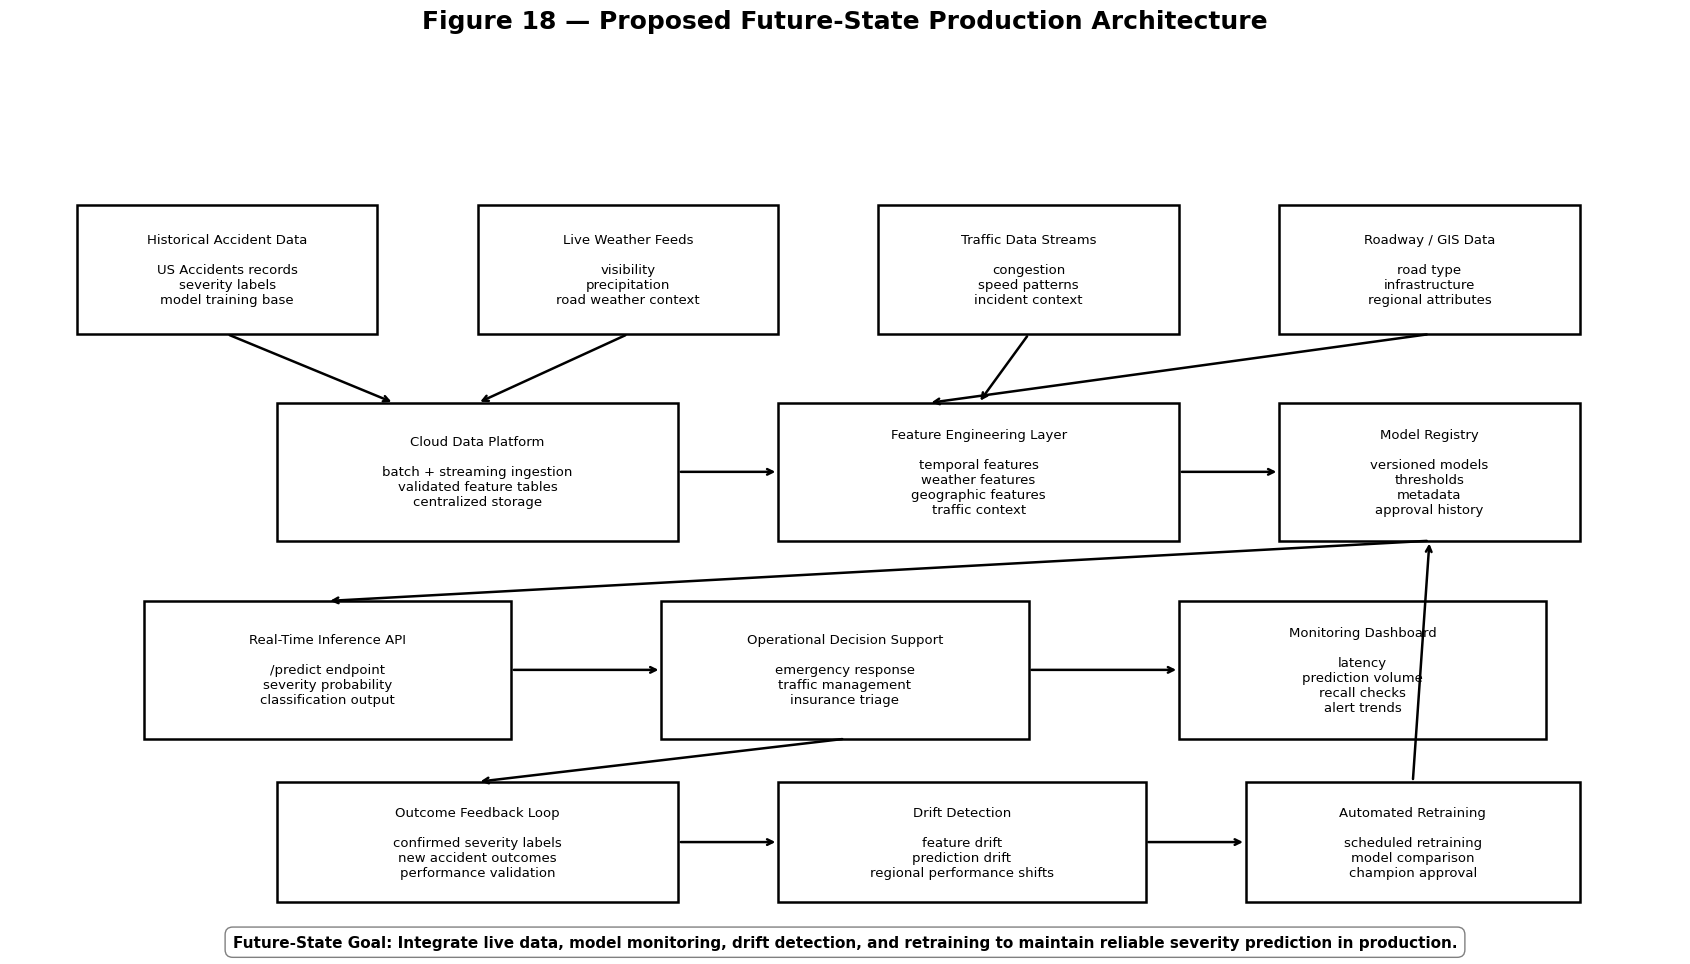

Figure 18 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_18_future_state_production_architecture.png


In [91]:
# Figure 18 — Proposed Future-State Production Architecture
# Real-Time Data, Monitoring, Drift Detection, and Retraining

import matplotlib.pyplot as plt
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(17, 10))
ax.axis("off")

fig.suptitle(
    "Figure 18 — Proposed Future-State Production Architecture",
    fontsize=18,
    fontweight="bold",
    y=0.96
)

# Helper functions

def draw_box(x, y, text, width=0.18, height=0.12, fontsize=9.5):
    box = plt.Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=1.8
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )

def draw_arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.8)
    )

# Data source layer

draw_box(
    0.04, 0.72,
    "Historical Accident Data\n\nUS Accidents records\nseverity labels\nmodel training base",
    width=0.18,
    height=0.15
)

draw_box(
    0.28, 0.72,
    "Live Weather Feeds\n\nvisibility\nprecipitation\nroad weather context",
    width=0.18,
    height=0.15
)

draw_box(
    0.52, 0.72,
    "Traffic Data Streams\n\ncongestion\nspeed patterns\nincident context",
    width=0.18,
    height=0.15
)

draw_box(
    0.76, 0.72,
    "Roadway / GIS Data\n\nroad type\ninfrastructure\nregional attributes",
    width=0.18,
    height=0.15
)

# Data platform layer

draw_box(
    0.16, 0.48,
    "Cloud Data Platform\n\nbatch + streaming ingestion\nvalidated feature tables\ncentralized storage",
    width=0.24,
    height=0.16
)

draw_box(
    0.46, 0.48,
    "Feature Engineering Layer\n\ntemporal features\nweather features\ngeographic features\ntraffic context",
    width=0.24,
    height=0.16
)

draw_box(
    0.76, 0.48,
    "Model Registry\n\nversioned models\nthresholds\nmetadata\napproval history",
    width=0.18,
    height=0.16
)

draw_arrow(0.13, 0.72, 0.23, 0.64)
draw_arrow(0.37, 0.72, 0.28, 0.64)
draw_arrow(0.61, 0.72, 0.58, 0.64)
draw_arrow(0.85, 0.72, 0.55, 0.64)

draw_arrow(0.40, 0.56, 0.46, 0.56)
draw_arrow(0.70, 0.56, 0.76, 0.56)

# Serving and monitoring layer

draw_box(
    0.08, 0.25,
    "Real-Time Inference API\n\n/predict endpoint\nseverity probability\nclassification output",
    width=0.22,
    height=0.16
)

draw_box(
    0.39, 0.25,
    "Operational Decision Support\n\nemergency response\ntraffic management\ninsurance triage",
    width=0.22,
    height=0.16
)

draw_box(
    0.70, 0.25,
    "Monitoring Dashboard\n\nlatency\nprediction volume\nrecall checks\nalert trends",
    width=0.22,
    height=0.16
)

draw_arrow(0.85, 0.48, 0.19, 0.41)
draw_arrow(0.30, 0.33, 0.39, 0.33)
draw_arrow(0.61, 0.33, 0.70, 0.33)

# Feedback and retraining layer

draw_box(
    0.16, 0.06,
    "Outcome Feedback Loop\n\nconfirmed severity labels\nnew accident outcomes\nperformance validation",
    width=0.24,
    height=0.14
)

draw_box(
    0.46, 0.06,
    "Drift Detection\n\nfeature drift\nprediction drift\nregional performance shifts",
    width=0.22,
    height=0.14
)

draw_box(
    0.74, 0.06,
    "Automated Retraining\n\nscheduled retraining\nmodel comparison\nchampion approval",
    width=0.20,
    height=0.14
)

draw_arrow(0.50, 0.25, 0.28, 0.20)
draw_arrow(0.40, 0.13, 0.46, 0.13)
draw_arrow(0.68, 0.13, 0.74, 0.13)

# Feedback from retraining to registry
draw_arrow(0.84, 0.20, 0.85, 0.48)

# Caption

ax.text(
    0.5,
    0.005,
    "Future-State Goal: Integrate live data, model monitoring, drift detection, and retraining to maintain reliable severity prediction in production.",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray")
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

figure_path = figure_dir / "figure_18_future_state_production_architecture.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 18 saved to: {figure_path}")

Figure 19 Report

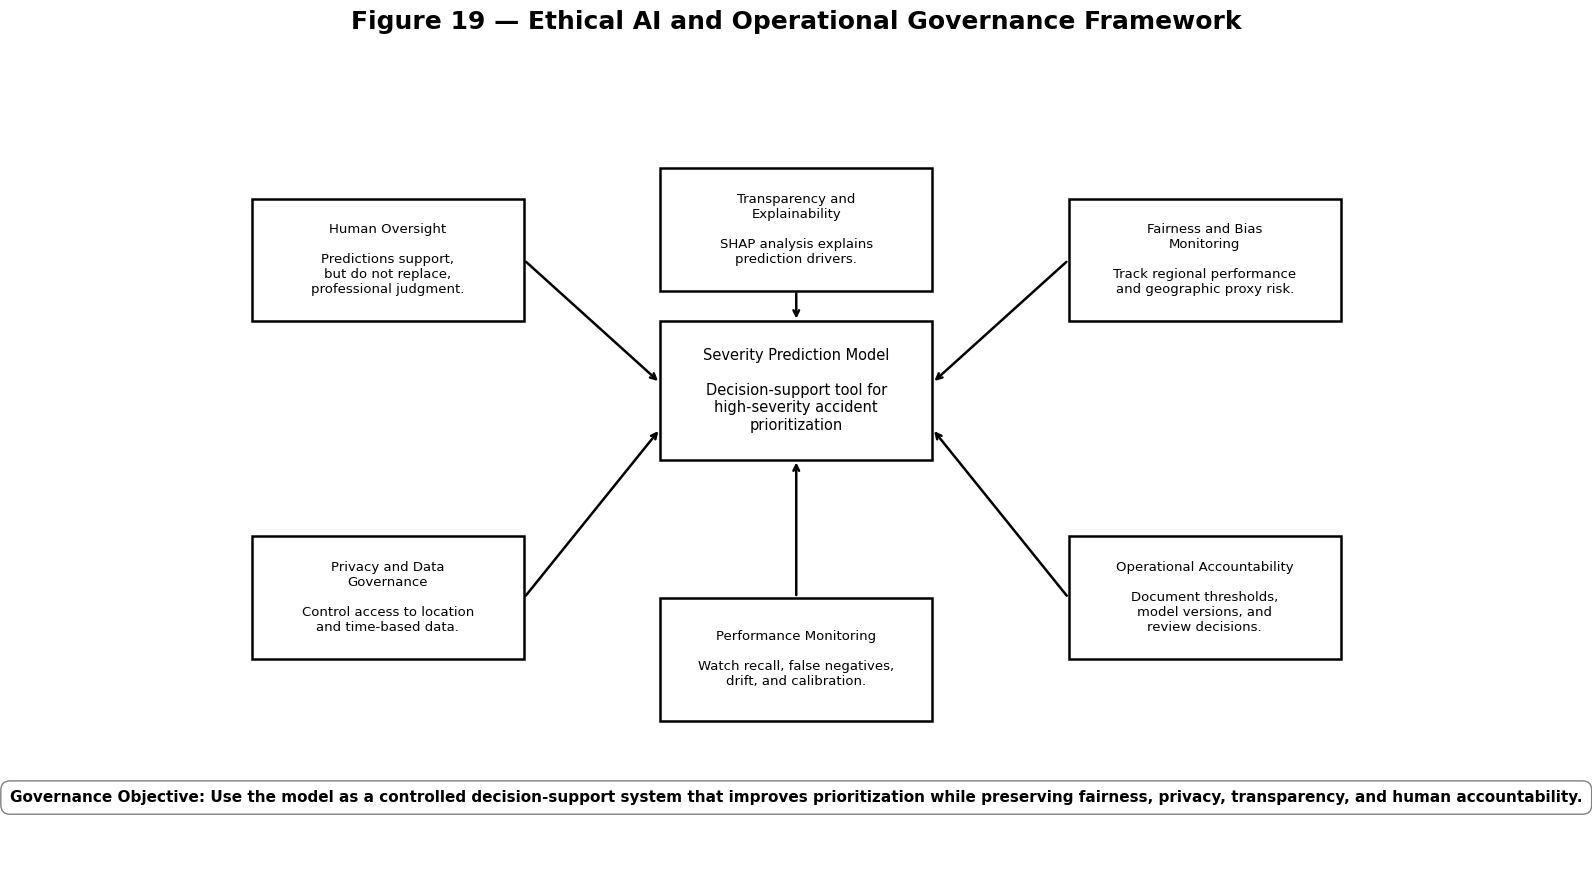

Figure 19 saved to: /content/drive/MyDrive/Colab Notebooks/DATA6545/Final Project/figures/figure_19_ethical_ai_operational_governance_framework.png


In [92]:
# Figure 19 — Ethical AI and Operational Governance Framework
# Safety-Critical ML Decision Support

import matplotlib.pyplot as plt
from pathlib import Path

figure_dir = PROJECT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 9))
ax.axis("off")

fig.suptitle(
    "Figure 19 — Ethical AI and Operational Governance Framework",
    fontsize=18,
    fontweight="bold",
    y=0.96
)

# Helper functions

def draw_box(x, y, text, width=0.20, height=0.13, fontsize=10):
    box = plt.Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=1.8
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )

def draw_arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.8)
    )

# Center model box

draw_box(
    0.39, 0.52,
    "Severity Prediction Model\n\nDecision-support tool for\nhigh-severity accident\nprioritization",
    width=0.22,
    height=0.18,
    fontsize=10.5
)

# Governance pillars

pillars = [
    (
        0.06, 0.70,
        "Human Oversight\n\nPredictions support,\nbut do not replace,\nprofessional judgment."
    ),
    (
        0.39, 0.74,
        "Transparency and\nExplainability\n\nSHAP analysis explains\nprediction drivers."
    ),
    (
        0.72, 0.70,
        "Fairness and Bias\nMonitoring\n\nTrack regional performance\nand geographic proxy risk."
    ),
    (
        0.06, 0.26,
        "Privacy and Data\nGovernance\n\nControl access to location\nand time-based data."
    ),
    (
        0.39, 0.18,
        "Performance Monitoring\n\nWatch recall, false negatives,\ndrift, and calibration."
    ),
    (
        0.72, 0.26,
        "Operational Accountability\n\nDocument thresholds,\nmodel versions, and\nreview decisions."
    ),
]

for x, y, text in pillars:
    draw_box(x, y, text, width=0.22, height=0.16, fontsize=9.5)

# Arrows to/from center
draw_arrow(0.28, 0.78, 0.39, 0.62)
draw_arrow(0.50, 0.74, 0.50, 0.70)
draw_arrow(0.72, 0.78, 0.61, 0.62)

draw_arrow(0.28, 0.34, 0.39, 0.56)
draw_arrow(0.50, 0.34, 0.50, 0.52)
draw_arrow(0.72, 0.34, 0.61, 0.56)

# Risk-control band

ax.text(
    0.5,
    0.08,
    (
        "Governance Objective: Use the model as a controlled decision-support system "
        "that improves prioritization while preserving fairness, privacy, transparency, "
        "and human accountability."
    ),
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="gray")
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

figure_path = figure_dir / "figure_19_ethical_ai_operational_governance_framework.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 19 saved to: {figure_path}")